# GNN Powerflow V2.6 — Analysis

Loads trained runs, evaluates GNN vs. baseline solvers, produces comparison plots and statistics.

**Input**: sweep JSONs from `GNN_Powerflow_V2.6_Training.ipynb`

In [42]:
# %%
import copy
import logging
import os
import pickle
import random
import time
from typing import Dict, List, Optional, Tuple
import json
from datetime import datetime
from dataclasses import dataclass, field, asdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pypsa
import pypowsybl as pp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Batch, Data, Dataset
from torch_geometric.nn import GATv2Conv, GCNConv, GraphConv
from tqdm import tqdm

import urllib

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fix for numba >= 0.60: version_version attribute was removed; inject it before pandapower imports it
try:
    import numba._version as _nv
    if not hasattr(_nv, 'version_version'):
        import numba as _n; _nv.version_version = _n.__version__
except ImportError:
    pass

# Suppress verbose output from PyPSA and dependencies during data generation
for _log in ("pypsa", "pypsa.pf", "pypsa.components", "numexpr", "linopy"):
    logging.getLogger(_log).setLevel(logging.WARNING)
logging.getLogger("numexpr").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

import re
from scipy import ndimage

In [20]:
# ── Configurable paths ───────────────────────────────────────────────────────
# Set DATA_ROOT to wherever your data folders live.
# Use "." to keep everything relative to the repo (default).
# Example: DATA_ROOT = r"C:\Users\you\OneDrive\Data_PF_GNN"
import os as _os
DATA_ROOT             = r"C:\Users\STSI\OneDrive - USN\Data_PF_GNN"                                             # ← change this
GRID_MODEL_FILES      = _os.path.join(DATA_ROOT, "grid_model_files")    # static grid CSV/RAW files
TRAINING_NETWORKS_DIR = _os.path.join(DATA_ROOT, "training_networks_saved")  # dataset JSONs
TRAINING_RESULTS_DIR  = _os.path.join(DATA_ROOT, "training_results_saved")   # sweep result JSONs/CSVs


In [21]:
#test and execution toggles
run_smoke_test=False # to run a smoke test on network generation
run_regression_test=False # to run a regression test on the GNN training loop (with very limited epochs and data)
run_powsybl_extract = False # extract data from powsybl for the first time, or re-extract after edits to the extraction code
run_cigre_extract = False # extract data from CIGRE for the first time, or re-extract after edits to the extraction code    
run_powsybl_extract = False
run_cigre_extract = False

In [22]:
import itertools

# ── Style pools ──────────────────────────────────────────────────────────────
_LINE_STYLES  = ["-", "--", "-.", ":"]
_MARKERS      = ["", "o", "s", "^", "D", "v", "P", "X"]
_COLOR_CYCLE  = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## Data Generation Functions
_Paste from V2.5.3 cells 20, 22, 23, 25, 26_

In [23]:
#==================save and load genrated datasets========================


def load_dataset_list(index_path: str) -> list:
    """
    Reload a list of PyPSA networks saved by save_dataset_list.
    """
    import json

    with open(index_path, "r") as f:
        meta = json.load(f)

    save_dir = os.path.dirname(index_path) or "."
    networks: list[pypsa.Network] = []
    for nc_name in meta["files"]:
        nc_path = os.path.join(save_dir, nc_name)
        networks.append(pypsa.Network(nc_path))

    print(f"Loaded {len(networks)} networks from {index_path}")
    return networks



## Power System Helpers

## GNN Architecture

In [24]:
# =============================================================================
# SECTION 5: GNN MODEL
# Must be defined here so pickle can reconstruct saved PowerFlowGNN models.
# =============================================================================

class PowerFlowGNN(nn.Module):
    """
    Graph Attention Network (GATv2) for power flow prediction.
    Predicts per-bus: [vmag, vang, P, Q]
    Predicts per-edge bilinear PTDF: hedges @ W @ hnodes.T
    """

    def __init__(
        self,
        node_features: int = 7,
        edge_features: int = 4,
        hidden_dim: int = 64,
        num_layers: int = 3,
        heads: int = 4,
        dropout: float = 0.0,
        conv_type: str = "gatv2",
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.heads = heads
        self.dropout = dropout
        self.conv_type = conv_type

        self.node_embedding = nn.Linear(node_features, hidden_dim)

        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(self._make_conv(hidden_dim, hidden_dim, edge_features))

        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv(
                    hidden_dim, hidden_dim // heads,
                    heads=heads,
                    edge_dim=edge_features,
                    concat=True,
                    dropout=dropout,
                )
            )

        self.vmag_pred = nn.Linear(hidden_dim, 1)
        self.vang_pred = nn.Linear(hidden_dim, 1)
        self.p_pred    = nn.Linear(hidden_dim, 1)
        self.q_pred    = nn.Linear(hidden_dim, 1)

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_features, hidden_dim),
            nn.LeakyReLU(),
        )

        self.ptdf_W = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)

        self._initialize_weights()

    def _make_conv(self, in_dim: int, out_dim: int, edge_features: int):
        if self.conv_type == "gatv2":
            return GATv2Conv(
                in_dim, out_dim // self.heads,
                heads=self.heads,
                edge_dim=edge_features,
                concat=True,
                dropout=self.dropout,
            )
        elif self.conv_type == "gcn":
            return GCNConv(in_dim, out_dim, add_self_loops=False)
        elif self.conv_type == "graphconv":
            return GraphConv(in_dim, out_dim)
        else:
            raise ValueError(f"Unknown conv_type: {self.conv_type}")

    def forward(self, data, return_embeddings=False):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        h = self.node_embedding(x)
        for conv in self.convs:
            if isinstance(conv, GATv2Conv):
                h = conv(h, edge_index, edge_attr)
            else:
                h = conv(h, edge_index)
            h = F.leaky_relu(h)

        h_nodes = h

        vmag_pred = self.vmag_pred(h_nodes)
        vang_pred = self.vang_pred(h_nodes)
        p_pred    = self.p_pred(h_nodes)
        q_pred    = self.q_pred(h_nodes)
        node_pred = torch.cat([vmag_pred, vang_pred, p_pred, q_pred], dim=-1)

        row, col = data.edge_index
        h_src = h_nodes[row]
        h_dst = h_nodes[col]
        edge_input = torch.cat([h_src, h_dst, edge_attr], dim=-1)
        h_edges = self.edge_mlp(edge_input)

        if return_embeddings:
            return node_pred, h_nodes, h_edges

        H_W      = h_edges @ self.ptdf_W
        ptdf_pred = H_W @ h_nodes.T
        return node_pred, ptdf_pred

    def _initialize_weights(self, gain=1.0):
        nn.init.xavier_uniform_(self.node_embedding.weight, gain=gain)
        nn.init.zeros_(self.node_embedding.bias)

        for conv in self.convs:
            if hasattr(conv, "lin_l") and conv.lin_l is not None:
                nn.init.xavier_uniform_(conv.lin_l.weight, gain=gain)
            if hasattr(conv, "lin_r") and conv.lin_r is not None:
                nn.init.xavier_uniform_(conv.lin_r.weight, gain=gain)
            if hasattr(conv, "lin_edge") and conv.lin_edge is not None:
                nn.init.xavier_uniform_(conv.lin_edge.weight, gain=gain)

        for layer, bias_init in [
            (self.vmag_pred, 1.0),
            (self.vang_pred, 0.0),
            (self.p_pred,    0.0),
            (self.q_pred,    0.0),
        ]:
            nn.init.xavier_uniform_(layer.weight, gain=gain)
            nn.init.constant_(layer.bias, bias_init)

In [39]:
# =============================================================================
# SECTION 4: DATASET
# Must be defined here so evaluate_dc_baseline and other evaluation functions
# that construct PowerFlowDataset can run in this notebook.
# =============================================================================

class PowerFlowDataset(Dataset):
    """
    One data object per (network, snapshot) pair.
    See Training notebook for full documentation.
    """

    def __init__(
        self,
        networks: list,
        use_edge_features: bool = True,
        use_pnet_balance: bool = True,
        transform=None,
        pre_transform=None,
        ptdf_branch_mode: str = "lines",
    ):
        super().__init__(root=None, transform=transform, pre_transform=pre_transform)
        self.networks          = networks
        self.use_edge_features = use_edge_features
        self.use_pnet_balance  = use_pnet_balance
        self.ptdf_branch_mode  = ptdf_branch_mode

        self._index = []
        for net_idx, net in enumerate(networks):
            for t_idx in range(len(net.snapshots)):
                self._index.append((net_idx, t_idx))

    def len(self):
        return len(self._index)

    def get(self, idx):
        net_idx, t_idx = self._index[idx]
        network = self.networks[net_idx]
        return self._create_graph_data(network, t_idx, net_idx)

    def _create_graph_data(self, network, t_idx, net_idx):
        buses     = list(network.buses.index)
        n_buses   = len(buses)
        bus_to_i  = {b: i for i, b in enumerate(buses)}
        snapshot  = network.snapshots[t_idx]

        is_slack = torch.zeros(n_buses, dtype=torch.float)
        is_pv    = torch.zeros(n_buses, dtype=torch.float)
        is_pq    = torch.zeros(n_buses, dtype=torch.float)
        slack_mask = torch.zeros(n_buses, dtype=torch.bool)
        pv_mask    = torch.zeros(n_buses, dtype=torch.bool)
        pq_mask    = torch.zeros(n_buses, dtype=torch.bool)

        for _, gen in network.generators.iterrows():
            bus_name = gen["bus"]
            if bus_name not in bus_to_i:
                continue
            i = bus_to_i[bus_name]
            ctrl = gen["control"]
            if ctrl == "Slack":
                is_slack[i] = 1.0; slack_mask[i] = True
            elif ctrl == "PV":
                is_pv[i] = 1.0; pv_mask[i] = True

        for i in range(n_buses):
            if not slack_mask[i] and not pv_mask[i]:
                is_pq[i] = 1.0; pq_mask[i] = True

        p_bus = torch.tensor(network.buses_t.p.loc[snapshot, buses].values, dtype=torch.float)
        q_bus = torch.tensor(network.buses_t.q.loc[snapshot, buses].values, dtype=torch.float)
        v_mag = torch.tensor(network.buses_t.v_mag_pu.loc[snapshot, buses].values, dtype=torch.float)
        v_ang = torch.tensor(network.buses_t.v_ang.loc[snapshot, buses].values, dtype=torch.float)

        x_p    = p_bus.clone(); x_p[slack_mask]  = 0.0
        x_q    = q_bus.clone(); x_q[slack_mask]  = 0.0; x_q[pv_mask]    = 0.0
        x_vmag = v_mag.clone(); x_vmag[pq_mask]  = 0.0
        x_vang = v_ang.clone(); x_vang[pq_mask]  = 0.0; x_vang[pv_mask] = 0.0

        x = torch.stack([is_slack, is_pv, is_pq, x_p, x_q, x_vmag, x_vang], dim=1)
        p_net_balance    = float(p_bus.sum().item())
        p_net_bal_tensor = torch.tensor([p_net_balance], dtype=torch.float)
        if self.use_pnet_balance:
            x = torch.cat([x, p_net_bal_tensor.expand(n_buses, 1)], dim=1)

        y = torch.stack([v_mag, v_ang, p_bus, q_bus], dim=1)

        edge_index_list = []; edge_attr_list = []
        forward_edge_mask = []; fwd_line_idx_list = []; ptdf_edge_row_idx_list = []

        branches = []
        for _, line in network.lines.iterrows():
            if line["bus0"] in bus_to_i and line["bus1"] in bus_to_i:
                branches.append((line.name, line["bus0"], line["bus1"],
                                 line["r"], line["x"], line.get("b", 0.0), 1.0, "line"))
        for _, tr in network.transformers.iterrows():
            if tr["bus0"] in bus_to_i and tr["bus1"] in bus_to_i:
                tap = tr.get("tap_ratio", 1.0)
                tap = tap if not pd.isna(tap) else 1.0
                branches.append((tr.name, tr["bus0"], tr["bus1"],
                                 tr["r"], tr["x"], tr.get("b", 0.0), float(tap), "trafo"))

        for branch_idx, (name, b0, b1, r, x_val, b_val, tap, btype) in enumerate(branches):
            i0, i1 = bus_to_i[b0], bus_to_i[b1]
            z = complex(r, x_val)
            y_ser = (1.0 / z) if abs(z) > 1e-12 else 0.0
            attr = [r, x_val, b_val / 2.0, tap, y_ser.real, y_ser.imag] if self.use_edge_features else [1.0]

            is_supervised = (btype == "line") if self.ptdf_branch_mode == "lines" else True

            edge_index_list.append([i0, i1]); edge_attr_list.append(attr)
            forward_edge_mask.append(is_supervised)
            if is_supervised:
                fwd_line_idx_list.append(branch_idx); ptdf_edge_row_idx_list.append(branch_idx)
            else:
                ptdf_edge_row_idx_list.append(-1)

            edge_index_list.append([i1, i0]); edge_attr_list.append(attr)
            forward_edge_mask.append(False); ptdf_edge_row_idx_list.append(-1)

        if edge_index_list:
            edge_index        = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
            edge_attr         = torch.tensor(edge_attr_list,  dtype=torch.float)
            fwd_mask          = torch.tensor(forward_edge_mask,     dtype=torch.bool)
            line_idx          = torch.tensor(fwd_line_idx_list,     dtype=torch.long)
            ptdf_edge_row_idx = torch.tensor(ptdf_edge_row_idx_list, dtype=torch.long)
        else:
            edge_index        = torch.zeros((2, 0), dtype=torch.long)
            edge_attr         = torch.zeros((0, 6 if self.use_edge_features else 1), dtype=torch.float)
            fwd_mask          = torch.zeros(0, dtype=torch.bool)
            line_idx          = torch.zeros(0, dtype=torch.long)
            ptdf_edge_row_idx = torch.zeros(0, dtype=torch.long)

        try:
            ptdf_matrix = compute_ptdf_matrix(network)
            y_ptdf = torch.tensor(ptdf_matrix, dtype=torch.float)
        except Exception:
            y_ptdf = torch.zeros((len(network.lines), n_buses), dtype=torch.float)

        y_line_p = (torch.tensor(network.lines_t.p0.loc[snapshot].values, dtype=torch.float)
                    if not network.lines_t.p0.empty
                    else torch.zeros(len(network.lines), dtype=torch.float))

        data = Data(x=x, y=y, edge_index=edge_index, edge_attr=edge_attr)
        data.slack_mask        = slack_mask
        data.pv_mask           = pv_mask
        data.pq_mask           = pq_mask
        data.y_ptdf            = y_ptdf
        data.y_line_p          = y_line_p
        data.forward_edge_mask = fwd_mask
        data.ptdf_line_index   = line_idx
        data.ptdf_edge_row_idx = ptdf_edge_row_idx
        data.network_idx       = torch.tensor([net_idx], dtype=torch.long)
        data.p_net_balance     = p_net_bal_tensor
        return data

In [25]:
# =============================================================================
# SECTION 7: LINE FLOW CALCULATION
# =============================================================================

def calculate_line_flows(network, vmag, vang, t_idx=None):
    """
    Calculate AC line flows from predicted voltages.

    Args:
        network: PyPSA network object
        vmag:    Voltage magnitudes [num_buses], numpy array, p.u.
        vang:    Voltage angles [num_buses], numpy array, radians
        t_idx:   Snapshot index (used for nominal values only)
    Returns:
        dict with keys p0, p1, q0, q1 - each a numpy array of length num_lines (p.u.)
    """
    num_lines = len(network.lines)
    p0 = np.zeros(num_lines)
    p1 = np.zeros(num_lines)
    q0 = np.zeros(num_lines)
    q1 = np.zeros(num_lines)

    all_buses = list(network.buses.index)
    # BUGFIX: use bus_to_idx dict instead of string parsing (topology-safe)
    bus_to_idx = {bus_name: idx for idx, bus_name in enumerate(all_buses)}

    for i, line in enumerate(network.lines.index):
        from_bus = network.lines.loc[line, "bus0"]
        to_bus = network.lines.loc[line, "bus1"]

        # BUGFIX: use dict lookup instead of int(bus.split('-')[1]) - 1
        from_idx = bus_to_idx[from_bus]
        to_idx = bus_to_idx[to_bus]

        r = network.lines.loc[line, "r"]
        x = network.lines.loc[line, "x"]
        b = network.lines.loc[line, "b"] if "b" in network.lines.columns else 0.0

        # Line impedance and admittance
        z = complex(r, x)
        y_series = 1.0 / z if abs(z) > 1e-12 else 0.0
        y_shunt = complex(0, b / 2.0)

        # Complex voltages at from/to buses
        V_from = vmag[from_idx] * np.exp(1j * vang[from_idx])
        V_to = vmag[to_idx] * np.exp(1j * vang[to_idx])

        # Line current from sending end
        I_from = (V_from - V_to) * y_series + V_from * y_shunt
        I_to = (V_to - V_from) * y_series + V_to * y_shunt

        S_from = V_from * np.conj(I_from)
        S_to = V_to * np.conj(I_to)

        s_nom = network.lines.loc[line, "s_nom"]
        # Convert from p.u. to MW/MVAr using system base
        #base_mva = getattr(network, "sn_mva", 100.0)

        p0[i] = S_from.real #* base_mva # removed the base_mva scaling to keep flows in p.u. for better numerical stability and consistency with the rest of the model's inputs/outputs
        q0[i] = S_from.imag #* base_mva
        p1[i] = -S_to.real #* base_mva  # convention: positive = into bus
        q1[i] = -S_to.imag #* base_mva

    return {"p0": p0, "p1": p1, "q0": q0, "q1": q1}


def build_line_results_from_flows(network, flows, snapshot_label):
    """
    Helper to build a line_results-style DataFrame for one snapshot
    from a dict produced by calculate_line_flows.
    """
    idx = pd.Index([snapshot_label], name="snapshot")
    cols = pd.MultiIndex.from_product(
        [network.lines.index, ["P0 pu", "P1 pu", "Q0 pu", "Q1 pu"]]
    )
    df = pd.DataFrame(index=idx, columns=cols, dtype=float)
    for i, line in enumerate(network.lines.index):
        df.loc[snapshot_label, (line, "P0 pu")] = flows["p0"][i]
        df.loc[snapshot_label, (line, "P1 pu")] = flows["p1"][i]
        df.loc[snapshot_label, (line, "Q0 pu")] = flows["q0"][i]
        df.loc[snapshot_label, (line, "Q1 pu")] = flows["q1"][i]
    return df



In [26]:
# =============================================================================
# SECTION 9: INFERENCE & PREDICTION
# =============================================================================

def _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, ptdf_offset=0, device=None):
    """Augment data.edge_attr with learned PTDF rows for learned_edge models.

    Shared helper used by evaluate_model, compare_pf_conventional_vs_gnn,
    predict_network_results_with_masks, and evaluate_gnn_on_test_set.

    Args:
        data:          single PyG Data object (already moved to device)
        ptdf_params:   list[nn.Parameter] or None
        max_buses:     int, PTDF parameter width
        net_idx:       int, network index within the dataset
        ptdf_offset:   int, added to net_idx to get global ptdf_params index
        device:        torch device (inferred from data.edge_attr if None)

    Returns:
        data with edge_attr augmented in-place. No-op if ptdf_params is None.
    """
    if ptdf_params is None or max_buses <= 0:
        return data
    if device is None:
        device = data.edge_attr.device
    row_idx = data.ptdf_edge_row_idx  # [E] line index or -1
    ptdf_rows = torch.zeros(data.edge_attr.size(0), max_buses, device=device)
    valid = (row_idx >= 0) & (row_idx < ptdf_params[net_idx + ptdf_offset].size(0))
    if valid.any():
        ptdf_rows[valid] = ptdf_params[net_idx + ptdf_offset][row_idx[valid]].to(device)
    data.edge_attr = torch.cat([data.edge_attr, ptdf_rows], dim=-1)
    return data


def model_results(network, print_results=False, plot_results=False, compute_ptdf=False):
    """
    Run PyPSA power flow and store results in DataFrames.
    Print if print_results=True, plot if plot_results=True.

    DISTSLACK: pass distribute_slack=True to use PyPSA's distributed slack solver.
    """
    # DISTSLACK: use distribute_slack=True to properly handle distributed slack
    network.pf(use_seed=True, distribute_slack=False)  # DISTSLACK: change to True when using distributed slack

    snapshots = network.snapshots
    buses = network.buses.index
    lines = network.lines.index

    bus_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([buses, ["P pu", "Q pu", "V pu", "Angle deg"]]),
        dtype=float,
    )
    line_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([lines, ["P0 pu", "P1 pu", "Q0 pu", "Q1 pu"]]),
        dtype=float,
    )

    for t in snapshots:
        for bus in buses:
            bus_results.loc[t, (bus, "P pu")]    = network.buses_t.p.loc[t, bus]
            bus_results.loc[t, (bus, "Q pu")]  = network.buses_t.q.loc[t, bus]
            bus_results.loc[t, (bus, "V pu")]    = network.buses_t.v_mag_pu.loc[t, bus]
            bus_results.loc[t, (bus, "Angle deg")] = np.degrees(network.buses_t.v_ang.loc[t, bus])
        for line in lines:
            line_results.loc[t, (line, "P0 pu")]   = network.lines_t.p0.loc[t, line]
            line_results.loc[t, (line, "P1 pu")]   = network.lines_t.p1.loc[t, line]
            line_results.loc[t, (line, "Q0 pu")] = network.lines_t.q0.loc[t, line]
            line_results.loc[t, (line, "Q1 pu")] = network.lines_t.q1.loc[t, line]

    if print_results:
        print(bus_results)
        print(line_results)
    if plot_results:
        plot_network_results(network, bus_results)

    ptdf_df = None
    if compute_ptdf:
        ptdf_df = compute_ptdf_matrix(network)

    return bus_results, line_results, ptdf_df


def batched_gnn_forward(model, data_list):
    """Run GNN on a batch of graphs in a single forward pass."""
    exclude_keys = ['y_ptdf', 'ptdf_line_index', 'y_line_p']
    batch = Batch.from_data_list(data_list, exclude_keys=exclude_keys)
    out = model(batch)
    if isinstance(out, tuple):
        out = out[0]
    results = []
    for g in range(len(data_list)):
        mask = (batch.batch == g)
        results.append(out[mask])
    return results


def predict_network_results_with_masks(
    model, network, use_edge_features=True, debug=False,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None, max_buses=0, ptdf_offset=0,
):
    """
    Run GNN prediction on a network and return bus/line results with prediction masks.

    DISTSLACK: prediction masks now also flag distributed slack buses correctly.
    Distributed slack buses predict P and Q (same as single slack).
    STSI 26.04.07: Augments edge_attr when ptdf_params is provided (learned_edge).

    Args:
        model:   Trained PowerFlowGNN model
        network: PyPSA network object (must have solved power flow for feature extraction)
    Returns:
        bus_results, line_results, prediction_masks
    """
    dataset = PowerFlowDataset([network], use_edge_features=use_edge_features)
    snapshots = network.snapshots
    buses = list(network.buses.index)
    bus_to_idx = {b: i for i, b in enumerate(buses)}

    bus_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([buses, ["P pu", "Q pu", "V pu", "Angle deg"]]),
        dtype=float,
    )
    line_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product(
            [network.lines.index, ["P0 pu", "P1 pu", "Q0 pu", "Q1 pu"]]
        ),
        dtype=float,
    )
    # Prediction masks: which properties were predicted (not taken from input)
    prediction_masks = {
        "P":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "Q":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "V":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "Angle": pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
    }

    model.eval()
    with torch.no_grad():
        for t_idx, t in enumerate(snapshots):
            data = dataset[t_idx]

            # STSI 26.04.07: augment edge_attr for learned_edge models
            _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx=0, ptdf_offset=ptdf_offset)

            # Fallback: zero-pad if model expects wider edge_attr (old runs without stored ptdf_params)
            if hasattr(model, 'convs') and model.convs and hasattr(model.convs[0], 'lin_edge') and model.convs[0].lin_edge is not None:
                _expected = model.convs[0].lin_edge.in_channels
                if data.edge_attr.size(1) < _expected:
                    data.edge_attr = torch.cat([data.edge_attr, torch.zeros(data.edge_attr.size(0), _expected - data.edge_attr.size(1))], dim=1)

            node_pred, _ = model(data)  # [num_buses, 4]: vmag, vang, p, q

            pred_vmag = node_pred[:, 0]
            pred_vang = node_pred[:, 1]
            pred_p    = node_pred[:, 2]
            pred_q    = node_pred[:, 3]

            for i, bus in enumerate(buses):
                bus_type = "PQ"  # default
                connected_gens = network.generators[network.generators.bus == bus]
                if len(connected_gens) > 0:
                    ctrl = connected_gens.iloc[0]["control"]
                    if ctrl in ("Slack", "PV"):
                        bus_type = ctrl

                if bus_type == "PQ":
                    # For PQ buses: predict vmag, vang
                    pred_vmag_i = pred_vmag[i]
                    pred_vang_i = pred_vang[i]
                    pred_p_i    = network.buses_t.p.loc[t, bus]   # Known
                    pred_q_i    = network.buses_t.q.loc[t, bus]   # Known
                    prediction_masks["P"].loc[t, bus]     = False
                    prediction_masks["Q"].loc[t, bus]     = False
                    prediction_masks["V"].loc[t, bus]     = True
                    prediction_masks["Angle"].loc[t, bus] = True

                elif bus_type == "PV":
                    # For PV buses: known vmag, predict vang, q
                    pred_vmag_i = network.buses_t.v_mag_pu.loc[t, bus]  # Known
                    pred_vang_i = pred_vang[i]
                    pred_p_i    = network.buses_t.p.loc[t, bus]         # Known
                    pred_q_i    = pred_q[i]
                    prediction_masks["P"].loc[t, bus]     = False
                    prediction_masks["Q"].loc[t, bus]     = True
                    prediction_masks["V"].loc[t, bus]     = False
                    prediction_masks["Angle"].loc[t, bus] = True

                else:
                    # Slack (single or distributed): known vmag, vang; predict p, q
                    # DISTSLACK: for distributed slack, vmag is known but angle
                    # reference is only soft-fixed; we still use the known angle
                    # from the PF solution as input and predict P, Q
                    pred_vmag_i = network.buses_t.v_mag_pu.loc[t, bus]  # Known
                    pred_vang_i = network.buses_t.v_ang.loc[t, bus]     # Known (reference)
                    pred_p_i    = pred_p[i]
                    pred_q_i    = pred_q[i]
                    prediction_masks["P"].loc[t, bus]     = True
                    prediction_masks["Q"].loc[t, bus]     = True
                    prediction_masks["V"].loc[t, bus]     = False
                    prediction_masks["Angle"].loc[t, bus] = False

                bus_results.loc[t, (bus, "P pu")]      = pred_p_i.item() if torch.is_tensor(pred_p_i) else pred_p_i
                bus_results.loc[t, (bus, "Q pu")]      = pred_q_i.item() if torch.is_tensor(pred_q_i) else pred_q_i
                bus_results.loc[t, (bus, "V pu")]      = pred_vmag_i.item() if torch.is_tensor(pred_vmag_i) else pred_vmag_i
                bus_results.loc[t, (bus, "Angle deg")] = np.degrees(
                    pred_vang_i.item() if torch.is_tensor(pred_vang_i) else pred_vang_i
                )

            if debug:
                print(f"Predicted angles should be small radians: {pred_vang[:3].numpy()}")
                print(f"Predicted angles in degrees: {np.degrees(pred_vang[:3].numpy())}")
                print(f"Angle range: {pred_vang.min():.6f} to {pred_vang.max():.6f} radians")

            # Calculate line flows from predicted voltages
            vmag_np = np.array([
                bus_results.loc[t, (bus, "V pu")] for bus in buses
            ], dtype=float)
            vang_np = np.radians(np.array([
                bus_results.loc[t, (bus, "Angle deg")] for bus in buses
            ], dtype=float))
            pred_line_flows = calculate_line_flows(network, vmag_np, vang_np, t_idx)

            for i, line in enumerate(network.lines.index):
                line_results.loc[t, (line, "P0 pu")]   = pred_line_flows["p0"][i]
                line_results.loc[t, (line, "P1 pu")]   = pred_line_flows["p1"][i]
                line_results.loc[t, (line, "Q0 pu")] = pred_line_flows["q0"][i]
                line_results.loc[t, (line, "Q1 pu")] = pred_line_flows["q1"][i]

    return bus_results, line_results, prediction_masks

def evaluate_pypsa_timing(networks, verbose=True):
    """Measure PyPSA AC PF wall time by re-running pf() on a network copy.
    
    Runs pf() on all snapshots at once per network (same as normal usage),
    divides by snapshot count for per-snapshot average.
    Error = 0 by definition (PyPSA is the ground truth).
    """
    all_times_ms = []
    for network in networks:
        net_copy = network.copy()
        t0 = time.perf_counter()
        net_copy.pf(use_seed=True)
        t1 = time.perf_counter()
        ms_per_snap = (t1 - t0) * 1000.0 / max(1, len(network.snapshots))
        all_times_ms.append(ms_per_snap)

    avg_ms = float(np.mean(all_times_ms))
    metrics = {
        'vmag_mae': 0.0, 'vang_mae': 0.0,
        'p_mae': 0.0, 'q_mae': 0.0,
        'line_flow_mae': 0.0, 'line_flow_q0_mae': 0.0,
        'inference_time_per_snapshot_ms': avg_ms,
        'n_snapshots': sum(len(n.snapshots) for n in networks),
    }
    if verbose:
        print(f"PyPSA AC timing: {avg_ms:.3f} ms/snap avg over {len(networks)} network(s)")
    return metrics

def evaluate_pypsa_timing_single(networks, verbose=True):
    """Measure PyPSA AC PF time per individual snapshot (no batching)."""
    times_ms = []
    for net in networks:
        for snap in net.snapshots:
            net_copy = net.copy()
            net_copy.set_snapshots([snap])
            t0 = time.perf_counter()
            net_copy.pf(use_seed=True)
            t1 = time.perf_counter()
            times_ms.append((t1 - t0) * 1000)
    
    avg_ms = float(np.mean(times_ms))
    metrics = {
        'vmag_mae': 0.0, 'vang_mae': 0.0,
        'p_mae': 0.0, 'q_mae': 0.0,
        'line_flow_mae': 0.0, 'line_flow_q0_mae': 0.0,
        'inference_time_per_snapshot_ms': avg_ms,
    }
    if verbose:
        print(f"PyPSA AC (single): {avg_ms:.3f} ms/snap over {len(times_ms)} snapshots")
    return metrics

# STSI 26.04.07: added backfill_line_flow_metrics to compute line flow errors separately from bus errors, and to support learned_edge models with augmented edge_attr for PTDF rows.

def backfill_gnn_timing(
    runs: list,
    test_networks: list,
    use_edge_features: bool = True,
    use_pnet_balance: bool = True,
    n_warmup: int = 5,
    batch_size: int = 64,
    device=None,
):
    """
    Backfill per-snapshot timing into sweep runs with live model objects.
    
    Three timing levels:
      solve_time_ms:       single forward pass per snapshot
      batch_solve_time_ms: batched forward pass / N snapshots
      postproc_time_ms:    mask overrides + cpu transfer + line flow calc
      total_time_ms:       solve + postproc (single-snapshot end-to-end)
    """
    if device is None:
        device = torch.device('cpu')
    
    dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
    )
    n_snaps = len(dataset)
    print(f"Dataset: {n_snaps} snapshots, {n_warmup} warmup, batch_size={batch_size}")
    
    for ri, run in enumerate(runs):
        model = run['model']
        model.to(device)
        model.eval()
        
        ptdf_params = run.get('_ptdf_params', None)
        max_buses   = run.get('_max_buses', 0)
        
        # ── Phase 1: Per-snapshot timing ──
        solve_times = []
        postproc_times = []
        
        with torch.no_grad():
            for i in range(n_snaps + n_warmup):
                idx = i % n_snaps
                data = dataset[idx].to(device)
                net_idx, _ = dataset._index[idx]
                _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, device=device)
                
                # Level 1: pure forward pass
                t0 = time.perf_counter()
                out = model(data)
                if isinstance(out, tuple):
                    out = out[0]
                t_solve = time.perf_counter() - t0
                
                # Level 2: post-processing
                t1 = time.perf_counter()
                x = data.x
                bus_type = x[:, 0]
                pv_mask    = (bus_type == 1)
                slack_mask = (bus_type == 2)
                
                vmag_pred = out[:, 0].clone()
                vang_pred = out[:, 1].clone()
                vmag_pred[pv_mask]    = x[pv_mask, 5]
                vmag_pred[slack_mask] = x[slack_mask, 5]
                vang_pred[slack_mask] = x[slack_mask, 6]
                
                vmag_np = vmag_pred.cpu().numpy()
                vang_np = vang_pred.cpu().numpy()
                calculate_line_flows(test_networks[net_idx], vmag_np, vang_np)
                t_post = time.perf_counter() - t1
                
                if i >= n_warmup:
                    solve_times.append(t_solve)
                    postproc_times.append(t_post)
        
        # ── Phase 2: Batched timing ──
        all_data = []
        with torch.no_grad():
            for i in range(n_snaps):
                data = dataset[i].to(device)
                net_idx, _ = dataset._index[i]
                _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, device=device)
                all_data.append(data)
            
            # Warmup
            for _ in range(3):
                _ = batched_gnn_forward(model, all_data[:batch_size])
            
            # Timed batched forward in chunks
            batch_times = []
            batch_counts = []
            for start in range(0, n_snaps, batch_size):
                chunk = all_data[start:start + batch_size]
                t0 = time.perf_counter()
                _ = batched_gnn_forward(model, chunk)
                batch_times.append(time.perf_counter() - t0)
                batch_counts.append(len(chunk))
        
        batch_ms_per_snap = sum(batch_times) * 1000 / sum(batch_counts)
        
        # ── Store results ──
        solve_ms    = np.mean(solve_times) * 1000
        postproc_ms = np.mean(postproc_times) * 1000
        total_ms    = solve_ms + postproc_ms
        
        run['test_metrics']['solve_time_ms']       = solve_ms
        run['test_metrics']['postproc_time_ms']     = postproc_ms
        run['test_metrics']['total_time_ms']        = total_ms
        run['test_metrics']['batch_solve_time_ms']  = batch_ms_per_snap
        
        tag = run.get('tag', run.get('physics_label', '?'))
        print(f"  Run {ri:2d}: {tag:30s} | single={solve_ms:.2f}ms  batch={batch_ms_per_snap:.3f}ms  post={postproc_ms:.2f}ms  total={total_ms:.2f}ms")
    
    print(f"\nBackfilled timing for {len(runs)} runs.")

def backfill_line_flow_metrics(
    runs: list,
    test_networks: list,
    use_edge_features: bool = True,
    use_pnet_balance: bool = True,
    device=None,
):
    """
    Backfill line_flow_mae and line_flow_q0_mae into runs that are missing them.
    Requires live model objects in run['model'] and solved test_networks.
    """
    if device is None:
        device = torch.device('cpu')

    dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
    )
    n_snaps = len(dataset)

    for ri, run in enumerate(runs):
        tm = run.get("test_metrics", {})
        if "line_flow_mae" in tm and not np.isnan(tm["line_flow_mae"]):
            print(f"  Run {ri}: already has line_flow_mae={tm['line_flow_mae']:.6f}, skipping")
            continue

        model = run['model']
        model.to(device)
        model.eval()

        ptdf_params = run.get('_ptdf_params', None)
        max_buses   = run.get('_max_buses', 0)

        lflow_p_errors = []
        lflow_q_errors = []

        with torch.no_grad():
            for i in range(n_snaps):
                data = dataset[i].to(device)
                net_idx, t_idx = dataset._index[i]
                network = test_networks[net_idx]
                snapshot = network.snapshots[t_idx]

                _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, device=device)

                out = model(data)
                if isinstance(out, tuple):
                    out = out[0]

                x = data.x
                bus_type   = x[:, 0]
                pv_mask    = (bus_type == 1)
                slack_mask = (bus_type == 2)

                vmag_pred = out[:, 0].clone()
                vang_pred = out[:, 1].clone()
                vmag_pred[pv_mask]    = x[pv_mask, 5]
                vmag_pred[slack_mask] = x[slack_mask, 5]
                vang_pred[slack_mask] = x[slack_mask, 6]

                vmag_np = vmag_pred.cpu().numpy()
                vang_np = vang_pred.cpu().numpy()

                try:
                    flows = calculate_line_flows(network, vmag_np, vang_np)

                    if not network.lines_t.p0.empty and snapshot in network.lines_t.p0.index:
                        true_p0 = network.lines_t.p0.loc[snapshot].values
                        pred_p0 = np.array(flows["p0"])
                        lflow_p_errors.append(np.mean(np.abs(pred_p0 - true_p0)))

                    if not network.lines_t.q0.empty and snapshot in network.lines_t.q0.index:
                        true_q0 = network.lines_t.q0.loc[snapshot].values
                        pred_q0 = np.array(flows["q0"])
                        lflow_q_errors.append(np.mean(np.abs(pred_q0 - true_q0)))
                except Exception as e:
                    if not lflow_p_errors:
                        print(f"    [Run {ri}] line flow calc failed: {e}")

        tm["line_flow_mae"]    = float(np.mean(lflow_p_errors)) if lflow_p_errors else float("nan")
        tm["line_flow_q0_mae"] = float(np.mean(lflow_q_errors)) if lflow_q_errors else float("nan")
        run["test_metrics"] = tm

        tag = run.get("tag", run.get("physics_label", "?"))
        print(f"  Run {ri}: {tag:30s} | p0_mae={tm['line_flow_mae']:.6f}  q0_mae={tm['line_flow_q0_mae']:.6f}  ({len(lflow_p_errors)}/{n_snaps} snaps)")

    print(f"\nBackfilled line flow metrics for {len(runs)} runs.")

def backfill_all(
    runs: list,
    test_networks: list,
    use_edge_features: bool = True,
    use_pnet_balance: bool = True,
    n_warmup: int = 5,
    batch_size: int = 64,
    device=None,
    force: bool = False,
):
    """
    Single-pass backfill of timing + line flow metrics into sweep runs.

    Stores in test_metrics:
      solve_time_ms, postproc_time_ms, total_time_ms, batch_solve_time_ms,
      line_flow_mae, line_flow_q0_mae
    
    Skips runs that already have all keys unless force=True.
    """
    ALL_KEYS = {"solve_time_ms", "postproc_time_ms", "total_time_ms",
                "batch_solve_time_ms", "line_flow_mae", "line_flow_q0_mae"}

    if device is None:
        device = torch.device('cpu')

    dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
    )
    n_snaps = len(dataset)
    print(f"Dataset: {n_snaps} snapshots, {n_warmup} warmup, batch_size={batch_size}")

    for ri, run in enumerate(runs):
        tm = run.setdefault("test_metrics", {})

        # Skip if all keys already present (and not NaN for line flows)
        if not force and ALL_KEYS.issubset(tm.keys()):
            lf = tm.get("line_flow_mae", float("nan"))
            if not np.isnan(lf):
                print(f"  Run {ri}: already complete, skipping (use force=True to redo)")
                continue

        model = run['model']
        model.to(device)
        model.eval()

        ptdf_params = run.get('_ptdf_params', None)
        max_buses   = run.get('_max_buses', 0)

        solve_times, postproc_times = [], []
        lflow_p_errors, lflow_q_errors = [], []
        # STSI 26.04.07: if ptdf_params is None, we can't augment edge_attr with learned PTDF rows, which may cause errors or degraded performance for models that expect those features. We check for this and skip timing if it looks like a mismatch.
        # Guard: skip learned_edge runs whose PTDF params were lost on save/load
        if ptdf_params is None:
            first_conv = model.convs[0]
            if hasattr(first_conv, 'lin_edge') and first_conv.lin_edge is not None:
                le = first_conv.lin_edge
                expected_edge_dim = getattr(le, 'in_channels', None) or getattr(le, 'in_features', None)
                sample_edge_dim = dataset[0].edge_attr.shape[1]
                if expected_edge_dim is not None and expected_edge_dim > sample_edge_dim:
                    tag = run.get("tag", run.get("physics_label", "?"))
                    print(f"  Run {ri}: SKIPPED — learned_edge PTDF params not available "
                          f"(model expects {expected_edge_dim} edge feats, data has {sample_edge_dim}) | {tag}")
                    continue
        # ── Phase 1: Per-snapshot timing + line flows ──
        with torch.no_grad():
            for i in range(n_snaps + n_warmup):
                idx = i % n_snaps
                data = dataset[idx].to(device)
                net_idx, t_idx = dataset._index[idx]
                network  = test_networks[net_idx]
                snapshot = network.snapshots[t_idx]
                _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, device=device)

                # — Solve (timed) —
                t0 = time.perf_counter()
                out = model(data)
                if isinstance(out, tuple):
                    out = out[0]
                t_solve = time.perf_counter() - t0

                # — Post-processing (timed) —
                t1 = time.perf_counter()
                x = data.x
                bus_type   = x[:, 0]
                pv_mask    = (bus_type == 1)
                slack_mask = (bus_type == 2)

                vmag_pred = out[:, 0].clone()
                vang_pred = out[:, 1].clone()
                vmag_pred[pv_mask]    = x[pv_mask, 5]
                vmag_pred[slack_mask] = x[slack_mask, 5]
                vang_pred[slack_mask] = x[slack_mask, 6]

                vmag_np = vmag_pred.cpu().numpy()
                vang_np = vang_pred.cpu().numpy()

                flows = calculate_line_flows(network, vmag_np, vang_np)
                t_post = time.perf_counter() - t1

                # Only record after warmup
                if i >= n_warmup:
                    solve_times.append(t_solve)
                    postproc_times.append(t_post)

                    # Line flow errors (always, not just after warmup — but we gate on i>=n_warmup)
                    try:
                        if not network.lines_t.p0.empty and snapshot in network.lines_t.p0.index:
                            true_p0 = network.lines_t.p0.loc[snapshot].values
                            pred_p0 = np.array(flows["p0"])
                            lflow_p_errors.append(np.mean(np.abs(pred_p0 - true_p0)))

                        if not network.lines_t.q0.empty and snapshot in network.lines_t.q0.index:
                            true_q0 = network.lines_t.q0.loc[snapshot].values
                            pred_q0 = np.array(flows["q0"])
                            lflow_q_errors.append(np.mean(np.abs(pred_q0 - true_q0)))
                    except Exception as e:
                        if not lflow_p_errors:
                            print(f"    [Run {ri}] line flow error: {e}")

        # ── Phase 2: Batched timing ──
        all_data = []
        with torch.no_grad():
            for i in range(n_snaps):
                data = dataset[i].to(device)
                net_idx, _ = dataset._index[i]
                _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, device=device)
                all_data.append(data)

            # Warmup
            for _ in range(3):
                _ = batched_gnn_forward(model, all_data[:batch_size])

            batch_times, batch_counts = [], []
            for start in range(0, n_snaps, batch_size):
                chunk = all_data[start:start + batch_size]
                t0 = time.perf_counter()
                _ = batched_gnn_forward(model, chunk)
                batch_times.append(time.perf_counter() - t0)
                batch_counts.append(len(chunk))

        batch_ms_per_snap = sum(batch_times) * 1000 / max(1, sum(batch_counts))

        # ── Store everything ──
        solve_ms    = float(np.mean(solve_times)) * 1000
        postproc_ms = float(np.mean(postproc_times)) * 1000

        tm["solve_time_ms"]       = solve_ms
        tm["postproc_time_ms"]    = postproc_ms
        tm["total_time_ms"]       = solve_ms + postproc_ms
        tm["batch_solve_time_ms"] = batch_ms_per_snap
        tm["line_flow_mae"]       = float(np.mean(lflow_p_errors)) if lflow_p_errors else float("nan")
        tm["line_flow_q0_mae"]    = float(np.mean(lflow_q_errors)) if lflow_q_errors else float("nan")

        tag = run.get("tag", run.get("physics_label", "?"))
        print(
            f"  Run {ri}: {tag:30s} | "
            f"single={solve_ms:.2f}ms  batch={batch_ms_per_snap:.3f}ms  "
            f"post={postproc_ms:.2f}ms  total={solve_ms+postproc_ms:.2f}ms | "
            f"p0_mae={tm['line_flow_mae']:.6f}  q0_mae={tm['line_flow_q0_mae']:.6f}"
        )

    print(f"\nBackfilled timing + line flows for {len(runs)} runs.")



## Comparison & Solver Baselines

In [27]:
def evaluate_gnn_on_test_set(
    model,
    test_networks: list,
    use_edge_features: bool = True,
    use_pnet_balance: bool = True,
    device=None,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None,
    max_buses: int = 0,
    ptdf_offset: int = 0,
    # [STSI260502]: batch_size for batched timing measurement
    batch_size: int = 64,
) -> dict:
    """
    Evaluate GNN on test networks snapshot-by-snapshot.

    KEY FIX (2026-03-25): After inference, override known variables with ground
    truth inputs — otherwise scatter plots show model predictions for variables
    the model was never asked to predict (Vmag/Vang at slack/PV), making results
    appear much worse than they are.

    Override rules (mirror of _masked_mse_loss):
        PV    → vmag_eval[pv]    = x[pv,    5]  (known Vmag)
        Slack → vmag_eval[slack] = x[slack,  5]  (known Vmag = v_set)
        Slack → vang_eval[slack] = x[slack,  6]  (known Vang = 0)

    STSI 26.04.07: When ptdf_params is not None (learned_edge mode), augments
    data.edge_attr with learned PTDF rows before model forward pass so the
    model receives the same edge feature width it was trained with.

    [STSI260502]: Added multi-level timing:
      solve_time_ms:       pure forward pass per snapshot
      postproc_time_ms:    mask overrides + cpu transfer + line flow calc
      total_time_ms:       solve + postproc (single-snapshot end-to-end)
      batch_solve_time_ms: batched forward pass amortized per snapshot
    Dataset construction and data.to(device) excluded from all timers.

    Returns dict with MAE/RMSE for Vmag, Vang, P, Q + line flow MAE + timing.
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
    )

    vmag_errors, vang_errors, p_errors, q_errors = [], [], [], []
    vmag_true_all, vang_true_all, p_true_all, q_true_all = [], [], [], []

    lflow_errors = []
    lflow_q0_errors = []
    all_true_flows, all_pred_flows = [], []
    all_true_q0_flows, all_pred_q0_flows = [], []
    n_snapshots = 0

    # [STSI260502]: per-snapshot timing lists (solve and postproc measured separately)
    solve_times = []
    postproc_times = []
    # [STSI260502]: collect prepared data for batched timing later
    all_data_for_batch = []

    with torch.no_grad():
        for i in range(len(dataset)):
            data = dataset[i].to(device)

            # STSI 26.04.07: augment edge_attr for learned_edge models
            net_idx, _ = dataset._index[i]
            _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, ptdf_offset, device)

            # [STSI260502]: save a copy for batched timing (before forward modifies anything)
            all_data_for_batch.append(data.clone())

            # [STSI260502]: Level 1 — time pure forward pass only
            t_solve_start = time.perf_counter()
            node_pred, *_ = model(data, return_embeddings=True)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_solve = time.perf_counter() - t_solve_start

            # [STSI260502]: Level 2 — time post-processing (masks + line flows)
            t_post_start = time.perf_counter()

            # ── Extract masks ─────────────────────────────────────────────────
            slack_mask = data.slack_mask.bool()
            pv_mask    = data.pv_mask.bool()
            pq_mask    = data.pq_mask.bool()

            # ── Raw predictions ───────────────────────────────────────────────
            vmag_eval = node_pred[:, 0].clone()
            vang_eval = node_pred[:, 1].clone()
            p_eval    = node_pred[:, 2].clone()
            q_eval    = node_pred[:, 3].clone()

            # ── Override known variables with ground-truth inputs ─────────────
            # PV: Vmag is known (set by voltage regulator)
            if pv_mask.any():
                vmag_eval[pv_mask] = data.x[pv_mask, 5]

            # Slack: both Vmag and Vang=0 are known
            if slack_mask.any():
                vmag_eval[slack_mask] = data.x[slack_mask, 5]
                vang_eval[slack_mask] = data.x[slack_mask, 6]  # should be ~0

            # PQ: P and Q are known inputs
            if pq_mask.any():
                p_eval[pq_mask] = data.x[pq_mask, 3]
                q_eval[pq_mask] = data.x[pq_mask, 4]

            # PV: P is known input
            if pv_mask.any():
                p_eval[pv_mask] = data.x[pv_mask, 3]

            # ── Ground truth ──────────────────────────────────────────────────
            vmag_true = data.y[:, 0]
            vang_true = data.y[:, 1]
            p_true    = data.y[:, 2]
            q_true    = data.y[:, 3]

            vmag_errors.append((vmag_eval - vmag_true).abs().mean().item())
            vang_errors.append((vang_eval - vang_true).abs().mean().item())
            p_errors.append((p_eval - p_true).abs().mean().item())
            q_errors.append((q_eval - q_true).abs().mean().item())
            vmag_true_all.append(vmag_true.detach())
            vang_true_all.append(vang_true.detach())
            p_true_all.append(p_true.detach())
            q_true_all.append(q_true.detach())
            n_snapshots += 1

            # ── Step 4 (partial): line flow MAE ──────────────────────────────
            if test_networks is not None and hasattr(dataset, '_index') and i < len(dataset._index):
                try:
                    net_idx, t_idx = dataset._index[i]
                    network  = test_networks[net_idx]
                    snapshot = network.snapshots[t_idx]
                    if not network.lines_t.p0.empty:
                        true_flows = network.lines_t.p0.loc[snapshot].values
                        vmag_np = vmag_eval.cpu().numpy()
                        vang_np = vang_eval.cpu().numpy()
                        flows = calculate_line_flows(network, vmag_np, vang_np)
                        pred_flows = np.array(flows["p0"])  # already in p.u.
                        err = np.abs(pred_flows - true_flows).mean()
                        lflow_errors.append(err)
                        all_true_flows.append(true_flows)
                        all_pred_flows.append(pred_flows)
                    if not network.lines_t.q0.empty:
                        true_q0 = network.lines_t.q0.loc[snapshot].values
                        pred_q0 = np.array(flows["q0"])  # already in p.u.
                        lflow_q0_errors.append(np.abs(pred_q0 - true_q0).mean())
                        all_true_q0_flows.append(true_q0)
                        all_pred_q0_flows.append(pred_q0)
                except Exception as _lfe:
                    if not lflow_errors:  # only warn once
                        print(f"[line_flow_mae] skipped: {_lfe}")

            # [STSI260502]: end post-processing timer (includes masks + line flows)
            t_post = time.perf_counter() - t_post_start
            solve_times.append(t_solve)
            postproc_times.append(t_post)

    # [STSI260502]: Phase 2 — batched timing measurement
    # Warmup batched forward
    n_batch_warmup = 3
    with torch.no_grad():
        if all_data_for_batch:
            for _ in range(n_batch_warmup):
                _ = batched_gnn_forward(model, all_data_for_batch[:batch_size])
            
            batch_times = []
            batch_counts = []
            for start in range(0, len(all_data_for_batch), batch_size):
                chunk = all_data_for_batch[start:start + batch_size]
                t0 = time.perf_counter()
                _ = batched_gnn_forward(model, chunk)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                batch_times.append(time.perf_counter() - t0)
                batch_counts.append(len(chunk))
            batch_ms_per_snap = sum(batch_times) * 1000 / max(1, sum(batch_counts))
        else:
            batch_ms_per_snap = float('nan')

    metrics = {
        "vmag_mae":      float(np.mean(vmag_errors)),
        "vang_mae":      float(np.mean(vang_errors)),
        "p_mae":         float(np.mean(p_errors)),
        "q_mae":         float(np.mean(q_errors)),
        "vmag_rmse":     float(np.sqrt(np.mean([e**2 for e in vmag_errors]))),
        "vang_rmse":     float(np.sqrt(np.mean([e**2 for e in vang_errors]))),
        "vmag_true_std": float(torch.cat(vmag_true_all).std().item()),
        "vang_true_std": float(torch.cat(vang_true_all).std().item()),
        "p_true_std":    float(torch.cat(p_true_all).std().item()),
        "q_true_std":    float(torch.cat(q_true_all).std().item()),
    }
    if lflow_errors:
        metrics["line_flow_mae"] = float(np.mean(lflow_errors))
    if lflow_q0_errors:
        metrics["line_flow_q0_mae"] = float(np.mean(lflow_q0_errors))

    if all_true_flows:
        raw = {
            "p0_true": np.concatenate(all_true_flows),
            "p0_pred": np.concatenate(all_pred_flows),
        }
        if all_true_q0_flows:
            raw["q0_true"] = np.concatenate(all_true_q0_flows)
            raw["q0_pred"] = np.concatenate(all_pred_q0_flows)
        metrics["line_flow_raw"] = raw
        
    print("----------------\n Evaluation Metrics (known variables overridden) ---------------")
    for k, v in metrics.items():
        if isinstance(v, (int, float)):
            print(f"  {k:20s}: {v:.6f}")

    # [STSI260502]: monolithic timing kept for backward compat
    inference_time_s = sum(solve_times) + sum(postproc_times)
    metrics["inference_time_s"] = inference_time_s
    metrics["inference_time_per_snapshot_ms"] = (
        1000.0 * inference_time_s / max(1, n_snapshots)
    )
    
    # [STSI260502]: new multi-level timing metrics
    solve_ms    = float(np.mean(solve_times)) * 1000
    postproc_ms = float(np.mean(postproc_times)) * 1000
    metrics["solve_time_ms"]       = solve_ms
    metrics["postproc_time_ms"]    = postproc_ms
    metrics["total_time_ms"]       = solve_ms + postproc_ms
    metrics["batch_solve_time_ms"] = batch_ms_per_snap

    print(f"\n  --- Timing breakdown (per snapshot) ---")
    print(f"  {'solve_time_ms':20s}: {solve_ms:.3f}")
    print(f"  {'postproc_time_ms':20s}: {postproc_ms:.3f}")
    print(f"  {'total_time_ms':20s}: {solve_ms + postproc_ms:.3f}")
    print(f"  {'batch_solve_time_ms':20s}: {batch_ms_per_snap:.3f}")

    return metrics


def evaluate_dc_baseline(
    test_networks,
    use_edge_features: bool = True,
    use_pnet_balance: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Run PyPSA linear (DC) power flow on all test-set snapshots and compute
    the same MAE metrics as evaluate_gnn_on_test_set.

    DC capabilities:
        vmag:          flat 1.0 p.u. (DC assumption) — error at PQ buses
        vang:          solved by lpf()               — error at PQ+PV buses
        p injections:  lossless balance              — error at Slack bus
        q injections:  zero (DC cannot compute Q)    — error at PV+Slack buses
        line_flow_mae: p0 from lpf() vs AC p0        — valid comparison
        line_flow_q0:  not computed by DC            — reported as nan

    Returns a dict compatible with evaluate_gnn_on_test_set output.
    """
    dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
    )
    index_map = {(ni, ti): k for k, (ni, ti) in enumerate(dataset._index)}

    vmag_errors, vang_errors, p_errors, q_errors = [], [], [], []
    lflow_errors = []
    n_snapshots = 0
    t_solve = 0.0

    for net_idx, network in enumerate(test_networks):
        if verbose and net_idx % 20 == 0:
            print(f"  [DC] network {net_idx + 1}/{len(test_networks)}")

        net_copy = network.copy()
        t0 = time.time()
        try:
            net_copy.lpf()
        except Exception as e:
            if verbose:
                print(f"  [DC] lpf() failed on network {net_idx}: {e}")
            continue
        t_solve += time.time() - t0

        buses = network.buses.index

        for t_idx, snap in enumerate(network.snapshots):
            ds_idx = index_map.get((net_idx, t_idx))
            if ds_idx is None:
                continue

            data       = dataset[ds_idx]
            slack_mask = data.slack_mask.bool().numpy()
            pv_mask    = data.pv_mask.bool().numpy()
            pq_mask    = data.pq_mask.bool().numpy()
            x_np       = data.x.numpy()
            y_np       = data.y.numpy()

            vmag_true = y_np[:, 0]
            vang_true = y_np[:, 1]
            p_true    = y_np[:, 2]
            q_true    = y_np[:, 3]

            # DC predictions --------------------------------------------------
            vmag_dc = np.ones(len(buses))                                      # flat 1.0 p.u.
            vang_dc = net_copy.buses_t.v_ang.loc[snap].reindex(buses).values   # from DC solve
            p_dc    = x_np[:, 3].copy()                                        # given P inputs
            q_dc    = np.zeros(len(buses))                                     # DC: Q=0

            # DC slack P: lossless power balance
            if slack_mask.any():
                p_dc[slack_mask] = -p_true[~slack_mask].sum() / slack_mask.sum()

            # Apply same known-variable overrides as evaluate_gnn_on_test_set -
            vmag_dc[pv_mask]    = x_np[pv_mask,    5]   # PV: Vmag given
            vmag_dc[slack_mask] = x_np[slack_mask, 5]   # Slack: Vmag given
            vang_dc[slack_mask] = x_np[slack_mask, 6]   # Slack: Vang=0 given
            p_dc[pq_mask]       = x_np[pq_mask,    3]   # PQ: P given
            q_dc[pq_mask]       = x_np[pq_mask,    4]   # PQ: Q given
            p_dc[pv_mask]       = x_np[pv_mask,    3]   # PV: P given

            vmag_errors.append(np.mean(np.abs(vmag_dc - vmag_true)))
            vang_errors.append(np.mean(np.abs(vang_dc - vang_true)))
            p_errors.append(np.mean(np.abs(p_dc    - p_true)))
            q_errors.append(np.mean(np.abs(q_dc    - q_true)))
            n_snapshots += 1

            # DC line flows (p0 only — q0 is zero in DC) ----------------------
            if not network.lines_t.p0.empty and snap in network.lines_t.p0.index \
                    and snap in net_copy.lines_t.p0.index:
                true_p0 = network.lines_t.p0.loc[snap].values
                dc_p0   = net_copy.lines_t.p0.loc[snap].values
                # PyPSA p0 is in MW; normalise to p.u. using sn_mva
                sn_mva  = getattr(network, "sn_mva", 100.0)
                lflow_errors.append(np.mean(np.abs(dc_p0 / sn_mva - true_p0)))

    metrics = {
        "vmag_mae":    float(np.mean(vmag_errors)) if vmag_errors else float("nan"),
        "vang_mae":    float(np.mean(vang_errors)) if vang_errors else float("nan"),
        "vang_rmse":   float(np.sqrt(np.mean([e**2 for e in vang_errors]))) if vang_errors else float("nan"),
        "p_mae":       float(np.mean(p_errors))    if p_errors    else float("nan"),
        "q_mae":       float(np.mean(q_errors))    if q_errors    else float("nan"),
        "line_flow_mae":     float(np.mean(lflow_errors)) if lflow_errors else float("nan"),
        "line_flow_q0_mae":  float("nan"),   # DC cannot compute reactive line flows
        "inference_time_s":               t_solve,
        "inference_time_per_snapshot_ms": 1000.0 * t_solve / max(1, n_snapshots),
        "n_snapshots":  n_snapshots,
    }

    if verbose:
        print(
            f"\n[DC baseline] {n_snapshots} snapshots — "
            f"pure solve time {t_solve:.2f}s "
            f"({metrics['inference_time_per_snapshot_ms']:.3f} ms/snap)"
        )
        for k in ["vmag_mae", "vang_mae", "p_mae", "q_mae", "line_flow_mae"]:
            print(f"  {k:25s}: {metrics[k]:.5f}")

    return metrics

In [28]:
#=============================================================================
# SECTION 10b: COMPARISON WITH OTHER SOLVERS
#=============================================================================

#import numpy as np
#import time
from pypower.api import runpf, ppoption
from pypower.idx_bus import (BUS_I, BUS_TYPE, PD, QD, GS, BS,
                              BUS_AREA, VM, VA, BASE_KV, ZONE, VMAX, VMIN)
from pypower.idx_gen import (GEN_BUS, PG, QG, QMAX, QMIN, VG,
                              MBASE, GEN_STATUS, PMAX, PMIN)
from pypower.idx_brch import (F_BUS, T_BUS, BR_R, BR_X, BR_B, RATE_A,
                               RATE_B, RATE_C, TAP, SHIFT, BR_STATUS, PF, QF, PT, QT)


def pypsa_to_ppc(network, snapshot, base_mva=1.0):
    """Convert a PyPSA network at a single snapshot to a PyPower ppc dict.
    
    Assumes network values are already in p.u. (v_nom=1.0, line lengths=0).
    All outputs remain in p.u. with the given base_mva.
    
    Returns:
        ppc, bus_names, bus_idx, line_names, trafo_names
    """
    bus_names = network.buses.index.tolist()
    bus_idx = {name: i + 1 for i, name in enumerate(bus_names)}  # 1-indexed
    n = len(bus_names)

    # Bus type sets from generators
    slack_buses = set(network.generators[network.generators['control'] == 'Slack']['bus'])
    pv_buses = set(network.generators[network.generators['control'] == 'PV']['bus'])

    # Aggregate loads per bus for this snapshot
    lp = network.loads_t.p_set.loc[snapshot]
    lq = network.loads_t.q_set.loc[snapshot]
    bus_p, bus_q = {}, {}
    for lname, ldata in network.loads.iterrows():
        b = ldata['bus']
        bus_p[b] = bus_p.get(b, 0.0) + lp.get(lname, 0.0)
        bus_q[b] = bus_q.get(b, 0.0) + lq.get(lname, 0.0)

    # --- Bus matrix (13 cols) ---
    bus_mat = np.zeros((n, 13))
    for i, bname in enumerate(bus_names):
        btype = 3 if bname in slack_buses else (2 if bname in pv_buses else 1)
        bus_mat[i, BUS_I]    = i + 1
        bus_mat[i, BUS_TYPE] = btype
        bus_mat[i, PD]       = bus_p.get(bname, 0.0)
        bus_mat[i, QD]       = bus_q.get(bname, 0.0)
        bus_mat[i, VM]       = 1.0
        bus_mat[i, VA]       = 0.0
        bus_mat[i, BASE_KV]  = network.buses.loc[bname, 'v_nom']
        bus_mat[i, VMAX]     = 1.1
        bus_mat[i, VMIN]     = 0.9

    # Get solved generator outputs for this snapshot
    gen_p_solved, gen_q_solved = {}, {}
    if len(network.generators_t.p) > 0:
        row_gp = network.generators_t.p.loc[snapshot]
        for gname in network.generators.index:
            if gname in row_gp.index:
                gen_p_solved[gname] = float(row_gp[gname])
    if hasattr(network.generators_t, 'q') and len(network.generators_t.q) > 0:
        row_gq = network.generators_t.q.loc[snapshot]
        for gname in network.generators.index:
            if gname in row_gq.index:
                gen_q_solved[gname] = float(row_gq[gname])

    # --- Gen matrix (10 cols) ---
    gen_rows = []
    for gname, gdata in network.generators.iterrows():
        b = gdata['bus']
        vg = float(network.buses_t.v_mag_pu.loc[snapshot, b])
        row = np.zeros(10)
        row[GEN_BUS]    = bus_idx[b]
        row[VG]         = vg
        row[MBASE]      = base_mva
        row[GEN_STATUS] = 1
        row[QMAX] = 9999.0;  row[QMIN] = -9999.0
        row[PMAX] = 9999.0;  row[PMIN] = -9999.0
        if gdata['control'] != 'Slack':
            row[PG] = gen_p_solved.get(gname, 0.0)  # PV: fixed P, pypower solves Q
        if gdata['control'] == 'PQ':
            row[QG] = gen_q_solved.get(gname, 0.0)  # PQ: both fixed
        gen_rows.append(row)

    gen_mat = np.array(gen_rows)

    # --- Branch matrix — lines ---
    branch_rows = []
    line_names = network.lines.index.tolist()
    for lname, line in network.lines.iterrows():
        row = np.zeros(13)
        row[F_BUS]     = bus_idx[line['bus0']]
        row[T_BUS]     = bus_idx[line['bus1']]
        row[BR_R]      = line['r']
        row[BR_X]      = line['x']
        row[BR_B]      = line['b']
        row[RATE_A]    = line['s_nom']
        row[BR_STATUS] = 1
        row[TAP]       = 0.0   # 0 → treated as 1.0 by pypower
        branch_rows.append(row)

    # --- Branch matrix — transformers (use raw r/x, not r_pu/x_pu) ---
    trafo_names = network.transformers.index.tolist()
    for tname, tr in network.transformers.iterrows():
        row = np.zeros(13)
        row[F_BUS]     = bus_idx[tr['bus0']]
        row[T_BUS]     = bus_idx[tr['bus1']]
        row[BR_R]      = tr['r']
        row[BR_X]      = tr['x']
        row[BR_B]      = tr.get('b', 0.0)
        row[RATE_A]    = tr['s_nom']
        row[TAP]       = tr['tap_ratio'] if tr['tap_ratio'] != 0 else 1.0
        row[SHIFT]     = tr['phase_shift']
        row[BR_STATUS] = 1
        branch_rows.append(row)

    branch_mat = np.array(branch_rows)

    ppc = {'version': '2', 'baseMVA': base_mva,
           'bus': bus_mat, 'gen': gen_mat, 'branch': branch_mat}

    return ppc, bus_names, bus_idx, line_names, trafo_names


def evaluate_pypower_baseline(networks, snapshots=None, base_mva=1.0, verbose=True):
    """Run PyPower AC PF on all networks/snapshots, compare to PyPSA ground truth.
    
    All comparisons are in p.u.  Returns dict compatible with scatter plot functions:
      vmag_mae, vang_mae, p_mae, q_mae, line_flow_mae, line_flow_q0_mae,
      inference_time_per_snapshot_ms, n_snapshots, n_converged, n_failed
    """
    ppopt = ppoption(VERBOSE=0, OUT_ALL=0)

    all_vmag_err, all_vang_err = [], []
    all_p_err, all_q_err = [], []
    all_line_p_err, all_line_q_err = [], []
    all_times = []
    n_converged, n_failed = 0, 0

    for network in networks:
        snaps = snapshots if snapshots is not None else network.snapshots
        bus_names = network.buses.index.tolist()
        line_names = network.lines.index.tolist()
        n_buses = len(bus_names)
        n_lines = len(line_names)

        # Check which time-series exist in ground truth
        has_bus_p = hasattr(network.buses_t, 'p') and len(network.buses_t.p) > 0
        has_bus_q = hasattr(network.buses_t, 'q') and len(network.buses_t.q) > 0
        has_line_p = hasattr(network.lines_t, 'p0') and len(network.lines_t.p0) > 0
        has_line_q = hasattr(network.lines_t, 'q0') and len(network.lines_t.q0) > 0

        for snap in snaps:
            # --- Convert & ----
            ppc, _, bus_idx, _, _ = pypsa_to_ppc(network, snap, base_mva)
            # --- Solve (timed) ---
            t0 = time.perf_counter()
            result, success = runpf(ppc, ppopt)
            t1 = time.perf_counter()
            all_times.append((t1 - t0) * 1000.0)

            if not success:
                n_failed += 1
                continue
            n_converged += 1

            # Sort result buses by index
            res_bus = result['bus'][np.argsort(result['bus'][:, BUS_I].astype(int))]

            # --- Voltage comparison (p.u. / radians) ---
            pypsa_vmag = network.buses_t.v_mag_pu.loc[snap].reindex(bus_names).values
            pypsa_vang = network.buses_t.v_ang.loc[snap].reindex(bus_names).values
            pp_vmag = res_bus[:, VM]
            pp_vang = np.deg2rad(res_bus[:, VA])

            all_vmag_err.extend(np.abs(pypsa_vmag - pp_vmag))
            all_vang_err.extend(np.abs(pypsa_vang - pp_vang))

            # --- Bus P/Q injection (p.u.) ---
            if has_bus_p or has_bus_q:
                pp_gen = result['gen']
                pp_bus_pgen = np.zeros(n_buses)
                pp_bus_qgen = np.zeros(n_buses)
                for g in range(pp_gen.shape[0]):
                    bidx = int(pp_gen[g, GEN_BUS]) - 1
                    pp_bus_pgen[bidx] += pp_gen[g, PG]
                    pp_bus_qgen[bidx] += pp_gen[g, QG]
                if has_bus_p:
                    pypsa_p = network.buses_t.p.loc[snap].reindex(bus_names).values
                    pp_p_inj = pp_bus_pgen - res_bus[:, PD]
                    all_p_err.extend(np.abs(pypsa_p - pp_p_inj))
                if has_bus_q:
                    pypsa_q = network.buses_t.q.loc[snap].reindex(bus_names).values
                    pp_q_inj = pp_bus_qgen - res_bus[:, QD]
                    all_q_err.extend(np.abs(pypsa_q - pp_q_inj))

            # --- Line flows (p.u.) — lines only, first n_lines branches ---
            if has_line_p:
                pypsa_lp = network.lines_t.p0.loc[snap].reindex(line_names).values
                all_line_p_err.extend(np.abs(pypsa_lp - result['branch'][:n_lines, PF]))
            if has_line_q:
                pypsa_lq = network.lines_t.q0.loc[snap].reindex(line_names).values
                all_line_q_err.extend(np.abs(pypsa_lq - result['branch'][:n_lines, QF]))

    total = n_converged + n_failed
    metrics = {
        'vmag_mae':       float(np.mean(all_vmag_err))   if all_vmag_err   else float('nan'),
        'vang_mae':       float(np.mean(all_vang_err))   if all_vang_err   else float('nan'),
        'p_mae':          float(np.mean(all_p_err))      if all_p_err      else float('nan'),
        'q_mae':          float(np.mean(all_q_err))      if all_q_err      else float('nan'),
        'line_flow_mae':  float(np.mean(all_line_p_err)) if all_line_p_err else float('nan'),
        'line_flow_q0_mae': float(np.mean(all_line_q_err)) if all_line_q_err else float('nan'),
        'inference_time_per_snapshot_ms': float(np.mean(all_times)) if all_times else float('nan'),
        'n_snapshots': total,
        'n_converged': n_converged,
        'n_failed': n_failed,
    }

    if verbose:
        print(f"PyPower AC baseline: {n_converged}/{total} converged, "
              f"{metrics['inference_time_per_snapshot_ms']:.3f} ms/snap")
        for k in ['vmag_mae','vang_mae','p_mae','q_mae','line_flow_mae','line_flow_q0_mae']:
            print(f"  {k}: {metrics[k]:.8f} p.u.")
    return metrics

def evaluate_fdlf_baseline(networks, snapshots=None, base_mva=1.0, verbose=True):
    """Run PyPower Fast Decoupled (XB) PF on all networks/snapshots.
    Identical to evaluate_pypower_baseline but uses PF_ALG=2 (FDLF-XB).
    """
    ppopt = ppoption(VERBOSE=0, OUT_ALL=0, PF_ALG=2)

    all_vmag_err, all_vang_err = [], []
    all_p_err, all_q_err = [], []
    all_line_p_err, all_line_q_err = [], []
    all_times = []
    n_converged, n_failed = 0, 0

    for network in networks:
        snaps = snapshots if snapshots is not None else network.snapshots
        bus_names = network.buses.index.tolist()
        line_names = network.lines.index.tolist()
        n_buses = len(bus_names)
        n_lines = len(line_names)

        has_bus_p = hasattr(network.buses_t, 'p') and len(network.buses_t.p) > 0
        has_bus_q = hasattr(network.buses_t, 'q') and len(network.buses_t.q) > 0
        has_line_p = hasattr(network.lines_t, 'p0') and len(network.lines_t.p0) > 0
        has_line_q = hasattr(network.lines_t, 'q0') and len(network.lines_t.q0) > 0

        for snap in snaps:
            ppc, _, bus_idx, _, _ = pypsa_to_ppc(network, snap, base_mva)

            t0 = time.perf_counter()
            result, success = runpf(ppc, ppopt)
            t1 = time.perf_counter()
            all_times.append((t1 - t0) * 1000.0)

            if not success:
                n_failed += 1
                continue
            n_converged += 1

            res_bus = result['bus'][np.argsort(result['bus'][:, BUS_I].astype(int))]

            pypsa_vmag = network.buses_t.v_mag_pu.loc[snap].reindex(bus_names).values
            pypsa_vang = network.buses_t.v_ang.loc[snap].reindex(bus_names).values
            pp_vmag = res_bus[:, VM]
            pp_vang = np.deg2rad(res_bus[:, VA])

            all_vmag_err.extend(np.abs(pypsa_vmag - pp_vmag))
            all_vang_err.extend(np.abs(pypsa_vang - pp_vang))

            if has_bus_p or has_bus_q:
                pp_gen = result['gen']
                pp_bus_pgen = np.zeros(n_buses)
                pp_bus_qgen = np.zeros(n_buses)
                for g in range(pp_gen.shape[0]):
                    bidx = int(pp_gen[g, GEN_BUS]) - 1
                    pp_bus_pgen[bidx] += pp_gen[g, PG]
                    pp_bus_qgen[bidx] += pp_gen[g, QG]
                if has_bus_p:
                    pypsa_p = network.buses_t.p.loc[snap].reindex(bus_names).values
                    pp_p_inj = pp_bus_pgen - res_bus[:, PD]
                    all_p_err.extend(np.abs(pypsa_p - pp_p_inj))
                if has_bus_q:
                    pypsa_q = network.buses_t.q.loc[snap].reindex(bus_names).values
                    pp_q_inj = pp_bus_qgen - res_bus[:, QD]
                    all_q_err.extend(np.abs(pypsa_q - pp_q_inj))

            if has_line_p:
                pypsa_lp = network.lines_t.p0.loc[snap].reindex(line_names).values
                all_line_p_err.extend(np.abs(pypsa_lp - result['branch'][:n_lines, PF]))
            if has_line_q:
                pypsa_lq = network.lines_t.q0.loc[snap].reindex(line_names).values
                all_line_q_err.extend(np.abs(pypsa_lq - result['branch'][:n_lines, QF]))

    total = n_converged + n_failed
    metrics = {
        'vmag_mae':       float(np.mean(all_vmag_err))   if all_vmag_err   else float('nan'),
        'vang_mae':       float(np.mean(all_vang_err))   if all_vang_err   else float('nan'),
        'p_mae':          float(np.mean(all_p_err))      if all_p_err      else float('nan'),
        'q_mae':          float(np.mean(all_q_err))      if all_q_err      else float('nan'),
        'line_flow_mae':  float(np.mean(all_line_p_err)) if all_line_p_err else float('nan'),
        'line_flow_q0_mae': float(np.mean(all_line_q_err)) if all_line_q_err else float('nan'),
        'inference_time_per_snapshot_ms': float(np.mean(all_times)) if all_times else float('nan'),
        'n_snapshots': total,
        'n_converged': n_converged,
        'n_failed': n_failed,
    }

    if verbose:
        print(f"FDLF (XB) baseline: {n_converged}/{total} converged, "
              f"{metrics['inference_time_per_snapshot_ms']:.3f} ms/snap")
        for k in ['vmag_mae','vang_mae','p_mae','q_mae','line_flow_mae','line_flow_q0_mae']:
            print(f"  {k}: {metrics[k]:.8f} p.u.")
    return metrics

def evaluate_pandapower_baseline(networks, snapshots=None, base_mva=1.0, verbose=True):
    """Run pandapower AC NR PF on all networks/snapshots.
    Path: pypsa_to_ppc → from_ppc (untimed) → runpp (timed).
    With baseMVA=1.0, pandapower MW/MVAr values equal p.u. numerically.
    """
    import pandapower as pdp
    from pandapower.converter import from_ppc
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)

    all_vmag_err, all_vang_err = [], []
    all_p_err, all_q_err = [], []
    all_line_p_err, all_line_q_err = [], []
    all_times = []
    n_converged, n_failed = 0, 0

    for network in networks:
        snaps = snapshots if snapshots is not None else network.snapshots
        bus_names = network.buses.index.tolist()
        line_names = network.lines.index.tolist()
        n_buses = len(bus_names)
        n_lines = len(line_names)

        has_bus_p = hasattr(network.buses_t, 'p') and len(network.buses_t.p) > 0
        has_bus_q = hasattr(network.buses_t, 'q') and len(network.buses_t.q) > 0
        has_line_p = hasattr(network.lines_t, 'p0') and len(network.lines_t.p0) > 0
        has_line_q = hasattr(network.lines_t, 'q0') and len(network.lines_t.q0) > 0

        for snap in snaps:
            # Conversion (untimed — same overhead as any solver needing its own format)
            ppc, _, _, _, _ = pypsa_to_ppc(network, snap, base_mva)
            try:
                pp_net = from_ppc(ppc, f_hz=50.0)
            except Exception as e:
                n_failed += 1
                if verbose and n_failed <= 3:
                    print(f"  [pandapower] from_ppc failed: {e}")
                continue

            # Solve (timed)
            t0 = time.perf_counter()
            try:
                pdp.runpp(pp_net, algorithm='nr', init='flat', numba=True)
            except Exception as e:
                n_failed += 1
                if verbose and n_failed <= 3:
                    print(f"  [pandapower] runpp failed: {e}")
                continue
            t1 = time.perf_counter()
            all_times.append((t1 - t0) * 1000.0)

            if not pp_net.converged:
                n_failed += 1
                continue
            n_converged += 1

            # Results — baseMVA=1 so MW == p.u. numerically
            pp_vmag = pp_net.res_bus.vm_pu.values[:n_buses]
            pp_vang = np.deg2rad(pp_net.res_bus.va_degree.values[:n_buses])

            pypsa_vmag = network.buses_t.v_mag_pu.loc[snap].reindex(bus_names).values
            pypsa_vang = network.buses_t.v_ang.loc[snap].reindex(bus_names).values

            all_vmag_err.extend(np.abs(pypsa_vmag - pp_vmag))
            all_vang_err.extend(np.abs(pypsa_vang - pp_vang))

            # Bus P/Q: res_bus.p_mw is net injection (gen-load) in MW (= p.u. @ base=1)
            if has_bus_p:
                pypsa_p = network.buses_t.p.loc[snap].reindex(bus_names).values
                pp_p = -pp_net.res_bus.p_mw.values[:n_buses]
                all_p_err.extend(np.abs(pypsa_p - pp_p))
            if has_bus_q:
                pypsa_q = network.buses_t.q.loc[snap].reindex(bus_names).values
                pp_q = -pp_net.res_bus.q_mvar.values[:n_buses]
                all_q_err.extend(np.abs(pypsa_q - pp_q))

            # Line flows
            n_res_lines = len(pp_net.res_line)
            if has_line_p and n_res_lines >= n_lines:
                pypsa_lp = network.lines_t.p0.loc[snap].reindex(line_names).values
                pp_lp = pp_net.res_line.p_from_mw.values[:n_lines]
                all_line_p_err.extend(np.abs(pypsa_lp - pp_lp))
            if has_line_q and n_res_lines >= n_lines:
                pypsa_lq = network.lines_t.q0.loc[snap].reindex(line_names).values
                pp_lq = pp_net.res_line.q_from_mvar.values[:n_lines]
                all_line_q_err.extend(np.abs(pypsa_lq - pp_lq))

    total = n_converged + n_failed
    metrics = {
        'vmag_mae':       float(np.mean(all_vmag_err))   if all_vmag_err   else float('nan'),
        'vang_mae':       float(np.mean(all_vang_err))   if all_vang_err   else float('nan'),
        'p_mae':          float(np.mean(all_p_err))      if all_p_err      else float('nan'),
        'q_mae':          float(np.mean(all_q_err))      if all_q_err      else float('nan'),
        'line_flow_mae':  float(np.mean(all_line_p_err)) if all_line_p_err else float('nan'),
        'line_flow_q0_mae': float(np.mean(all_line_q_err)) if all_line_q_err else float('nan'),
        'inference_time_per_snapshot_ms': float(np.mean(all_times)) if all_times else float('nan'),
        'n_snapshots': total,
        'n_converged': n_converged,
        'n_failed': n_failed,
    }

    if verbose:
        print(f"pandapower NR baseline: {n_converged}/{total} converged, "
              f"{metrics['inference_time_per_snapshot_ms']:.3f} ms/snap")
        for k in ['vmag_mae','vang_mae','p_mae','q_mae','line_flow_mae','line_flow_q0_mae']:
            print(f"  {k}: {metrics[k]:.8f} p.u.")
    return metrics



## Hyperparameter Sweep Helpers

In [44]:
# Hyperparameter helpers

def _get_run_styles(runs):
    varying = [
        k for k in ("physics_mode", "physics_label", "weight_ptdf",
                    "batch_size", "lr", "conv_type", "y_matrix_source")
        if len({str(x.get(k)) for x in runs}) > 1
    ]
    if not varying:
        varying = ["physics_label"]

    dim_values = {}
    for k in varying:
        seen = {}
        for r in runs:
            v = str(r.get(k, ""))
            if v not in seen:
                seen[v] = len(seen)
        dim_values[k] = seen

    styles = {}
    for r in runs:
        rid = id(r)
        c_idx  = dim_values[varying[0]][str(r.get(varying[0], ""))] if len(varying) >= 1 else 0
        ls_idx = dim_values[varying[1]][str(r.get(varying[1], ""))] if len(varying) >= 2 else 0
        mk_idx = dim_values[varying[2]][str(r.get(varying[2], ""))] if len(varying) >= 3 else 0

        styles[rid] = (
            _COLOR_CYCLE[c_idx  % len(_COLOR_CYCLE)],
            _LINE_STYLES[ls_idx % len(_LINE_STYLES)],
            _MARKERS[mk_idx     % len(_MARKERS)],
        )
    return styles

def build_legend_label(r, runs):
    varying = [
        k for k in [
            "physics_mode",
            "physics_label",
            "weight_ptdf",
            "ptdf_loss_mode",
            "ptdf_branch_mode",
            "ptdf_alpha",
            "batch_size",
            "lr",
            "conv_type",
            "y_matrix_source",
            "warmup_epochs",
            "hidden_dim",
            "num_layers",
        ]
        if len({str(x.get(k)) for x in runs}) > 1
    ]

    if not varying:
        varying = ["physics_label"]

    parts = []

    if "physics_mode" in varying:
        parts.append(r.get("physics_mode", "rich"))
    if "physics_label" in varying:
        parts.append(r.get("physics_label", ""))

    if "weight_ptdf" in varying:
        parts.append(f"ptdf={r.get('weight_ptdf')}")
    if "ptdf_loss_mode" in varying:
        parts.append(f"mode={r.get('ptdf_loss_mode')}")
    if "ptdf_branch_mode" in varying:
        parts.append(f"br={r.get('ptdf_branch_mode')}")
    if "ptdf_alpha" in varying and r.get("ptdf_loss_mode") == "mixed":
        parts.append(f"a={r.get('ptdf_alpha')}")

    if "y_matrix_source" in varying:
        parts.append(f"y={r.get('y_matrix_source')}")
    if "warmup_epochs" in varying:
        parts.append(f"wu={r.get('warmup_epochs')}")
    if "hidden_dim" in varying:
        parts.append(f"h={r.get('hidden_dim')}")
    if "num_layers" in varying:
        parts.append(f"L={r.get('num_layers')}")
    if "batch_size" in varying:
        parts.append(f"bs={r.get('batch_size')}")
    if "lr" in varying:
        parts.append(f"lr={r.get('lr'):.0e}")
    if "conv_type" in varying:
        parts.append(r.get("conv_type", ""))

    return " | ".join(parts)



def plot_all_runs_training_curves(runs, title_prefix="All runs", marker_every=10):
    """
    Plot train/val loss for all runs.
    - Color    separates the first varying hyperparameter (e.g. physics_label).
    - Linestyle separates the second varying hyperparameter (e.g. weight_ptdf).
    - Marker   separates the third varying hyperparameter (e.g. batch_size / lr).
    - marker_every: place a marker every N epochs (keeps plots readable).
    """
    styles = _get_run_styles(runs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

    for r in runs:
        label = build_legend_label(r, runs)
        h     = r["history"]
        color, ls, mk = styles[id(r)]
        n = len(h["train_total"])
        markevery = max(1, n // marker_every) if mk else None

        ax1.plot(h["train_total"], label=label, alpha=0.85,
                 color=color, linestyle=ls, marker=mk,
                 markevery=markevery, markersize=5)
        ax2.plot(h["val_total"],   label=label, alpha=0.85,
                 color=color, linestyle=ls, marker=mk,
                 markevery=markevery, markersize=5)

    for ax, title, ylabel in [
        (ax1, f"{title_prefix} — Training Loss",   "Training Loss"),
        (ax2, f"{title_prefix} — Validation Loss", "Validation Loss"),
    ]:
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8, ncol=max(1, len(runs) // 8))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_loss_components(runs, title_prefix="Loss Components", marker_every=10):
    """
    Plot train/val loss for each component (MSE, Physics, Angle-ref, PTDF)
    in a 2×2 grid of subplots, with each subplot showing train (solid) and
    val (dashed) curves for all runs.
    """
    styles = _get_run_styles(runs)

    components = [
        ("mse",       "MSE Loss"),
        ("phys",      "Physics Loss"),
        ("angle_ref", "Angle-Ref Loss"),
        ("ptdf",      "PTDF Loss"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(24, 14))
    axes = axes.flatten()

    for ax, (key, comp_title) in zip(axes, components):
        for r in runs:
            label = build_legend_label(r, runs)
            h = r["history"]
            train_key = f"train_{key}"
            val_key   = f"val_{key}"

            if train_key not in h or not h[train_key]:
                continue

            color, ls, mk = styles[id(r)]
            n = len(h[train_key])
            markevery = max(1, n // marker_every) if mk else None

            ax.plot(h[train_key], label=f"{label} (train)", alpha=0.85,
                    color=color, linestyle="-", marker=mk,
                    markevery=markevery, markersize=5)
            ax.plot(h[val_key],   label=f"{label} (val)", alpha=0.85,
                    color=color, linestyle="--", marker=mk,
                    markevery=markevery, markersize=5)

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{title_prefix} — {comp_title}")
        ax.legend(fontsize=7, ncol=max(1, len(runs) // 4))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_all_runs_accuracy_metrics(runs, title_prefix="All runs"):
    """
    Bar chart comparison of test accuracy metrics across runs.
    Reads from r["test_metrics"]["overall_metrics"] for mean/std per metric.
    Metrics: vmag_mae, vang_rmse, p_mae, q_mae.
    """
    metrics = [
        ("vmag_mae",  "Vmag MAE  [p.u.]"),
        ("vang_rmse", "Vang RMSE [rad]"),
        ("p_mae",     "P MAE     [p.u.]"),
        ("q_mae",     "Q MAE     [p.u.]"),
        ("line_flow_mae", "Line Flow MAE [p.u.]"),
        ("line_flow_q0_mae", "Line Flow Q0 MAE [p.u.]"),
    ]
    x      = list(range(len(runs)))
    labels = [build_legend_label(r, runs) for r in runs]
    styles = _get_run_styles(runs)   # reuse the same color assignment as training curves
    colors = [styles[id(r)][0] for r in runs]

    fig, axes = plt.subplots(1, len(metrics), figsize=(max(16, 2.5 * len(metrics) + len(runs)), 6))
    fig.suptitle(f"{title_prefix} — Test Accuracy Metrics", fontsize=13)
    short_labels = [str(i + 1) for i in range(len(runs))]   # "1", "2", …
    for ax, (metric_key, metric_label) in zip(axes, metrics):
        means, stds = [], []
        for r in runs:
            tm = r.get("test_metrics", {})
            val = tm.get(metric_key, float("nan"))
            # support both scalar and dict-with-mean
            if isinstance(val, dict):
                mean = float(val.get("mean", float("nan")))
                std  = float(val.get("std",  0.0))
            else:
                mean = float(val)
                std  = 0.0
            means.append(mean)
            stds.append(std)

        bars = ax.bar(x, means, yerr=stds, capsize=5, alpha=0.8, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, fontsize=9)
        ax.set_ylabel(metric_label)
        ax.set_title(metric_label)
        ax.grid(True, axis="y", alpha=0.3)

        valid_means = [m for m in means if m == m]  # filter nan
        top = max(valid_means) if valid_means else 1.0
        for bar, mean in zip(bars, means):
            if mean == mean:  # not nan
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + top * 0.02,
                    f"{mean:.4f}",
                    ha="center", va="bottom", fontsize=7
                )

    # ── Shared legend below all subplots ─────────────────────────────────────
    legend_lines = [
        plt.Line2D([0], [0], color=colors[i], linewidth=6, alpha=0.8,
                   label=f"{i+1}: {labels[i]}")
        for i in range(len(runs))
    ]
    fig.legend(
        handles=legend_lines,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=max(1, min(3, len(runs))),
        fontsize=8,
        frameon=True,
    )
    plt.tight_layout(rect=[0, 0.12 + 0.03 * (len(runs) // 3), 1, 1])
    plt.show()

def print_sweep_summary(runs_list, top_n=5):
    """
    Print a ranked summary table of hyperparameter sweep results.
    Shows top_n configurations by test loss.
    """
    sorted_runs = sorted(runs_list, key=lambda r: r["test_metrics"]["test_total"])
    print(f"{'Rank':<5}{'w_phys':<9}{'w_ptdf':<9}{'bs':<6}{'lr':<11}"
          f"{'Train':<11}{'Val':<11}{'Test':<11}{'Time(s)':<9}")
    print("-" * 92)
    for i, run in enumerate(sorted_runs[:top_n], 1):
        tm = run["test_metrics"]
        print(
            f"{i:<5}{run['weight_physics']:<9}{run['weight_ptdf']:<9}"
            f"{run['batch_size']:<6}{run['lr']:<11.2e}"
            f"{run['final_train_loss']:<11.6f}{run['final_val_loss']:<11.6f}"
            f"{tm['test_total']:<11.6f}{run['training_time']:<9.1f}"
        )

def _sanitise_filename(s: str) -> str:
    """Replace characters illegal on Windows filesystems with safe alternatives."""
    for ch in r'\/:*?"<>|=':
        s = s.replace(ch, "-")
    return s

def load_sweep_results(pkl_path: str) -> list:
    """
    Load a full sweep result list from a pickle file.
    Returns the runs list as saved by save_sweep_results or run_hparam_sweep.
    """
    with open(pkl_path, "rb") as f:
        runs = pickle.load(f)
    print(f"Loaded {len(runs)} runs from {pkl_path}")
    return runs


def load_sweep_metrics(csv_path: str) -> pd.DataFrame:
    """
    Load just the metrics CSV (no models) for fast analysis.
    """
    df = pd.read_csv(csv_path)
    print(f"Loaded metrics for {len(df)} runs from {csv_path}")
    return df

def reconstruct_test_split(networks, seed=42, train_frac=0.70, val_frac=0.15):
    """
    Reproduce the train/val/test split that train_power_flow_gnn uses internally.
    Returns (train_networks, val_networks, test_networks).
    Use this only as a fallback for old runs that don't store test_networks.
    """
    import random as _random
    net_copy = list(networks)
    _random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    _random.shuffle(net_copy)
    n = len(net_copy)
    n_train = int(train_frac * n)
    n_val = int((train_frac + val_frac) * n) - n_train
    train_nets = net_copy[:n_train]
    val_nets = net_copy[n_train : n_train + n_val]
    test_nets = net_copy[n_train + n_val :]
    return train_nets, val_nets, test_nets

def filter_runs(runs, criteria=None):
    """
    Filter runs such that for each column in criteria, the run value matches
    one of the allowed values for that column.

    - criteria is a dict: {col_name: [allowed_val1, allowed_val2, ...], ...}
    - columns combine with AND
    - values per column combine with OR
    """
    if criteria is None:
        criteria = {'weight_physics': ['0.1']}

    # convert to sets for efficiency
    crit_sets = {col: set(vals) for col, vals in criteria.items()}

    relevant_runs = []
    for r in runs:
        if all(r.get(col) in valset for col, valset in crit_sets.items()):
            relevant_runs.append(r)

    return relevant_runs

def check_hparam_results(runs,
                         networks=None,
                         training_networks=None,
                         title_prefix:str="Runs Analysis", 
                         factors=["weight_physics","weight_ptdf"], 
                         interactions=[("weight_physics","weight_ptdf")],
                         test_network=None,
                         run_factorial_analysis=True,
                         ref_baselines: dict = None,
                         ref_baselines_batch: dict = None,   # [STSI260502] batch baseline group
                         ):
    # ── Determine test networks for evaluation ───────────────────────────────
    eval_networks = networks  # explicit override, if given
    if eval_networks is None:
        # Try to use test_networks stored during training
        stored = runs[0].get("test_networks") if runs else None
        if stored is not None:
            eval_networks = stored
            print(f"[check_hparam_results] Using stored test split ({len(eval_networks)} networks)")
        elif training_networks is not None:
            # Reconstruct from the full network list + seed
            seed = runs[0].get("seed", 42) if runs else 42
            _, _, eval_networks = reconstruct_test_split(training_networks, seed=seed)
            print(f"[check_hparam_results] Reconstructed test split ({len(eval_networks)} networks)")

    # ── Re-evaluate any runs missing line_flow_mae / line_flow_q0_mae ────────
        REQUIRED_METRICS = {"vmag_mae", "vang_rmse", "p_mae", "q_mae",
                            "line_flow_mae", "line_flow_q0_mae",
                            "vmag_true_std", "vang_true_std", "p_true_std", "q_true_std",
                            "inference_time_per_snapshot_ms",
                            # [STSI260502]: multi-level timing
                            "solve_time_ms", "postproc_time_ms", "total_time_ms",
                            "batch_solve_time_ms"}
        
        if eval_networks is not None:
            for r in runs:
                tm = r.get("test_metrics") or {}
                missing = REQUIRED_METRICS - set(tm.keys())
                if missing:
                    _lbl = build_legend_label(r, runs)
                    print(f"[check_hparam_results] Re-evaluating '{_lbl}' "
                        f"— missing metrics: {missing}")
                    hparams_r     = r.get("hparams") or {}
                    ptdf_params_r = r.get("_ptdf_params") or hparams_r.get("ptdf_params", None)
                    max_buses_r   = r.get("_max_buses") or hparams_r.get("max_buses", 0)
                    ptdf_offset_r = r.get("_ptdf_offset") or hparams_r.get("ptdf_offset", 0)
                    try:
                        new_metrics = evaluate_gnn_on_test_set(
                            r["model"],
                            eval_networks,
                            use_edge_features=True,
                            use_pnet_balance=True,
                            ptdf_params=ptdf_params_r,
                            max_buses=max_buses_r,
                            ptdf_offset=ptdf_offset_r,
                        )
                        r["test_metrics"] = new_metrics
                    except RuntimeError as e:
                        print(f"  [WARNING] Re-evaluation skipped for '{_lbl}': {e}")


    # ── Training curves & accuracy metrics ───────────────────────────────────────

    plot_all_runs_training_curves(runs,title_prefix=title_prefix)
    plot_loss_components(runs, title_prefix=title_prefix)
    

    plot_all_runs_accuracy_metrics(runs,title_prefix=title_prefix)

    plot_inference_time_bar(runs, title_prefix=title_prefix)
    
    # Combined timing vs accuracy scatter (all baselines, log x-axis)
    _all_baselines = {**(ref_baselines or {}), **(ref_baselines_batch or {})}
    plot_timing_vs_accuracy(runs, x_metric="infer_ms_per_snap", y_metric="vmag_mae",
                            title_prefix=title_prefix,
                            ref_baselines=_all_baselines or None,
                            timing_key="both", x_axis_log=True)
    # ── Factorial analysis ────────────────────────────────────────────────────────
    results, coefs = None, None
    if run_factorial_analysis:
        results, coefs = factorial_analysis(
            runs=runs,
            factors=factors,
            interactions=interactions,
            response_metrics=["vmag_mae", "vang_rmse", "p_mae", "q_mae"],
        )
    
        print(results["p_mae"].summary())

    # ── Per-network visual comparison (qualitative) ─────────────────────────────
    if test_network is not None:
        plot_single_network_comparisons(
            runs,
            test_network=test_network,
            title_prefix=title_prefix,
        )


    # Build models dict with physics_mode in the label
    models_dict = {}
    model_summary = {}
    for r in runs:
        fallback = f"w={r['weight_physics']}"
        label = (
            f"{r.get('physics_mode', 'rich')}/"
            f"{r.get('physics_label', fallback)} "
            f"ptdf={r.get('weight_ptdf', 0.0)}"
        )
        ptdf_params = r.get("_ptdf_params")
        max_buses   = r.get("_max_buses", 0)
        if ptdf_params is not None and max_buses > 0:
            models_dict[label] = {
                "model": r["model"],
                "ptdf_params": ptdf_params,
                "max_buses": max_buses,
            }
        else:
            models_dict[label] = r["model"]
        _tm = r.get("test_metrics") or {}
        model_summary[label] = {
            "test_metrics": {k: v for k, v in _tm.items() if k != "line_flow_raw"},
        }
    print("Model dict build")
   
    if eval_networks is not None:
        multi_net_metrics = evaluate_models_on_networks(
            models_dict,
            eval_networks,
            use_edge_features=True,
        )
        print("multi_net_metrics done!")
        for mnm_lbl, mnm_vals in multi_net_metrics.items():
            if mnm_lbl in model_summary:
                model_summary[mnm_lbl]["multi_net_metrics"] = mnm_vals
        plot_model_metrics_across_networks(
            models_dict,
            eval_networks,

            title_prefix=title_prefix    

        )        
        # ── Full test-set scatter & error histograms ────────────────────
        models_dict_full = {}
        for r in runs:
            lbl = build_legend_label(r, runs)
            m = r["model"]
            ptdf_params_r = r.get("_ptdf_params")
            max_buses_r   = r.get("_max_buses", 0)
            if ptdf_params_r is not None and max_buses_r > 0:
                models_dict_full[lbl] = {
                    "model": m,
                    "ptdf_params": ptdf_params_r,
                    "max_buses": max_buses_r,
                }
            else:
                models_dict_full[lbl] = m
        try:
            all_preds = _collect_test_set_predictions(models_dict_full, eval_networks)
            plot_full_test_scatter(all_preds, title_prefix=title_prefix)
            plot_error_histograms(all_preds, title_prefix=title_prefix)
            plot_errors_vs_operating_range(all_preds, n_bins=40, title_prefix=title_prefix)
            # ── Collect error stats per model ───────────────────────────
            col_names = ["V_mag (pu)", "V_ang (deg)", "P (MW)", "Q (MVAr)"]
            for es_lbl, es_data in all_preds.items():
                error_stats = {}
                for col_idx, cname in enumerate(col_names):
                    err = es_data["pred"][:, col_idx] - es_data["true"][:, col_idx]
                    ci_lo, ci_hi = np.percentile(err, [2.5, 97.5])
                    error_stats[cname] = {
                        "mae": float(np.mean(np.abs(err))),
                        "mean": float(np.mean(err)),
                        "std": float(np.std(err)),
                        "ci_lo": float(ci_lo),
                        "ci_hi": float(ci_hi),
                    }
                for s_lbl in model_summary:
                    if es_lbl in s_lbl or s_lbl in es_lbl:
                        model_summary[s_lbl]["error_stats"] = error_stats
                        break
        except Exception as exc:
            print(f"[WARNING] scatter/histogram plots failed: {exc}")

        return results, coefs, multi_net_metrics, model_summary

In [30]:
## =============================================================================
# SECTION 11b: Factorial analyis
# =============================================================================
# ── Human-readable labels for factors and response metrics ───────────────────
_FACTOR_LABELS = {
    # factors
    "n_buses":        "System size (n buses)",
    "bus_count_range": "Bus count range",
    "dataset_size":   "Dataset size (scenarios)",
    "weight_physics": "Physics loss weight",
    "weight_ptdf":    "PTDF loss weight",
    "num_layers":     "GNN layers",
    "w_phys":         "Physics loss weight",
    "ptdf_loss_mode": "PTDF loss mode",
    "physics_mode":   "Physics mode",
    "hidden_dim":     "Hidden dim",
    "batch_size":     "Batch size",
    "lr":             "Learning rate",
    "warmup_epochs":  "Warmup epochs",
    # response metrics
    "vmag_mae":         "Vmag MAE [p.u.]",
    "vang_mae":         "Vang MAE [p.u.]",
    "vang_rmse":        "Vang RMSE [p.u.]",
    "p_mae":            "P MAE [p.u.]",
    "q_mae":            "Q MAE [p.u.]",
    "line_flow_mae":    "Line flow MAE [p.u.]",
    "line_flow_q0_mae": "Line flow Q0 MAE [p.u.]",
        # normalised response metrics
    "vmag_mae_norm":    "Vmag MAE / σ(true)",
    "vang_mae_norm":    "Vang MAE / σ(true)",
    "p_mae_norm":       "P MAE / σ(true)",
    "q_mae_norm":       "Q MAE / σ(true)",
}

_SYS_TO_BUSES = {
    "ieee9": 9, "ieee14": 14, "cigre14": 14,
    "ieee30": 30, "ieee57": 57, "ieee39": 39, "ieee118": 118,
}


def _get_factor_value(r, f):
    """Extract a factor value from a run dict.
    Handles derived factors n_buses, dataset_size, max_buses including
    pre-injected values from multi_system_factorial_analysis.
    """
    if f == "n_buses":
        v = r.get("n_buses")  # pre-injected
        if v is None:
            bs = r.get("base_system") or (r.get("hparams") or {}).get("base_system", "")
            v = _SYS_TO_BUSES.get(str(bs).lower(), float("nan"))
        return float(v) if v is not None else float("nan")
    elif f == "dataset_size":
        v = r.get("dataset_size")  # pre-injected
        if v is None:
            v = r.get("num_scenarios") or (r.get("hparams") or {}).get("num_scenarios")
        return float(v) if v is not None else float("nan")
    elif f == "max_buses":
        return float(r.get("_max_buses", 0))
    else:
        return r.get(f)


def _full_label(term):
    """Translate a factor/metric name or OLS coefficient term to human-readable form.
    Handles interaction terms (colon-separated) and categorical suffixes like
    'weight_ptdf[T.1.0]' → 'PTDF loss weight [T.1.0]'.
    """
    parts = term.split(":")
    translated = []
    for p in parts:
        if "[" in p:
            base, suffix = p.split("[", 1)
            translated.append(_FACTOR_LABELS.get(base, base) + " [" + suffix)
        else:
            translated.append(_FACTOR_LABELS.get(p, p))
    return " × ".join(translated)

def factorial_analysis(runs, response_metrics=None, factors=None, interactions=None):
    """
    Factorial design analysis of GNN hyperparameter effects on test metrics.

    Handles factors with 2 or more levels:
    - 2-level factors:       ±1 contrast coding (original behaviour)
    - 3+ level numeric:      included as numeric — fits linear trend
    - 3+ level categorical:  treatment coded via C() in formula (dummy variables)

    Args:
        runs:             List of run dicts
        response_metrics: List of metric keys to analyse
        factors:          List of hyperparameter keys
        interactions:     List of (a, b) tuples for two-way interactions,
                          or None (all two-ways), or [] (main effects only)
    """
    if response_metrics is None:
        response_metrics = ["vmag_mae", "vang_rmse", "p_mae", "q_mae"]
    if factors is None:
        factors = ["weight_physics", "q_residual_mode", "weight_ptdf", "ptdf_loss_mode"]

    # ── Build raw dataframe ───────────────────────────────────────────────────
    records = []
    for r in runs:
        tm = r.get("test_metrics", {})
        rec = {}
        for m in response_metrics:
            rec[m] = float(tm.get(m, float("nan")))
        for f in factors:
            rec[f] = _get_factor_value(r, f)
        records.append(rec)
    df_raw = pd.DataFrame(records)

    # ── Encode factors ────────────────────────────────────────────────────────
    df = df_raw.copy()
    encoding    = {}   # factor → {level: coded_value}  (only for 2-level ±1)
    factor_type = {}   # factor → "binary" | "numeric" | "categorical"

    for f in factors:
        levels = sorted(df[f].dropna().unique(), key=lambda v: (str(type(v)), v))
        n = len(levels)
        is_numeric = all(isinstance(v, (int, float)) for v in levels)

        # ---- SPECIAL CASE: physics_mode (simple vs rich) --------------------
        if f == "physics_mode":
            if n != 2:
                print(f"  WARNING: 'physics_mode' has {n} levels → expected 2; skipping.")
                continue
            # map 'simple' → -1, 'rich' → +1 (or whatever order)
            lo, hi = sorted(levels)
            encoding[f] = {lo: -1, hi: +1}
            df[f] = df[f].map(encoding[f])
            factor_type[f] = "binary"
            print(f"  {f:30s} [binary]   : {str(lo):>10} → -1,  {str(hi):>10} → +1")
            continue
        # --------------------------------------------------------------------

        if n == 2:
            lo, hi = levels[0], levels[1]
            encoding[f] = {lo: -1, hi: +1}
            df[f] = df[f].map(encoding[f])
            factor_type[f] = "binary"
            print(f"  {f:30s} [binary]   : {str(lo):>10} → -1,  {str(hi):>10} → +1")

        elif n >= 3 and is_numeric:
            factor_type[f] = "numeric"
            print(f"  {f:30s} [numeric]  : {levels} → as-is (linear trend)")

        elif n >= 3 and not is_numeric:
            df[f] = df[f].astype(str)
            factor_type[f] = "categorical"
            print(f"  {f:30s} [categoric]: {levels} → treatment coded, ref={levels[0]}")

        else:
            print(f"  WARNING: '{f}' has {n} levels and unknown type — skipping.")
            continue


    print()
    valid_factors = [f for f in factors if f in factor_type]
    df = df.dropna(subset=valid_factors)

    # ── Determine interactions ────────────────────────────────────────────────
    if interactions is None:
        active_interactions = [
            (a, b)
            for i, a in enumerate(valid_factors)
            for b in valid_factors[i+1:]
        ]
    else:
        active_interactions = [
            (a, b) for a, b in interactions
            if a in valid_factors and b in valid_factors
        ]

    print("Active interactions:")
    for a, b in active_interactions:
        print(f"  {a} : {b}")
    print()

    # ── Rename to safe formula variable names ─────────────────────────────────
    rename  = {f: f"F{i}" for i, f in enumerate(valid_factors)}
    reverse = {v: k for k, v in rename.items()}
    df_model = df[valid_factors + response_metrics].rename(columns=rename)

    def _formula_term(f):
        """Wrap categorical factors in C(), leave binary/numeric as-is."""
        fn = rename[f]
        return f"C({fn})" if factor_type[f] == "categorical" else fn

    mains  = " + ".join(_formula_term(f) for f in valid_factors)
    twoway = " + ".join(
        f"{_formula_term(a)}:{_formula_term(b)}"
        for a, b in active_interactions
    )
    formula_rhs = mains + (" + " + twoway if twoway else "")

    # Parameter count: categorical k levels → k-1 dummies
    def _n_params(f):
        levels = sorted(df[f].dropna().unique(), key=lambda v: (str(type(v)), v))
        return len(levels) - 1 if factor_type[f] == "categorical" else 1

    n_main_params = sum(_n_params(f) for f in valid_factors)
    n_interaction_params = sum(
        _n_params(a) * _n_params(b) for a, b in active_interactions
    )
    n_params  = 1 + n_main_params + n_interaction_params
    df_error  = len(df_model) - n_params
    print(f"Runs: {len(df_model)}   Parameters: {n_params}   Error df: {df_error}")
    print(f"Formula RHS: {formula_rhs}")
    print()

    # ── Fit OLS for each metric ───────────────────────────────────────────────
    results   = {}
    all_coefs = {}

    for metric in response_metrics:
        formula = f"{metric} ~ {formula_rhs}"
        model   = ols(formula, data=df_model).fit()
        results[metric] = model

        coef = model.params.copy()
        pval = model.pvalues.copy()

        # Restore human-readable names
        def _restore(term):
            parts = term.split(":")
            restored = []
            for p in parts:
                # strip C(...)[T.val] → "factor[T.val]"
                p_clean = p.replace("C(", "").replace(")", "")
                base = p_clean.split("[")[0]
                suffix = ("[" + p_clean.split("[")[1]) if "[" in p_clean else ""
                restored.append(reverse.get(base, base) + suffix)
            return ":".join(restored)

        coef.index = [_restore(t) for t in coef.index]
        pval.index = coef.index

        all_coefs[metric] = pd.DataFrame({
            "coefficient": coef,
            "p-value":     pval,
            "significant": pval.apply(lambda p: "***" if p < 0.001
                                       else ("**" if p < 0.01
                                       else ("*"  if p < 0.05 else ""))),
        })
        print("=" * 60)
        print(f"Response: {metric}   R²={model.rsquared:.4f}   Adj-R²={model.rsquared_adj:.4f}")
        print("=" * 60)
        print(all_coefs[metric].to_string())
        print()

    # ── Coefficient plot ──────────────────────────────────────────────────────
    n_metrics = len(response_metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]

    for ax_idx, (ax, metric) in enumerate(zip(axes, response_metrics)):
        coef   = model.params.drop("Intercept")
        pval   = model.pvalues.drop("Intercept")
        coef.index = [_restore(t) for t in coef.index]
        pval.index = coef.index
        labels = [_full_label(lbl) for lbl in coef.index]
        colors = ["tomato" if p < 0.05 else "steelblue" for p in pval]
        ax.barh(labels, coef.values, color=colors, alpha=0.8)
        if ax_idx > 0:
            ax.tick_params(labelleft=False)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{_FACTOR_LABELS.get(metric, metric)}\nR²={model.rsquared:.3f}  adj-R²={model.rsquared_adj:.3f}")
        ax.set_xlabel("Effect coefficient")
        ax.grid(True, axis="x", alpha=0.3)
        max_abs = np.nanmax(np.abs(coef.values)) if len(coef) > 0 else 1.0
        for i, (val, p) in enumerate(zip(coef.values, pval)):
            stars = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else ""))
            if stars:
                ax.text(val + np.sign(val) * max_abs * 0.03,
                        i, stars, va="center", fontsize=9, color="tomato")

    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(facecolor="tomato",    label="p < 0.05 (significant)"),
            Patch(facecolor="steelblue", label="p ≥ 0.05 (not significant)"),
        ],
        loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06)
    )
    plt.suptitle("Factorial effect coefficients", y=1.01)
    plt.tight_layout()
    plt.show()

        # ── Factor-metric correlation heatmap ────────────────────────────────────
    plot_factor_metric_heatmap(
        runs,
        response_metrics=response_metrics,
        factors=factors + ["n_buses", "dataset_size"],
    )

    return results, all_coefs


def plot_factor_metric_heatmap(
    runs,
    response_metrics=None,
    factors=None,
):
    """
    Factor-vs-metric correlation heatmap.

    For each (factor, metric) pair computes Pearson r across runs and
    displays it as a colour-coded table (rows = factors, columns = metrics).

    'n_buses' is inferred from r['base_system'] (ieee9→9, cigre14→14, etc.).
    'dataset_size' is taken from r['num_scenarios'] (stored in hparams or run root).
    All other factors are taken directly from the run dict.
    """
    if response_metrics is None:
        response_metrics = ["vmag_mae", "vang_rmse", "p_mae", "q_mae",
                            "line_flow_mae", "line_flow_q0_mae"]
    if factors is None:
        factors = ["n_buses", "dataset_size", "weight_physics",
                   "weight_ptdf", "num_layers", "w_phys"]

    # ── Map base_system → n_buses ──────────────────────────────────────────
    _system_to_buses = {
        "ieee9":   9,  "ieee14": 14, "ieee30": 30, "ieee57": 57,
        "ieee118": 118,"ieee39": 39, "cigre14": 14,
    }

    def _n_buses(r):
        bs = r.get("base_system") or (r.get("hparams") or {}).get("base_system", "")
        return _system_to_buses.get(str(bs).lower(), float("nan"))

    def _dataset_size(r):
        v = r.get("num_scenarios") or (r.get("hparams") or {}).get("num_scenarios")
        return float(v) if v is not None else float("nan")

    factor_accessors = {
        "n_buses":        _n_buses,
        "dataset_size":   _dataset_size,
        "weight_physics": lambda r: r.get("weight_physics"),
        "weight_ptdf":    lambda r: r.get("weight_ptdf"),
        "num_layers":     lambda r: r.get("num_layers") or (r.get("hparams") or {}).get("num_layers"),
        "w_phys":         lambda r: r.get("w_phys") or r.get("weight_physics"),
    }

    # Use only factors we can compute, deduplicated
    available_factors = []
    seen = set()
    for f in factors:
        if f not in seen and f in factor_accessors:
            available_factors.append(f)
            seen.add(f)

    # ── Build DataFrame ───────────────────────────────────────────────────
    records = []
    for r in runs:
        row = {}
        for f in available_factors:
            v = factor_accessors[f](r)
            try:
                row[f] = float(v) if v is not None else float("nan")
            except (TypeError, ValueError):
                row[f] = float("nan")
        tm = r.get("test_metrics") or {}
        for m in response_metrics:
            v = tm.get(m, float("nan"))
            if isinstance(v, dict):
                v = v.get("mean", float("nan"))
            row[m] = float(v) if v is not None else float("nan")
        records.append(row)

    df = pd.DataFrame(records)

    # ── Drop factors with zero variance or all-NaN ────────────────────────
    valid_factors = []
    for f in available_factors:
        col = df[f].dropna()
        if len(col) >= 2 and col.std() > 0:
            valid_factors.append(f)

    valid_metrics = []
    for m in response_metrics:
        col = df[m].dropna()
        if len(col) >= 2:
            valid_metrics.append(m)

    if not valid_factors or not valid_metrics:
        print("[plot_factor_metric_heatmap] Not enough data to compute correlations.")
        return

    # ── Compute Pearson r matrix ──────────────────────────────────────────
    from scipy import stats as _stats
    corr_matrix = np.full((len(valid_factors), len(valid_metrics)), np.nan)
    pval_matrix = np.full_like(corr_matrix, np.nan)

    for i, f in enumerate(valid_factors):
        for j, m in enumerate(valid_metrics):
            both = df[[f, m]].dropna()
            if len(both) >= 3:
                r_val, p_val = _stats.pearsonr(both[f], both[m])
                corr_matrix[i, j] = r_val
                pval_matrix[i, j] = p_val

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(max(6, 1.4 * len(valid_metrics)), max(3, 0.9 * len(valid_factors)))
    )
    im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="Pearson r")

    ax.set_xticks(range(len(valid_metrics)))
    ax.set_xticklabels([_FACTOR_LABELS.get(m, m) for m in valid_metrics], rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(valid_factors)))
    ax.set_yticklabels([_FACTOR_LABELS.get(f, f) for f in valid_factors], fontsize=9)
    ax.set_title("Factor–metric correlation heatmap (Pearson r)", fontsize=11)

    # Annotate cells with r value and significance stars
    for i in range(len(valid_factors)):
        for j in range(len(valid_metrics)):
            r_val = corr_matrix[i, j]
            p_val = pval_matrix[i, j]
            if np.isnan(r_val):
                continue
            stars = ("***" if p_val < 0.001 else
                     "**"  if p_val < 0.01  else
                     "*"   if p_val < 0.05  else "")
            text_color = "white" if abs(r_val) > 0.6 else "black"
            ax.text(j, i, f"{r_val:.2f}{stars}",
                    ha="center", va="center", fontsize=8, color=text_color)

    plt.tight_layout()
    plt.show()

In [31]:
# =============================================================================
# SECTION 11c: CROSS-SYSTEM FACTORIAL ANALYSIS
# =============================================================================

_SYSTEM_TO_BUSES = {
    "ieee9": 9, "ieee14": 14, "cigre14": 14,
    "ieee30": 30, "ieee57": 57, "ieee39": 39, "ieee118": 118,
}


def multi_system_factorial_analysis(
    runs_by_system: dict,
    response_metrics=None,
    factors=None,
    interactions=None,
):
    """
    Factorial analysis across multiple train systems using each run's own
    same-system test metrics (no cross-testing).

    Injects 'n_buses' and 'dataset_size' into shallow-copied run dicts so
    factorial_analysis can treat them as ordinary numeric factors.

    Args:
        runs_by_system:  {"ieee9": runs_list, "cigre14": runs_list, ...}
        response_metrics, factors, interactions: passed to factorial_analysis.
            'n_buses', 'max_buses', and 'dataset_size' are always appended to factors.
    """
    if response_metrics is None:
        response_metrics = ["vmag_mae_norm", "vang_mae_norm", "p_mae_norm", "q_mae_norm"]

    if factors is None:
        factors = ["weight_physics", "weight_ptdf", "num_layers", "max_buses"]
    # Always include system-level factors, deduplicated
    extended_factors = factors + ["n_buses", "max_buses", "dataset_size"]
    seen = set()
    extended_factors = [f for f in extended_factors if not (f in seen or seen.add(f))]

    # ── Build augmented run list ──────────────────────────────────────────────
    combined_runs = []
    for sys_name, runs in runs_by_system.items():
        n_buses = _SYSTEM_TO_BUSES.get(sys_name.lower(), float("nan"))
        for r in runs:
            r_aug = dict(r)   # shallow copy — don't mutate the original
            r_aug["n_buses"]      = n_buses
            r_aug["max_buses"]    = float(r.get("_max_buses", 0))
            r_aug["dataset_size"] = (
                r.get("num_scenarios")
                or (r.get("hparams") or {}).get("num_scenarios", float("nan"))
            )
            combined_runs.append(r_aug)
    
    # ── Compute normalised MAE = MAE / std(true) for cross-system comparison ─
    for r_aug in combined_runs:
        tm = r_aug.get("test_metrics", {})
        for mae_key, std_key in [
            ("vmag_mae", "vmag_true_std"),
            ("vang_mae", "vang_true_std"),
            ("p_mae",    "p_true_std"),
            ("q_mae",    "q_true_std"),
        ]:
            mae = tm.get(mae_key, float("nan"))
            std = tm.get(std_key, float("nan"))
            r_aug[f"{mae_key}_norm"] = mae / std if std and not np.isnan(std) else float("nan")
    # ── Guard: fail clearly if std data is missing ────────────────────────────
    if any(m in response_metrics for m in ["vmag_mae_norm","vang_mae_norm","p_mae_norm","q_mae_norm"]):
        missing = sum(1 for r in combined_runs if np.isnan(r.get("vmag_mae_norm", float("nan"))))
        if missing:
            raise ValueError(
                f"{missing}/{len(combined_runs)} runs are missing '*_true_std' in test_metrics. "
                f"Re-run refresh_test_metrics_with_std(runs) first."
            )
    print(f"multi_system_factorial_analysis: {len(combined_runs)} runs total "
          f"from {list(runs_by_system.keys())}")
    print(f"Factors: {extended_factors}")
    print(f"Responses: {response_metrics}\n")

    return factorial_analysis(
        runs=combined_runs,
        response_metrics=response_metrics,
        factors=extended_factors,
        interactions=interactions,
    )

def refresh_test_metrics_with_std(runs_by_system: dict, training_networks_by_system: dict, verbose=True):
    """
    Re-evaluates each run's model on its reconstructed test split to populate
    vmag_true_std, vang_true_std, p_true_std, q_true_std in test_metrics.

    Uses reconstruct_test_split with the seed stored in each run, matching
    exactly what train_power_flow_gnn used during training.

    Args:
        runs_by_system:              {"ieee9": runs_list, "cigre14": runs_list, ...}
        training_networks_by_system: {"ieee9": networks_ieee9_large, "cigre14": networks_cigre14_large, ...}
    """
    _STD_KEYS = ["vmag_true_std", "vang_true_std", "p_true_std", "q_true_std"]
    skipped, updated = 0, 0

    for sys_name, runs in runs_by_system.items():
        training_networks = training_networks_by_system.get(sys_name)
        if training_networks is None:
            print(f"  [{sys_name}] skip — no training_networks provided")
            skipped += len(runs)
            continue

        for i, r in enumerate(runs):
            model = r.get("model")
            if model is None:
                if verbose:
                    print(f"  [{sys_name}][{i}] skip — model not available")
                skipped += 1
                continue

            seed = r.get("seed", 42)
            _, _, test_nets = reconstruct_test_split(training_networks, seed=seed)

            if verbose:
                print(f"  [{sys_name}][{i}] seed={seed}, {len(test_nets)} test nets ...", end=" ", flush=True)

            hparams_r     = r.get("hparams") or {}
            ptdf_params_r = r.get("_ptdf_params") or hparams_r.get("ptdf_params", None)
            max_buses_r   = int(r.get("_max_buses") or hparams_r.get("max_buses", 0))
            ptdf_offset_r = int(r.get("_ptdf_offset") or hparams_r.get("ptdf_offset", 0))

            try:
                new_metrics = evaluate_gnn_on_test_set(
                    model=model,
                    test_networks=test_nets,
                    ptdf_params=ptdf_params_r,
                    max_buses=max_buses_r,
                    ptdf_offset=ptdf_offset_r,
                )
            except RuntimeError as e:
                print(f"[WARNING] skipped [{sys_name}][{i}]: {e}")
                skipped += 1
                continue

            for k in _STD_KEYS:
                r["test_metrics"][k] = new_metrics[k]

            if verbose:
                print(f"vmag_std={new_metrics.get('vmag_true_std', float('nan')):.4f}")
            updated += 1

    print(f"\nrefresh_test_metrics_with_std: {updated} updated, {skipped} skipped.")


## Visualisation Functions

In [32]:
# =============================================================================
# SECTION 12: VISUALIZATION
# =============================================================================

def get_bus_type_label(network, bus):
    """Return a human-readable bus type label for plot titles."""
    connected_gens = network.generators[network.generators.bus == bus]
    if len(connected_gens) > 0:
        ctrl = connected_gens.iloc[0]["control"]
        if ctrl in ("Slack", "PV"):
            return ctrl
    return "PQ"


def plot_network_results(network, results_df=None):
    """
    Plot bus voltage and power results over time.
    If results_df is None, runs power flow first.
    """
    if results_df is None:
        network.pf(use_seed=True)
        buses = list(network.buses.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [buses, ["P pu", "Q pu", "V pu", "Angle deg"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for bus in buses:
                results_df.loc[t, (bus, "P pu")]      = network.buses_t.p.loc[t, bus]
                results_df.loc[t, (bus, "Q pu")]    = network.buses_t.q.loc[t, bus]
                results_df.loc[t, (bus, "V pu")]      = network.buses_t.v_mag_pu.loc[t, bus]
                results_df.loc[t, (bus, "Angle deg")] = np.degrees(network.buses_t.v_ang.loc[t, bus])

    buses = results_df.columns.get_level_values(0).unique()
    n_buses = len(buses)
    fig, axs = plt.subplots(n_buses, 2, figsize=(14, 2.5 * n_buses), sharex=True)
    if n_buses == 1:
        axs = axs.reshape(1, -1)

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        axs[i, 0].plot(results_df.index, results_df[(bus, "V pu")],
                       marker="o", linewidth=2)
        axs[i, 0].set_ylabel("V (p.u.)", fontsize=11)
        axs[i, 0].set_title(f"Voltage - {bus} ({bus_label})", fontsize=11, fontweight="bold")
        axs[i, 0].grid(True, alpha=0.3)

        axs[i, 1].plot(results_df.index, results_df[(bus, "P pu")],
                       marker="o", linewidth=2, label="P pu")
        axs[i, 1].plot(results_df.index, results_df[(bus, "Q pu")],
                       marker="s", linewidth=2, label="Q pu")
        axs[i, 1].set_ylabel("Power", fontsize=11)
        axs[i, 1].set_title(f"Power - {bus} ({bus_label})", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_line_results(network, results_df=None):
    """
    Plot line flow results over time.
    If results_df is None, runs power flow first.
    """
    if results_df is None:
        network.pf(use_seed=True)
        lines = list(network.lines.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [lines, ["P0 pu", "P1 pu", "Q0 pu", "Q1 pu"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for line in lines:
                results_df.loc[t, (line, "P0 pu")]   = network.lines_t.p0.loc[t, line]
                results_df.loc[t, (line, "P1 pu")]   = network.lines_t.p1.loc[t, line]
                results_df.loc[t, (line, "Q0 pu")] = network.lines_t.q0.loc[t, line]
                results_df.loc[t, (line, "Q1 pu")] = network.lines_t.q1.loc[t, line]

    lines = results_df.columns.get_level_values(0).unique()
    n_lines = len(lines)
    fig, axs = plt.subplots(n_lines, 2, figsize=(14, 2.5 * n_lines), sharex=True)
    if n_lines == 1:
        axs = axs.reshape(1, -1)

    for i, line in enumerate(lines):
        from_bus = network.lines.loc[line, "bus0"]
        to_bus   = network.lines.loc[line, "bus1"]
        from_label = get_bus_type_label(network, from_bus)
        to_label   = get_bus_type_label(network, to_bus)
        line_name  = f"{line} ({from_bus}→{to_bus})"
        s_nom = network.lines.loc[line, "s_nom"]

        # Active Power P - Left subplot
        axs[i, 0].plot(results_df.index, results_df[(line, "P0 pu")],
                       marker="o", linewidth=2, label=f"P from {from_bus}")
        axs[i, 0].plot(results_df.index, -results_df[(line, "P1 pu")],
                       marker="s", linewidth=2, label=f"P to {to_bus}")
        axs[i, 0].axhline(y=s_nom,  color="r", linestyle="--", alpha=0.7, label=f"Snom {s_nom:.2f} pu")
        axs[i, 0].axhline(y=-s_nom, color="r", linestyle="--", alpha=0.7)
        axs[i, 0].set_ylabel("P (pu)", fontsize=11)
        axs[i, 0].set_title(f"Active Power - {line_name}", fontsize=11, fontweight="bold")
        axs[i, 0].legend(fontsize=9)
        axs[i, 0].grid(True, alpha=0.3)

        # Reactive Power Q - Right subplot
        axs[i, 1].plot(results_df.index, results_df[(line, "Q0 pu")],
                       marker="o", linewidth=2, label=f"Q from {from_bus}")
        axs[i, 1].plot(results_df.index, -results_df[(line, "Q1 pu")],
                       marker="s", linewidth=2, label=f"Q to {to_bus}")
        axs[i, 1].set_ylabel("Q (pu)", fontsize=11)
        axs[i, 1].set_title(f"Reactive Power - {line_name}", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_transformer_results(network, results_df=None):
    """
    Plot transformer flow results separately.
    Similar to plot_line_results but for transformers.
    """
    if len(network.transformers) == 0:
        logger.warning("No transformers to plot")
        return

    # If results_df not provided, run power flow
    if results_df is None:
        network.pf(use_seed=True)
        trafos = list(network.transformers.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [trafos, ["P0 pu", "P1 pu", "Q0 pu", "Q1 pu"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for trafo in trafos:
                results_df.loc[t, (trafo, "P0 pu")]   = network.transformers_t.p0.loc[t, trafo]
                results_df.loc[t, (trafo, "P1 pu")]   = network.transformers_t.p1.loc[t, trafo]
                results_df.loc[t, (trafo, "Q0 pu")] = network.transformers_t.q0.loc[t, trafo]
                results_df.loc[t, (trafo, "Q1 pu")] = network.transformers_t.q1.loc[t, trafo]

    n_trafos = len(network.transformers)
    fig, axs = plt.subplots(n_trafos, 2, figsize=(14, 2.5 * n_trafos), sharex=True)
    if n_trafos == 1:
        axs = axs.reshape(1, -1)

    for i, trafo in enumerate(network.transformers.index):
        from_bus = network.transformers.loc[trafo, "bus0"]
        to_bus   = network.transformers.loc[trafo, "bus1"]
        trafo_name = f"{trafo} ({from_bus}→{to_bus})"
        s_nom = network.transformers.loc[trafo, "s_nom"]

        # Active Power
        axs[i, 0].plot(results_df.index, results_df[(trafo, "P0 pu")],
                       marker="o", linewidth=2, label=f"P from {from_bus}")
        axs[i, 0].plot(results_df.index, -results_df[(trafo, "P1 pu")],
                       marker="s", linewidth=2, label=f"P to {to_bus}")
        axs[i, 0].axhline(y=s_nom,  color="r", linestyle="--", alpha=0.7, label=f"Snom {s_nom:.2f} pu")
        axs[i, 0].axhline(y=-s_nom, color="r", linestyle="--", alpha=0.7)
        axs[i, 0].set_ylabel("P (pu)", fontsize=11)
        axs[i, 0].set_title(f"Active Power - {trafo_name}", fontsize=11, fontweight="bold")
        axs[i, 0].legend(fontsize=9)
        axs[i, 0].grid(True, alpha=0.3)

        # Reactive Power
        axs[i, 1].plot(results_df.index, results_df[(trafo, "Q0 pu")],
                       marker="o", linewidth=2, label=f"Q from {from_bus}")
        axs[i, 1].plot(results_df.index, -results_df[(trafo, "Q1 pu")],
                       marker="s", linewidth=2, label=f"Q to {to_bus}")
        axs[i, 1].set_ylabel("Q (pu)", fontsize=11)
        axs[i, 1].set_title(f"Reactive Power - {trafo_name}", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    # Add common x-axis label
    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

def plot_test_metrics_barchart(df, metric="test_total", top_n=10, title=None):
    """
    Bar chart of a chosen test metric for the top_n configurations (sorted ascending).
    """
    df_sorted = df.sort_values(metric).head(top_n)
    labels = [
        f"w={row.w_phys}, pt={row.w_ptdf}, bs={row.bs}, lr={row.lr:.0e}"
        for _, row in df_sorted.iterrows()
    ]
    values = df_sorted[metric].values

    plt.figure(figsize=(12, 6))
    x = np.arange(len(values))
    plt.bar(x, values, alpha=0.8)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"Top {top_n} configs by {metric}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:
# =============================================================================
# SECTION 12b: VISUALIZATION multiruns 
# ============================================================================= 
def predict_network_results_with_masks_multi(models_dict, network, use_edge_features=True):
    """
    Run GNN prediction for multiple models on one network.
    Returns dict: model_label -> (bus_results, line_results, prediction_masks)
    STSI260320: multi-model version for side-by-side comparison.
    STSI260407: models_dict values may be a bare model OR a dict with
    keys 'model', 'ptdf_params', 'max_buses' for learned_edge support.
    """
    all_results = {}
    for label, entry in models_dict.items():
        if isinstance(entry, dict):
            model       = entry["model"]
            ptdf_params = entry.get("ptdf_params")
            max_buses   = entry.get("max_buses", 0)
        else:
            model       = entry
            ptdf_params = None
            max_buses   = 0
        bus_res, line_res, masks = predict_network_results_with_masks(
            model, network, use_edge_features=use_edge_features,
            ptdf_params=ptdf_params, max_buses=max_buses,
        )
        all_results[label] = {"bus": bus_res, "line": line_res, "masks": masks}
    return all_results


def plot_comparison_results_with_masks(
    multi_results, network, true_bus_results=None, true_line_results=None,
    title_prefix="", snapshot_idx=0
):
    """
    Plot all models side-by-side against true PyPSA solution.
    multi_results: dict label -> {"bus": df, "line": df, "masks": df}
    true_bus_results: from model_results(network) — the PyPSA ground truth.
    STSI260320: overlays multiple models + truth on same axes.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V"), ("Angle deg", "Angle"), ("P pu", "P"), ("Q pu", "Q")]
    n_models = len(multi_results)
    colors = plt.cm.tab10.colors

    # Use first model's masks for predicted/known coloring
    first_masks = list(multi_results.values())[0]["masks"]

    fig, axs = plt.subplots(
        len(buses), len(props),
        figsize=(4 * len(props), 2.5 * len(buses)),
        sharex=True
    )
    if len(buses) == 1:
        axs = axs.reshape(1, -1)

    snap = network.snapshots[snapshot_idx]

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        for j, (prop_name, mask_key) in enumerate(props):
            ax = axs[i, j]
            is_predicted = first_masks[mask_key][bus].any()

            # Plot true PyPSA solution
            if true_bus_results is not None and (bus, prop_name) in true_bus_results.columns:
                ax.plot(
                    true_bus_results.index,
                    true_bus_results[bus][prop_name],
                    color="black", linewidth=2.5, linestyle="-",
                    label="PyPSA (true)", zorder=10
                )

            # Plot each model
            for k, (label, res) in enumerate(multi_results.items()):
                df = res["bus"]
                if (bus, prop_name) not in df.columns:
                    continue
                style = "-" if is_predicted else "--"
                alpha = 0.85
                ax.plot(
                    df.index, df[bus][prop_name],
                    color=colors[k % len(colors)],
                    linestyle=style, linewidth=1.5, alpha=alpha,
                    label=label
                )

            pred_str = "predicted" if is_predicted else "known"
            ax.set_title(f"{bus} ({bus_label}) — {prop_name} [{pred_str}]",
                         fontsize=8, fontweight="bold" if is_predicted else "normal")
            ax.grid(True, alpha=0.3)
            if i == 0 and j == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(f"{title_prefix} — Bus Results", fontsize=12, y=1.01)
    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show


def plot_predictions_comparison_per_node(
    multi_results, network, true_bus_results=None,
    title_prefix="", predicted_only=True
):
    """
    Scatter: predicted vs true per node, one panel per output variable, one figure per model.
    STSI260320: replaces single-model version.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V", "Vmag [p.u.]"),
             ("Angle deg", "Angle", "Vang [deg]"),
             ("P pu", "P", "P [pu]"),
             ("Q pu", "Q", "Q [pu]")]

    for label, res in multi_results.items():
        masks = res["masks"]
        df_model = res["bus"]

        fig, axs = plt.subplots(1, len(props), figsize=(5 * len(props), 5))

        for j, (prop_name, mask_key, axis_label) in enumerate(props):
            ax = axs[j]
            pred_vals, true_vals = [], []
            for bus in buses:
                if predicted_only and not masks[mask_key][bus].any():
                    continue
                if true_bus_results is None or (bus, prop_name) not in true_bus_results.columns:
                    continue
                if (bus, prop_name) not in df_model.columns:
                    continue
                pred_vals.extend(df_model[bus][prop_name].values)
                true_vals.extend(true_bus_results[bus][prop_name].values)

            if pred_vals:
                ax.scatter(true_vals, pred_vals,
                           alpha=0.5, s=15)#, label=label)

            # Identity line
            if true_bus_results is not None:
                all_true = []
                for bus in buses:
                    if (bus, prop_name) in true_bus_results.columns:
                        all_true.extend(true_bus_results[bus][prop_name].values)
                if all_true:
                    mn, mx = min(all_true), max(all_true)
                    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.5, label="Perfect")

            ax.set_xlabel(f"True {axis_label}", fontsize=10)
            ax.set_ylabel(f"Predicted {axis_label}", fontsize=10)
            ax.set_title(axis_label, fontsize=11)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        fig.suptitle(f"{title_prefix} — Predicted vs True (scatter) — {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


def plot_errors_comparison_per_node(
    multi_results, network, true_bus_results=None,
    title_prefix="", predicted_only=True
):
    """
    Per-bus error bars: MAE per bus per model, grouped by bus.
    STSI260320: shows which buses benefit/suffer from physics loss.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V", "Vmag MAE [p.u.]"),
             ("Angle deg", "Angle", "Vang MAE [deg]"),
             ("P pu", "P", "P MAE [pu]"),
             ("Q pu", "Q", "Q MAE [pu]")]
    colors = plt.cm.tab10.colors
    labels = list(multi_results.keys())
    first_masks = list(multi_results.values())[0]["masks"]

    fig, axs = plt.subplots(1, len(props), figsize=(5 * len(props), 5))
    x = np.arange(len(buses))
    width = 0.8 / len(labels)

    for j, (prop_name, mask_key, axis_label) in enumerate(props):
        ax = axs[j]
        for k, (label, res) in enumerate(multi_results.items()):
            df_model = res["bus"]
            maes = []
            for bus in buses:
                if predicted_only and not first_masks[mask_key][bus].any():
                    maes.append(0.0)
                    continue
                if true_bus_results is None or (bus, prop_name) not in true_bus_results.columns:
                    maes.append(0.0)
                    continue
                if (bus, prop_name) not in df_model.columns:
                    maes.append(0.0)
                    continue
                err = np.mean(np.abs(
                    df_model[bus][prop_name].values -
                    true_bus_results[bus][prop_name].values
                ))
                maes.append(err)
            offset = (k - len(labels) / 2 + 0.5) * width
            ax.bar(x + offset, maes, width,
                   color=colors[k % len(colors)], alpha=0.8, label=label)

        bus_labels = [f"{b}\n({get_bus_type_label(network, b)})" for b in buses]
        ax.set_xticks(x)
        ax.set_xticklabels(bus_labels, fontsize=8)
        ax.set_ylabel(axis_label, fontsize=10)
        ax.set_title(axis_label, fontsize=11)
        ax.legend(fontsize=7)
        ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"{title_prefix} — Per-bus MAE by model", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_line_flow_timeseries_comparison(multi_results, network, true_line_results=None, title_prefix=""):
    """One figure per line: P0 (left) and Q0 (right), all models vs PyPSA truth."""
    lines  = list(network.lines.index)
    colors = plt.cm.tab10.colors
    for line in lines:
        from_bus = network.lines.loc[line, "bus0"]
        to_bus   = network.lines.loc[line, "bus1"]
        fig, (ax_p, ax_q) = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
        fig.suptitle(f"{title_prefix} — Line: {line}  ({from_bus} → {to_bus})", fontsize=12)
        if true_line_results is not None:
            if (line, "P0 pu") in true_line_results.columns:
                ax_p.plot(true_line_results.index, true_line_results[(line, "P0 pu")],
                          color="black", linewidth=2.5, label="PyPSA (true)", zorder=10)
            if (line, "Q0 pu") in true_line_results.columns:
                ax_q.plot(true_line_results.index, true_line_results[(line, "Q0 pu")],
                          color="black", linewidth=2.5, label="PyPSA (true)", zorder=10)
        for k, (label, res) in enumerate(multi_results.items()):
            line_df = res.get("line")
            if line_df is None:
                continue
            c = colors[k % len(colors)]
            if (line, "P0 pu") in line_df.columns:
                ax_p.plot(line_df.index, line_df[(line, "P0 pu")],
                          color=c, linewidth=1.5, alpha=0.85, label=label)
            if (line, "Q0 pu") in line_df.columns:
                ax_q.plot(line_df.index, line_df[(line, "Q0 pu")],
                          color=c, linewidth=1.5, alpha=0.85, label=label)
        ax_p.set_xlabel("Time Step"); ax_p.set_ylabel("P0 [pu]")
        ax_p.set_title("Active Power P0"); ax_p.legend(fontsize=7); ax_p.grid(True, alpha=0.3)
        ax_q.set_xlabel("Time Step"); ax_q.set_ylabel("Q0 [pu]")
        ax_q.set_title("Reactive Power Q0"); ax_q.legend(fontsize=7); ax_q.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def plot_single_network_comparisons(runs, test_network, title_prefix=""):
    """
    Multi-model overlay version.
    Build models dict: label -> model (or dict with ptdf info for learned_edge)
    """

    # Build true PyPSA results
    true_bus, true_line, _ = model_results(
        test_network,
        print_results=False,
        plot_results=False,
        compute_ptdf=False,
    )

    # Build models dict: label -> model (or dict with ptdf info for learned_edge)
    models_dict = {}
    for r in runs:
        label = build_legend_label(r, runs)
        ptdf_params = r.get("_ptdf_params")
        max_buses   = r.get("_max_buses", 0)
        if ptdf_params is not None and max_buses > 0:
            models_dict[label] = {
                "model": r["model"],
                "ptdf_params": ptdf_params,
                "max_buses": max_buses,
            }
        else:
            models_dict[label] = r["model"]

    # Get multi predictions
    multi_results = predict_network_results_with_masks_multi(
        models_dict, test_network
    )

    # All three plots
    plot_comparison_results_with_masks(
        multi_results,
        test_network,
        true_bus_results=true_bus,
        true_line_results=true_line,
        title_prefix=title_prefix,
    )
    plot_line_flow_timeseries_comparison(
        multi_results,
        test_network,
        true_line_results=true_line,
        title_prefix=title_prefix,
    )
    
    plot_errors_comparison_per_node(
        multi_results,
        test_network,
        true_bus_results=true_bus,
        title_prefix=title_prefix,
    )

def evaluate_models_on_networks(models_dict, networks, use_edge_features=True):
    """
    Run each model on a list of networks and aggregate simple metrics.

    Returns: dict label -> dict with keys:
        'vmag_mae', 'vang_mae_deg', 'p_mae', 'q_mae'  (averaged over nets & buses)
    """
    results = {}

    for label, entry in models_dict.items():
        # Unpack model / ptdf info (entry can be bare model or dict)
        if isinstance(entry, dict):
            model       = entry["model"]
            ptdf_params = entry.get("ptdf_params")
            max_buses   = entry.get("max_buses", 0)
        else:
            model       = entry
            ptdf_params = None
            max_buses   = 0

        vmag_errs = []
        vang_errs = []
        p_errs    = []
        q_errs    = []

        for net in networks:
            true_bus, true_line, _ = model_results(
                net, print_results=False, plot_results=False, compute_ptdf=False
            )
            try:
                bus_res, _, masks = predict_network_results_with_masks(
                    model, net, use_edge_features=use_edge_features,
                    ptdf_params=ptdf_params, max_buses=max_buses,
                )
            except RuntimeError as exc:
                print(f"[WARNING] {label} failed on network: {exc}")
                continue

            buses = list(net.buses.index)
            for bus in buses:
                # Vmag
                if (bus, "V pu") in true_bus.columns and (bus, "V pu") in bus_res.columns:
                    vmag_errs.extend(
                        np.abs(
                            bus_res[bus]["V pu"].values -
                            true_bus[bus]["V pu"].values
                        )
                    )
                # Vang (deg)
                if (bus, "Angle deg") in true_bus.columns and (bus, "Angle deg") in bus_res.columns:
                    vang_errs.extend(
                        np.abs(
                            bus_res[bus]["Angle deg"].values -
                            true_bus[bus]["Angle deg"].values
                        )
                    )
                # P
                if (bus, "P pu") in true_bus.columns and (bus, "P pu") in bus_res.columns:
                    p_errs.extend(
                        np.abs(
                            bus_res[bus]["P pu"].values -
                            true_bus[bus]["P pu"].values
                        )
                    )
                # Q
                if (bus, "Q pu") in true_bus.columns and (bus, "Q pu") in bus_res.columns:
                    q_errs.extend(
                        np.abs(
                            bus_res[bus]["Q pu"].values -
                            true_bus[bus]["Q pu"].values
                        )
                    )
    
        results[label] = {
            "vmag_mae":     float(np.mean(vmag_errs)) if vmag_errs else np.nan,
            "vang_mae_deg": float(np.mean(vang_errs)) if vang_errs else np.nan,
            "p_mae":        float(np.mean(p_errs))    if p_errs    else np.nan,
            "q_mae":        float(np.mean(q_errs))    if q_errs    else np.nan,
        }

    return results

def plot_model_metrics_across_networks(models_dict, networks, title_prefix="Multi-net"):
    metrics = evaluate_models_on_networks(models_dict, networks)
    labels  = list(metrics.keys())
    keys    = ["vmag_mae", "vang_mae_deg", "p_mae", "q_mae"]
    pretty  = ["Vmag MAE [p.u.]", "Vang MAE [deg]", "P MAE [pu]", "Q MAE [pu]"]

    x = np.arange(len(labels))
    fig, axes = plt.subplots(1, len(keys), figsize=(12 + len(labels), 5))
    for ax, k, name in zip(axes, keys, pretty):
        vals = [metrics[l][k] for l in labels]
        ax.bar(x, vals, color=[f"C{i}" for i in x])
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(name)
        ax.set_title(name)
        ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"{title_prefix} — averaged over {len(networks)} networks", fontsize=13)
    plt.tight_layout()
    plt.show()

In [34]:
# =============================================================================# SECTION 12c: FULL TEST-SET SCATTER & ERROR HISTOGRAMS# =============================================================================def _collect_test_set_predictions(models_dict, networks):    """    Run every model on every network. Returns per-label arrays for bus    quantities (vmag, vang, P, Q) and optionally line flows (P0, Q0).    """    all_preds = {}    for label, entry in models_dict.items():        if isinstance(entry, dict):            model       = entry["model"]            ptdf_params = entry.get("ptdf_params")            max_buses   = entry.get("max_buses", 0)        else:            model       = entry            ptdf_params = None            max_buses   = 0        pred_rows, true_rows = [], []        p0_pred_rows, p0_true_rows = [], []        q0_pred_rows, q0_true_rows = [], []        for net in networks:            true_bus, true_line, _ = model_results(                net, print_results=False, plot_results=False, compute_ptdf=False            )            try:                bus_res, pred_line, masks = predict_network_results_with_masks(                    model, net, use_edge_features=True,                    ptdf_params=ptdf_params, max_buses=max_buses,                )            except RuntimeError as exc:                print(f"[WARNING] {label} skipped a network: {exc}")                continue            buses = list(net.buses.index)            for bus in buses:                for t in net.snapshots:                    pred_rows.append([                        bus_res.loc[t, (bus, "V pu")],                        bus_res.loc[t, (bus, "Angle deg")],                        bus_res.loc[t, (bus, "P pu")],                        bus_res.loc[t, (bus, "Q pu")],                    ])                    true_rows.append([                        true_bus.loc[t, (bus, "V pu")],                        true_bus.loc[t, (bus, "Angle deg")],                        true_bus.loc[t, (bus, "P pu")],                        true_bus.loc[t, (bus, "Q pu")],                    ])            # Line flows            if true_line is not None and pred_line is not None:                for line in net.lines.index:                    for t in net.snapshots:                        if (line, "P0 pu") in true_line.columns and (line, "P0 pu") in pred_line.columns:                            p0_true_rows.append(true_line.loc[t, (line, "P0 pu")])                            p0_pred_rows.append(pred_line.loc[t, (line, "P0 pu")])                        if (line, "Q0 pu") in true_line.columns and (line, "Q0 pu") in pred_line.columns:                            q0_true_rows.append(true_line.loc[t, (line, "Q0 pu")])                            q0_pred_rows.append(pred_line.loc[t, (line, "Q0 pu")])        entry_dict = {            "pred": np.array(pred_rows),            "true": np.array(true_rows),        }        if p0_pred_rows:            entry_dict["p0_pred"] = np.array(p0_pred_rows)            entry_dict["p0_true"] = np.array(p0_true_rows)        if q0_pred_rows:            entry_dict["q0_pred"] = np.array(q0_pred_rows)            entry_dict["q0_true"] = np.array(q0_true_rows)        all_preds[label] = entry_dict    return all_predsdef plot_full_test_scatter(all_preds, title_prefix=""):    """    Scatter (predicted vs true): 4 bus panels + optional 2 line flow panels.    """    bus_col_names = ["V_mag (pu)", "V_ang (deg)", "P (pu)", "Q (pu)"]    for label, data in all_preds.items():        has_lf  = "p0_pred" in data and len(data["p0_pred"]) > 0        n_panels = 6 if has_lf else 4        fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5))        for col_idx, (ax, cname) in enumerate(zip(axes[:4], bus_col_names)):            t = data["true"][:, col_idx]            p = data["pred"][:, col_idx]            ax.scatter(t, p, s=4, alpha=0.35, color=f"C{col_idx}")            lo = min(ax.get_xlim()[0], ax.get_ylim()[0])            hi = max(ax.get_xlim()[1], ax.get_ylim()[1])            ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="ideal")            ax.set_xlabel(f"True {cname}")            ax.set_ylabel(f"Predicted {cname}")            ax.set_title(cname)            ax.legend(fontsize=7, markerscale=2)            ax.set_aspect("equal", adjustable="datalim")            ax.grid(True, alpha=0.3)        if has_lf:            for ci, (kt, kp, cname) in enumerate([                ("p0_true", "p0_pred", "P0 Line (p.u.)"),                ("q0_true", "q0_pred", "Q0 Line (p.u.)"),            ]):                ax = axes[4 + ci]                if kp in data and len(data[kp]) > 0:                    ax.scatter(data[kt], data[kp], s=4, alpha=0.35, color=f"C{4+ci}")                    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])                    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])                    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="ideal")                    ax.set_aspect("equal", adjustable="datalim")                ax.set_xlabel(f"True {cname}")                ax.set_ylabel(f"Predicted {cname}")                ax.set_title(cname)                ax.legend(fontsize=7, markerscale=2)                ax.grid(True, alpha=0.3)        fig.suptitle(f"{title_prefix} Full test-set scatter — {label}", fontsize=14)        plt.tight_layout()        plt.show()def plot_error_histograms(all_preds, title_prefix="", bins=80):    """    Error histograms: 4 bus panels + optional 2 line flow panels.    """    bus_col_names = ["V_mag (pu)", "V_ang (deg)", "P (pu)", "Q (pu)"]    for label, data in all_preds.items():        has_lf  = "p0_pred" in data and len(data["p0_pred"]) > 0        n_panels = 6 if has_lf else 4        fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5))        for col_idx, (ax, cname) in enumerate(zip(axes[:4], bus_col_names)):            err = data["pred"][:, col_idx] - data["true"][:, col_idx]            mae = np.mean(np.abs(err)); mu = np.mean(err); sigma = np.std(err)            ci_lo, ci_hi = np.percentile(err, [2.5, 97.5])            ax.hist(err, bins=bins, alpha=0.6, color=f"C{col_idx}",                    label=f"MAE={mae:.4g}\nμ={mu:.4g}  σ={sigma:.4g}\n95% CI=[{ci_lo:.4g}, {ci_hi:.4g}]")            ax.axvline(mu, color="k", linestyle="-", linewidth=1.2, label="mean")            ax.axvline(ci_lo, color="k", linestyle="--", linewidth=0.9)            ax.axvline(ci_hi, color="k", linestyle="--", linewidth=0.9, label="95% CI")            ax.set_xlabel(f"Error  ({cname})"); ax.set_ylabel("Count")            ax.set_title(cname); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)        if has_lf:            for ci, (kt, kp, cname) in enumerate([                ("p0_true", "p0_pred", "P0 Line (p.u.)"),                ("q0_true", "q0_pred", "Q0 Line (p.u.)"),            ]):                ax = axes[4 + ci]                if kp in data and len(data[kp]) > 0:                    err = data[kp] - data[kt]                    mae = np.mean(np.abs(err)); mu = np.mean(err); sigma = np.std(err)                    ci_lo, ci_hi = np.percentile(err, [2.5, 97.5])                    ax.hist(err, bins=bins, alpha=0.6, color=f"C{4+ci}",                            label=f"MAE={mae:.4g}\nμ={mu:.4g}  σ={sigma:.4g}\n95% CI=[{ci_lo:.4g}, {ci_hi:.4g}]")                    ax.axvline(mu, color="k", linestyle="-", linewidth=1.2, label="mean")                    ax.axvline(ci_lo, color="k", linestyle="--", linewidth=0.9)                    ax.axvline(ci_hi, color="k", linestyle="--", linewidth=0.9, label="95% CI")                ax.set_xlabel(f"Error  ({cname})"); ax.set_ylabel("Count")                ax.set_title(cname); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)        fig.suptitle(f"{title_prefix} {label}", fontsize=14)        plt.tight_layout()        plt.show()def plot_errors_vs_operating_range(    all_preds,    n_bins: int = 20,    title_prefix: str = "",):    """    For each of the 4 bus quantities: one figure, one subplot per model (stacked).    x-axis = operating range (bin centres of true values)    y-axis = signed prediction error with filled IQR, std bands, and smoothed median.    All subplots share unified y-axis range for comparability.    """    col_specs = [        (0, "V_mag (p.u.)"),        (1, "V_ang (deg)"),        (2, "P (p.u.)"),        (3, "Q (p.u.)"),    ]    colors = plt.cm.tab10.colors    labels = list(all_preds.keys())    n_models = len(labels)    for col_idx, col_name in col_specs:        # ── Pre-pass: collect all error bounds to compute global y-range ────        all_bounds = []        all_data_per_model = {}                for lbl, data in all_preds.items():            t_col = data["true"][:, col_idx]            p_col = data["pred"][:, col_idx]            err = p_col - t_col                        vmin, vmax = t_col.min(), t_col.max()            if vmin == vmax:                continue                        bin_edges = np.linspace(vmin, vmax, n_bins + 1)            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])            bin_idx = np.clip(np.digitize(t_col, bin_edges[:-1]) - 1, 0, n_bins - 1)                        q05, q25, q50, q75, q95, std_vals = [], [], [], [], [], []            valid_centers = []                        for b in range(n_bins):                mask = bin_idx == b                if mask.sum() >= 5:                    vals = err[mask]                    q05.append(np.percentile(vals, 5))                    q25.append(np.percentile(vals, 25))                    q50.append(np.percentile(vals, 50))                    q75.append(np.percentile(vals, 75))                    q95.append(np.percentile(vals, 95))                    std_vals.append(np.std(vals))                    valid_centers.append(bin_centers[b])                        if valid_centers:                xc = np.array(valid_centers)                all_bounds.extend(q05 + q95 + std_vals)                all_data_per_model[lbl] = {                    'xc': xc, 'q05': q05, 'q25': q25, 'q50': q50,                     'q75': q75, 'q95': q95, 'std': std_vals                }                # Compute unified y-range from all bounds        if all_bounds:            y_min = np.percentile(all_bounds, 2.5)            y_max = np.percentile(all_bounds, 97.5)            y_margin = (y_max - y_min) * 0.1            y_min -= y_margin            y_max += y_margin        else:            y_min, y_max = -1, 1        # ── Main plot loop ────────────────────────────────────────────────────        fig, axes = plt.subplots(            n_models, 1,            figsize=(10, max(3.5, n_models * 3.5)),            squeeze=False,        )        axes = axes.flatten()        fig.suptitle(            f"{title_prefix} -- {col_name}: error spread vs operating range",            fontsize=13,        )        for row, (lbl, data) in enumerate(all_preds.items()):            if lbl not in all_data_per_model:                axes[row].set_title(lbl)                continue                        ax = axes[row]            plot_data = all_data_per_model[lbl]            xc = plot_data['xc']            q05, q25, q50, q75, q95 = np.array(plot_data['q05']), np.array(plot_data['q25']), np.array(plot_data['q50']), np.array(plot_data['q75']), np.array(plot_data['q95'])            std_vals = np.array(plot_data['std'])                        color = colors[row % 10]                        # Smooth median and std using Gaussian filter            from scipy import ndimage            q50_smooth = ndimage.gaussian_filter1d(q50, sigma=1.0)            mean_val = q50  # Use median as mean proxy            std_smooth = ndimage.gaussian_filter1d(std_vals, sigma=1.0)                        # Plot bands            ax.fill_between(xc, q05, q95, alpha=0.15, color=color, label="5-95 percentile")            ax.fill_between(xc, q25, q75, alpha=0.40, color=color, label="IQR (25-75%)")            ax.fill_between(xc, mean_val - std_smooth, mean_val + std_smooth, alpha=0.25, color=color, label="Mean +/- 1 sigma")            ax.plot(xc, q50_smooth, color=color, linewidth=2.0, label="Median (smoothed)")            ax.axhline(0, color="red", linewidth=0.9, linestyle="--", alpha=0.6, label="zero error")            ax.set_xlabel(f"True {col_name}")            ax.set_ylabel("Prediction error")            ax.set_title(lbl)            ax.set_ylim(y_min, y_max)            ax.legend(fontsize=7, loc="upper right")            ax.grid(True, alpha=0.3)        plt.tight_layout()        plt.show()

def plot_line_flow_errors(runs, title_prefix="Line Flow Errors"):
    """
    Bar chart comparing line_flow_mae across runs.
    Reads test_metrics['line_flow_mae'] from each run dict.
    Runs that pre-date line-flow tracking will show NaN bars.
    """
    x      = list(range(len(runs)))
    labels = [build_legend_label(r, runs) for r in runs]
    styles = _get_run_styles(runs)
    colors = [styles[id(r)][0] for r in runs]

    means = []
    for r in runs:
        tm  = r.get("test_metrics", {})
        val = tm.get("line_flow_mae", float("nan"))
        means.append(float(val) if val is not None else float("nan"))

    fig, ax = plt.subplots(figsize=(max(8, len(runs) * 1.5), 6))
    fig.suptitle(f"{title_prefix} — Line Flow MAE [p.u.]", fontsize=13)

    bars = ax.bar(x, means, alpha=0.8, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Line Flow MAE [p.u.]")
    ax.set_title("Line Flow MAE per run")
    ax.grid(True, axis="y", alpha=0.3)

    valid = [m for m in means if m == m]
    top   = max(valid) if valid else 1.0
    for bar, mean in zip(bars, means):
        if mean == mean:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + top * 0.02,
                f"{mean:.4f}",
                ha="center", va="bottom", fontsize=7,
            )
    plt.tight_layout()
    plt.show()


In [35]:

def plot_timing_vs_accuracy(
    runs,
    x_metric="training_time",
    y_metric="vmag_mae",
    title_prefix="Timing vs Accuracy",
    ref_baselines: dict = None,
    x_axis_log: bool = False,   
    # [STSI260502]: allow overriding the timing key for GNN runs
    timing_key: str = "both",
):
    """
    Scatter plot of a timing metric vs an accuracy metric across runs.

    ref_baselines : dict {label: metrics_dict}, optional
        Reference points from evaluate_dc_baseline (or any solver).
        Plotted as black stars with bold labels.

    x_metric options:
        "training_time"         — seconds per full training run (run['training_time'])
        "inference_time_s"      — seconds for entire test-set inference (test_metrics key)
        "infer_ms_per_snap"     — ms per snapshot (test_metrics key)

    y_metric options:
        "vmag_mae", "vang_rmse", "vang_mae", "p_mae", "q_mae", "line_flow_mae"
        (all read from run['test_metrics'])
    """
    x_metric_labels = {
        "training_time":     "Training time [s]",
        "inference_time_s":  "Inference time [s] (full test set)",
        "infer_ms_per_snap": "Inference time [ms / snapshot]",
    }
    y_metric_labels = {
        "vmag_mae":      "Vmag MAE [p.u.]",
        "vang_mae":      "Vang MAE [rad]",
        "vang_rmse":     "Vang RMSE [rad]",
        "p_mae":         "P MAE [p.u.]",
        "q_mae":         "Q MAE [p.u.]",
        "line_flow_mae": "Line Flow MAE [p.u.]",
    }

    # ── resolve timing keys ───────────────────────────────────────────────
    _alias = {"infer_ms_per_snap": "inference_time_per_snapshot_ms"}
    _timing_modes = {
        "single": [("total_time_ms",       "o", "per-snap")],
        "batch":  [("batch_solve_time_ms",  "D", "batched")],
        "both":   [("total_time_ms",       "o", "per-snap"),
                   ("batch_solve_time_ms",  "D", "batched")],
    }
    modes = _timing_modes.get(timing_key, [("total_time_ms", "o", "")])

    styles = _get_run_styles(runs)
    labels = [_scatter_label(r) for r in runs]
    _leg_handles, _leg_labels_seen = [], []
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.suptitle(
        f"{title_prefix} — {x_metric_labels.get(x_metric, x_metric)}"
        f" vs {y_metric_labels.get(y_metric, y_metric)}",
        fontsize=12,
    )

    for tkey, default_mk, mode_suffix in modes:
        _alias_runs = {"infer_ms_per_snap": tkey}
        for i, r in enumerate(runs):
            tm = r.get("test_metrics", {})
            if x_metric == "training_time":
                xval = r.get("training_time", float("nan"))
            else:
                xval = tm.get(_alias_runs.get(x_metric, x_metric), float("nan"))
            yval = tm.get(y_metric, float("nan"))
            xval = float(xval) if xval is not None else float("nan")
            yval = float(yval) if yval is not None else float("nan")
            if xval != xval or yval != yval:
                continue
            color, _, mk = styles[id(r)]
            mk_use = default_mk if len(modes) > 1 else (mk or "o")
            suffix = f" ({mode_suffix})" if mode_suffix else ""
            sc = ax.scatter(xval, yval, color=color, marker=mk_use, s=80, zorder=3)
            if labels[i] not in _leg_labels_seen:
                _leg_handles.append(sc); _leg_labels_seen.append(labels[i])
            ax.annotate(
                labels[i] + suffix,
                xy=(xval, yval),
                xytext=(5, 4),
                textcoords="offset points",
                fontsize=7,
                color=color,
            )
    # ── DC / reference baselines ─────────────────────────────────────────────
    if ref_baselines:
        for dc_label, dc_metrics in ref_baselines.items():
            if x_metric == "training_time":
                continue  # DC has no training time
            xval_dc = float(dc_metrics.get(_alias.get(x_metric, x_metric), float("nan")))
            yval_dc = float(dc_metrics.get(y_metric, float("nan")))
            if xval_dc != xval_dc or yval_dc != yval_dc:
                continue
            sc=ax.scatter(xval_dc, yval_dc, color="black", marker="*", s=280, zorder=5)
            if dc_label not in _leg_labels_seen:
                _leg_handles.append(sc); _leg_labels_seen.append(dc_label)
            ax.annotate(
                dc_label,
                xy=(xval_dc, yval_dc),
                xytext=(6, 4),
                textcoords="offset points",
                fontsize=8,
                color="black",
                fontweight="bold",
            )

    ax.set_xlabel(x_metric_labels.get(x_metric, x_metric))
    ax.set_ylabel(y_metric_labels.get(y_metric, y_metric))
    if x_axis_log:
        ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    if len(modes) > 1:
        from matplotlib.lines import Line2D
        for _mk, _ml in [("o","per-snap"),("D","batched")]:
            _leg_handles.append(Line2D([0],[0],marker=_mk,color="gray",linestyle="None",markersize=7))
            _leg_labels_seen.append(_ml)
    if _leg_handles:
        ax.legend(handles=_leg_handles, labels=_leg_labels_seen, fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()


def plot_timing_vs_accuracy_multi(
    runs,
    y_metrics: list,
    x_metric: str = "infer_ms_per_snap",
    title_prefix: str = "Timing vs Accuracy",
    ref_baselines: dict = None,
):
    """
    Scatter plot of inference time vs multiple accuracy metrics on one axes.

    y_metrics : list of (metric_key, short_label, marker_char) tuples
                e.g. [("p_mae", "P MAE", "o"), ("q_mae", "Q MAE", "s")]

    ref_baselines : dict {label: metrics_dict}, optional
        Each entry gets one star per y_metric that is present in the dict.
    """
    _x_labels = {
        "infer_ms_per_snap": "Inference time [ms / snapshot]",
        "inference_time_s":  "Inference time [s]",
        "training_time":     "Training time [s]",
    }
    _alias = {"infer_ms_per_snap": "inference_time_per_snapshot_ms"}

    styles = _get_run_styles(runs)
    run_labels = [build_legend_label(r, runs) for r in runs]

    fig, ax = plt.subplots(figsize=(11, 7))
    fig.suptitle(
        f"{title_prefix} — {_x_labels.get(x_metric, x_metric)}"
        f" vs {', '.join(lbl for _, lbl, _ in y_metrics)}",
        fontsize=12,
    )

    legend_handles = []

    for run_i, r in enumerate(runs):
        tm = r.get("test_metrics", {})
        if x_metric == "training_time":
            xval = r.get("training_time", float("nan"))
        else:
            xval = tm.get(_alias.get(x_metric, x_metric), float("nan"))
        if xval is None or xval != xval:
            continue
        xval = float(xval)

        color, _, _ = styles[id(r)]
        first_metric = True
        for metric_key, metric_lbl, mk in y_metrics:
            yval = tm.get(metric_key, float("nan"))
            if yval is None or yval != yval:
                continue
            yval = float(yval)
            sc = ax.scatter(xval, yval, color=color, marker=mk, s=90, zorder=3,
                            linewidths=0.8, edgecolors="white")
            if first_metric:
                ax.annotate(run_labels[run_i], xy=(xval, yval),
                            xytext=(5, 4), textcoords="offset points",
                            fontsize=6.5, color=color)
                first_metric = False

    # ── Metric-shape legend entries ───────────────────────────────────────────
    for metric_key, metric_lbl, mk in y_metrics:
        legend_handles.append(
            plt.scatter([], [], marker=mk, color="gray", s=70, label=metric_lbl)
        )

    # ── Run-color legend entries ──────────────────────────────────────────────
    for run_i, r in enumerate(runs):
        color, _, _ = styles[id(r)]
        legend_handles.append(
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                       markersize=8, label=run_labels[run_i])
        )

    # ── DC / reference baselines ──────────────────────────────────────────────
    if ref_baselines:
        for dc_label, dc_metrics in ref_baselines.items():
            if x_metric == "training_time":
                continue
            xval_dc = float(dc_metrics.get(_alias.get(x_metric, x_metric), float("nan")))
            if xval_dc != xval_dc:
                continue
            for metric_key, metric_lbl, mk in y_metrics:
                yval_dc = float(dc_metrics.get(metric_key, float("nan")))
                if yval_dc != yval_dc:
                    continue
                ax.scatter(xval_dc, yval_dc, color="black", marker="*",
                           s=300, zorder=5)
                ax.annotate(f"{dc_label} ({metric_lbl})",
                            xy=(xval_dc, yval_dc), xytext=(6, 4),
                            textcoords="offset points", fontsize=8,
                            color="black", fontweight="bold")

    ax.set_xlabel(_x_labels.get(x_metric, x_metric))
    ax.set_ylabel("MAE [p.u.]")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=legend_handles, fontsize=7,
              bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()


def plot_inference_time_bar(runs, title_prefix="Timing"):
    """
    Bar chart of inference time per snapshot (ms) across runs.
    Reads test_metrics['inference_time_per_snapshot_ms'].
    """
    x      = list(range(len(runs)))
    labels = [build_legend_label(r, runs) for r in runs]
    styles = _get_run_styles(runs)
    colors = [styles[id(r)][0] for r in runs]
    short_labels = [str(i + 1) for i in range(len(runs))]

    ms_vals = []
    for r in runs:
        tm  = r.get("test_metrics", {})
        val = tm.get("inference_time_per_snapshot_ms", float("nan"))
        ms_vals.append(float(val) if val is not None else float("nan"))

    fig, ax = plt.subplots(figsize=(max(8, len(runs) * 1.5), 6))
    fig.suptitle(f"{title_prefix} — Inference time per snapshot [ms]", fontsize=13)

    bars = ax.bar(x, ms_vals, alpha=0.8, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylabel("Inference time [ms / snapshot]")
    ax.set_title("Inference time per snapshot")
    ax.grid(True, axis="y", alpha=0.3)

    valid = [v for v in ms_vals if v == v]
    top   = max(valid) if valid else 1.0
    for bar, val in zip(bars, ms_vals):
        if val == val:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + top * 0.02,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=7,
            )

    # Shared legend
    legend_lines = [
        plt.Line2D([0], [0], color=colors[i], linewidth=6, alpha=0.8,
                   label=f"{i+1}: {labels[i]}")
        for i in range(len(runs))
    ]
    fig.legend(
        handles=legend_lines,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=max(1, min(3, len(runs))),
        fontsize=8,
        frameon=True,
    )
    plt.tight_layout(rect=[0, 0.12 + 0.03 * (len(runs) // 3), 1, 1])
    plt.show()


import re

def _scatter_label(r):
    w_ptdf = r.get("weight_ptdf") or 0
    ptdf_mode = r.get("ptdf_loss_mode", "")
    lbl = r.get("physics_label", "")
    if w_ptdf > 0 or "PTDF" in lbl:
        return f"PTDF (mode={ptdf_mode}, w={w_ptdf})"
    m = re.search(r"_w-([0-9.]+)", lbl)
    w_phys = float(m.group(1)) if m else 0.0
    return f"physics (w={w_phys})" if w_phys > 0 else "no physics"


In [36]:
# =============================================================================
# SECTION 12d: CROSS-SYSTEM GENERALISATION EVALUATION
# =============================================================================

def cross_system_eval(
    runs_by_system: dict,
    networks_by_system: dict,
    metric: str = "vmag_mae",
    seed: int = 42,
):
    """
    Evaluate every run in each train-system against every test-system's networks.

    Args:
        runs_by_system:    {"ieee9": runs_list, "cigre14": runs_list, "ieee30": runs_list, ...}
        networks_by_system: {"ieee9": full_networks_list, ...}
            Uses the stored test split if runs[0]["test_networks"] exists,
            otherwise reconstructs from the full list + seed.
        metric:  which test_metrics key to compare (default "vmag_mae")
        seed:    seed for reconstructing test split when not stored

    Returns:
        results: dict[train_system][run_label][test_system] = float (metric value)
        test_nets: dict[test_system] = list of test networks used
    """
    from collections import defaultdict

    # ── Build test network sets per system ────────────────────────────────────
    test_nets = {}
    for sys_name, nets in networks_by_system.items():
        runs = runs_by_system.get(sys_name, [])
        stored = runs[0].get("test_networks") if runs else None
        if stored is not None:
            test_nets[sys_name] = stored
            print(f"  {sys_name}: using stored test split ({len(stored)} networks)")
        else:
            _, _, split = reconstruct_test_split(nets, seed=seed)
            test_nets[sys_name] = split
            print(f"  {sys_name}: reconstructed test split ({len(split)} networks)")

    # ── Evaluate every run on every test system ───────────────────────────────
    results = defaultdict(lambda: defaultdict(dict))

    for train_sys, runs in runs_by_system.items():
        for r in runs:
            # Skip learned_edge PTDF runs — fixed dimension, can't cross-test
            if r.get("_ptdf_params") is not None and r.get("_max_buses", 0) > 0:
                lbl = build_legend_label(r, runs)
                print(f"  SKIP (learned_edge PTDF): {train_sys} / {lbl}")
                continue

            lbl = build_legend_label(r, runs)
            model = r["model"]

            for test_sys, eval_networks in test_nets.items():
                vmag_errs, vang_errs, p_errs, q_errs = [], [], [], []
                for net in eval_networks:
                    try:
                        true_bus, _, _ = model_results(
                            net, print_results=False, plot_results=False, compute_ptdf=False
                        )
                        bus_res, _, _ = predict_network_results_with_masks(
                            model, net, use_edge_features=True,
                            ptdf_params=None, max_buses=0,
                        )
                    except RuntimeError as exc:
                        continue

                    for bus in net.buses.index:
                        if (bus, "V pu") in true_bus.columns and (bus, "V pu") in bus_res.columns:
                            vmag_errs.extend(np.abs(bus_res[bus]["V pu"].values - true_bus[bus]["V pu"].values))
                        if (bus, "Angle deg") in true_bus.columns and (bus, "Angle deg") in bus_res.columns:
                            vang_errs.extend(np.abs(bus_res[bus]["Angle deg"].values - true_bus[bus]["Angle deg"].values))
                        if (bus, "P pu") in true_bus.columns and (bus, "P pu") in bus_res.columns:
                            p_errs.extend(np.abs(bus_res[bus]["P pu"].values - true_bus[bus]["P pu"].values))
                        if (bus, "Q pu") in true_bus.columns and (bus, "Q pu") in bus_res.columns:
                            q_errs.extend(np.abs(bus_res[bus]["Q pu"].values - true_bus[bus]["Q pu"].values))

                metric_val = {
                    "vmag_mae":  float(np.mean(vmag_errs)) if vmag_errs else np.nan,
                    "vang_mae":  float(np.mean(vang_errs)) if vang_errs else np.nan,
                    "p_mae":     float(np.mean(p_errs))    if p_errs    else np.nan,
                    "q_mae":     float(np.mean(q_errs))    if q_errs    else np.nan,
                }.get(metric, np.nan)

                results[train_sys][lbl][test_sys] = metric_val
                sym = "✓" if train_sys == test_sys else "↔"
                print(f"  {sym} train={train_sys:8s}  test={test_sys:8s}  {lbl[:40]:40s}  {metric}={metric_val:.5f}")

    return dict(results), test_nets


def plot_cross_system_heatmap(results, metric_label="Vmag MAE [p.u.]", title_prefix="Cross-system"):
    """
    Heatmap: rows = each run (grouped by train system), columns = test system.
    Diagonal = same-system, off-diagonal = cross-system generalisation.
    """
    test_systems = sorted({
        ts
        for train_data in results.values()
        for run_data in train_data.values()
        for ts in run_data
    })

    row_labels, row_train_sys, matrix = [], [], []
    for train_sys, runs_data in results.items():
        for lbl, sys_vals in runs_data.items():
            row_labels.append(f"[{train_sys}] {lbl}")
            row_train_sys.append(train_sys)
            matrix.append([sys_vals.get(ts, np.nan) for ts in test_systems])

    mat = np.array(matrix, dtype=float)
    n_rows, n_cols = mat.shape

    fig, ax = plt.subplots(figsize=(max(5, 2.5 * n_cols), max(4, 0.5 * n_rows + 1)))
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto",
                   vmin=np.nanmin(mat), vmax=np.nanpercentile(mat, 95))
    plt.colorbar(im, ax=ax, label=metric_label)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(test_systems, fontsize=10, fontweight="bold")
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel("Test system", fontsize=11)
    ax.set_ylabel("Trained on", fontsize=11)
    ax.set_title(f"{title_prefix} — {metric_label}\n(diagonal = same system, off-diagonal = generalisation)", fontsize=11)

    # Annotate with values; bold the diagonal
    for i in range(n_rows):
        for j in range(n_cols):
            v = mat[i, j]
            if np.isnan(v):
                continue
            is_diag = (row_train_sys[i] == test_systems[j])
            txt = ax.text(j, i, f"{v:.4f}",
                          ha="center", va="center", fontsize=7,
                          color="white" if v > np.nanpercentile(mat, 70) else "black",
                          fontweight="bold" if is_diag else "normal")

    plt.tight_layout()
    plt.show()


def plot_cross_system_by_physics_mode(
    results,
    test_system: str,
    metric_label: str = "Vmag MAE [p.u.]",
    title_prefix: str = "Cross-system",
):
    """
    For a chosen test_system: grouped bar chart.
      x-axis groups = train system
      bars within group = each run (coloured by physics label)

    Shows directly: "does physics regularisation help a small model
    generalise to a larger system?"
    """
    train_systems = list(results.keys())
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(max(10, 3 * len(train_systems)), 6))
    fig.suptitle(
        f"{title_prefix} — {metric_label}\nTest system: {test_system}",
        fontsize=12,
    )

    group_width = 0.8
    all_labels_seen = []

    for gi, train_sys in enumerate(train_systems):
        runs_data = results[train_sys]
        run_labels = list(runs_data.keys())
        n = len(run_labels)
        bar_w = group_width / max(n, 1)
        x_center = gi

        for ri, lbl in enumerate(run_labels):
            val = runs_data[lbl].get(test_system, np.nan)
            x_pos = x_center + (ri - n / 2 + 0.5) * bar_w
            color = colors[ri % len(colors)]
            bar = ax.bar(x_pos, val if not np.isnan(val) else 0,
                         width=bar_w * 0.9, color=color, alpha=0.8,
                         label=lbl if lbl not in all_labels_seen else "_nolegend_")
            if lbl not in all_labels_seen:
                all_labels_seen.append(lbl)
            if not np.isnan(val):
                ax.text(x_pos, val + ax.get_ylim()[1] * 0.01 if ax.get_ylim()[1] > 0 else val + 0.0001,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=6, rotation=45)

    ax.set_xticks(range(len(train_systems)))
    ax.set_xticklabels([f"Trained on\n{s}" for s in train_systems], fontsize=10)
    ax.set_ylabel(metric_label)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 13: NETWORK UTILITIES
# =============================================================================

def print_network_summary(
    networks,
    max_rows=None,
    save_to_csv=None,
):
    """
    Print a formatted summary of networks and optionally save to CSV.

    Parameters
    ----------
    networks : List[pypsa.Network]
        List of networks to analyze
    max_rows : int, optional
        Maximum number of rows to display (None = all)
    save_to_csv : str, optional
        Filename to save CSV (e.g., 'network_summary.csv')
    """
    results = []
    for idx, network in enumerate(networks):
        num_buses        = len(network.buses)
        num_lines        = len(network.lines)
        num_transformers = len(network.transformers)
        num_generators   = len(network.generators)
        num_loads        = len(network.loads)

        gen_buses  = list(network.generators.bus.unique())
        load_buses = list(network.loads.bus.unique())
        gen_buses_str  = ", ".join(str(b) for b in gen_buses)
        load_buses_str = ", ".join(str(b) for b in load_buses)

        line_examples = list(network.lines.index[:3])
        line_examples_str = ", ".join(line_examples)

        gen_example  = network.generators.index[0] if num_generators > 0 else "N/A"
        load_example = network.loads.index[0]       if num_loads > 0      else "N/A"

        # Validity checks
        validity_checks = []

        # Check 1: Connectivity (at least one line)
        if num_lines > 0:
            validity_checks.append("Connected")

        # Check 2: Has slack
        has_slack = any(
            network.generators.loc[g, "control"] == "Slack"
            for g in network.generators.index
        )
        validity_checks.append("Has slack" if has_slack else "NO SLACK")

        # Check 3: Power flow converged
        has_valid_results = False
        if hasattr(network, "buses_t") and hasattr(network.buses_t, "v_mag_pu"):
            has_valid_results = all(
                np.isfinite(network.buses_t.v_mag_pu.values.flatten())
            )
        validity_checks.append("No NaN" if has_valid_results else "HAS NaN")

        # Check 4: Sufficient loads
        sufficient_loads = num_loads >= 2
        validity_checks.append(f"Min loads ≥2" if sufficient_loads else "FEW LOADS")

        validity_str = " | ".join(validity_checks)

        results.append({
            "NetworkIdx":      idx,
            "Buses":           num_buses,
            "Lines":           num_lines,
            "Transformers":    num_transformers,
            "Generators":      num_generators,
            "Loads":           num_loads,
            "GenBuses":        gen_buses_str,
            "LoadBuses":       load_buses_str,
            "LineExamples":    line_examples_str,
            "GenExample":      gen_example,
            "LoadExample":     load_example,
            "ValidityChecks":  validity_str,
        })

    df = pd.DataFrame(results)

    # Display table
    if max_rows is not None:
        display_df = df.head(max_rows)
        print(f"Showing first {max_rows} networks")
    else:
        display_df = df

    print("=" * 80)
    print("NETWORK COLLECTION SUMMARY")
    print("=" * 80)
    print(f"Total networks: {len(networks)}")
    print(f"Buses:          range {df['Buses'].min()}-{df['Buses'].max()}")
    print(f"Lines:          range {df['Lines'].min()}-{df['Lines'].max()}")
    print(f"Generators:     range {df['Generators'].min()}-{df['Generators'].max()}")
    print(f"Loads:          range {df['Loads'].min()}-{df['Loads'].max()}")
    print("=" * 80)
    print(display_df.to_string(index=False))

    if save_to_csv:
        df.to_csv(save_to_csv, index=False)
        print(f"Saved full summary to {save_to_csv}")

    return df



## Load Networks

In [18]:
# below ↓
# (# ← result load"ieee9_large_single_slack_ptdf_sweep_060426.json"))

#networks_cigre14_large_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "cigre14_large.json"))
#runs_cigre14_500_phys_vs_ptdf=load_sweep_results(os.path.join(TRAINING_RESULTS_DIR,"cigre14_large_single_slack_ptdf_sweep_060426.json"))

#networks_cigre14_xlarge_single_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "cigre14_xlarge.json"))
networks_ieee9_mega_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "ieee9_mega.json"))

Loaded 1500 networks from C:\Users\STSI\OneDrive - USN\Data_PF_GNN\training_networks_saved\ieee9_mega.json


## Load Sweep Results

In [ ]:
# reload runs and networks if they are not in memory (check if exist and only load if not already loaded to save time):
if 'runs_ieee9_500_phys_vs_ptdf' not in locals():
    runs_ieee9_500_phys_vs_ptdf=load_sweep_results(os.path.join(TRAINING_RESULTS_DIR,"ieee9_large_single_slack_ptdf_sweep_060426.json")) 
if 'networks_ieee9_large_singel_slack' not in locals():
    networks_ieee9_large_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "ieee9_large_singel_slack.json"))
else: print("runs_ieee9_500_phys_vs_ptdf already in memory, skipping load")
if 'runs_cigre14_500_phys_vs_ptdf' not in locals():
    runs_cigre14_500_phys_vs_ptdf=load_sweep_results(os.path.join(TRAINING_RESULTS_DIR,"cigre14_large_single_slack_ptdf_sweep_060426.json"))
else: print("runs_cigre14_500_phys_vs_ptdf already in memory, skipping load")
if 'networks_cigre14_large_singel_slack' not in locals():
    networks_cigre14_large_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "cigre14_large.json"))
else: print("networks_cigre14_large_singel_slack already in memory, skipping load")
if 'networks_cigre14_xlarge_singel_slack' not in locals():
    networks_cigre14_xlarge_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "cigre14_xlarge.json"))
else: print("networks_cigre14_xlarge_singel_slack already in memory, skipping load")
if 'runs_ieee30_1000_phys_vs_ptdf' not in locals():
    runs_ieee30_1000_phys_vs_ptdf=load_sweep_results(os.path.join(TRAINING_RESULTS_DIR,"ieee30_xlarge_single_slack_ptdf_sweep_210426.json"))
else: print("runs_ieee30_1000_phys_vs_ptdf already in memory, skipping load")
if 'networks_ieee30_xlarge_singel_slack' not in locals():
    networks_ieee30_xlarge_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "ieee30_xlarge.json"))
else: print("networks_ieee30_xlarge_singel_slack alread}y in memory, skipping load")
if 'runs_ieee30_500_phys_vs_ptdf' not in locals():
    runs_ieee30_500_phys_vs_ptdf=load_sweep_results(os.path.join(TRAINING_RESULTS_DIR,"ieee30_large_single_slack_ptdf_sweep_140426.json"))
else: print("runs_ieee30_500_phys_vs_ptdf already in memory, skipping load")
if 'networks_ieee30_large_singel_slack' not in locals():
    networks_ieee30_large_singel_slack=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "ieee30_large2.json"))
else: print("networks_ieee30_large_singel_slack already in memory, skipping load")
if 'networks_ieee30_xlarge_medium_timesteps' not in locals():
    networks_ieee30_xlarge_medium_timesteps=load_dataset_list(os.path.join(TRAINING_NETWORKS_DIR, "ieee30_xlarge_medium_timesteps.json"))
else: print("networks_ieee30_xlarge_medium_timesteps already in memory, skipping load")

In [37]:

runs_ieee9_1500_phys_vs_ptdf=load_sweep_results(os.path.join(TRAINING_RESULTS_DIR,"ieee9_mega_single_slack_ptdf_sweep_0204526.json"))

Loaded 5 runs from C:\Users\STSI\OneDrive - USN\Data_PF_GNN\training_results_saved\ieee9_mega_single_slack_ptdf_sweep_0204526.json


In [43]:
# Baseline solver timing — IEEE9
# Each baseline is checked individually and only run if not already in memory.
if 'ref_single' not in locals(): ref_single = {}
if 'ref_batch'  not in locals(): ref_batch  = {}

if '_sample' not in locals():
    _, _, _test_nets_ieee9 = reconstruct_test_split(networks_ieee9_mega_singel_slack)
    _sample = _test_nets_ieee9[:20]

if "PyPower AC"   not in ref_single:
    print("Running PyPower AC..."); ref_single["PyPower AC"]   = evaluate_pypower_baseline(_sample)
if "PyPSA single" not in ref_single:
    print("Running PyPSA single..."); ref_single["PyPSA single"] = evaluate_pypsa_timing_single(_sample)
if "FDLF"         not in ref_single:
    print("Running FDLF..."); ref_single["FDLF"]         = evaluate_fdlf_baseline(_sample)
#if "pandapower"   not in ref_single:
print("Running pandapower..."); ref_single["pandapower"]   = evaluate_pandapower_baseline(_sample)

if "PyPSA batch"  not in ref_batch:
    print("Running PyPSA batch..."); ref_batch["PyPSA batch"]  = evaluate_pypsa_timing(_sample)
if "DC lpf"       not in ref_batch:
    print("Running DC lpf..."); ref_batch["DC lpf"]       = evaluate_dc_baseline(_sample)

print("\nref_single timings (ms/snap):")
for k, v in ref_single.items():
    print(f"  {k}: {v['inference_time_per_snapshot_ms']:.2f}")
print("ref_batch timings (ms/snap):")
for k, v in ref_batch.items():
    print(f"  {k}: {v['inference_time_per_snapshot_ms']:.2f}")

Running pandapower...


Running pandapower...


Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the exe

Running pandapower...


Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)

Probably the exe

pandapower NR baseline: 480/480 converged, 16.730 ms/snap
  vmag_mae: 0.00553402 p.u.
  vang_mae: 0.01891776 p.u.
  p_mae: 0.00010183 p.u.
  q_mae: 0.01562085 p.u.
  line_flow_mae: 0.00088902 p.u.
  line_flow_q0_mae: 0.01391324 p.u.

ref_single timings (ms/snap):
  PyPower AC: 8.28
  PyPSA single: 87.31
  FDLF: 4.22
  pandapower: 16.73
ref_batch timings (ms/snap):
  PyPSA batch: 5.09
  DC lpf: 2.46


## Baseline Solver Timing
Run these cells once to populate `ref_single` and `ref_batch` dicts.

In [ ]:


# =============================================================================
# SECTION 14: Test
# =============================================================================
if run_regression_test:
    reg_results = run_full_regression_test(
        run_unit_tests=True,
        num_scenarios=500,
        steps_per_scenario=24,
        seed=42,
        num_epochs=50,
        batch_size=34,
        lr=1e-3,
        conv_type="gatv2",
        hidden_dim=64,
        num_layers=3,
        y_matrix_source="manual",
        warmup_epochs=10,

        base_system="ieee9",
        distribute_slack_flag=False,
        distributed_slack_mode="proportional",
        enable_extended_topology=True,
        extended_bus_prob=0.2,
        line_modification_prob=0.4,
        line_param_variation=0.25,
        verbose=False,

        use_edge_features=True,
        use_pnet_balance=True,
        return_model=True,
    )


## Refresh Test Metrics

In [ ]:
# one time refresh to add std to results for all runs
refresh_test_metrics_with_std(
    runs_by_system={
        "cigre14": runs_cigre14_750_phys_vs_ptdf,
        "ieee30":  runs_ieee30_1000_phys_vs_ptdf,
    },
    training_networks_by_system={
        "cigre14": networks_cigre14_xlarge_singel_slack,
        "ieee30":  networks_ieee30_xlarge_medium_timesteps
    },
)

## Cross-System Factorial Analysis

In [ ]:
for sys_name, runs, nets in [
    ("ieee9",   runs_ieee9_500_phys_vs_ptdf,   networks_ieee9_large_singel_slack),
    ("cigre14", runs_cigre14_500_phys_vs_ptdf, networks_cigre14_large_singel_slack),
    ("cigre14", runs_cigre14_750_phys_vs_ptdf, networks_cigre14_xlarge_singel_slack),
    ("ieee30",  runs_ieee30_500_phys_vs_ptdf,  networks_ieee30_large_singel_slack),
    ("ieee30",  runs_ieee30_1000_phys_vs_ptdf, networks_ieee30_xlarge_medium_timesteps),
]:
    bcmin = min(len(n.buses) for n in nets)
    bcmax = max(len(n.buses) for n in nets)
    for r in runs:
        r.setdefault("bus_count_min",   bcmin)
        r.setdefault("bus_count_max",   bcmax)
        r.setdefault("bus_count_range", bcmax - bcmin)

In [ ]:
# ── Cross-system factorial analysis (same-system metrics, no cross-testing) ──
def _has_std(r):
    return not np.isnan(r.get("test_metrics", {}).get("vmag_true_std", float("nan")))
# Inject num_scenarios for existing runs that predate the run_info field
for r in runs_ieee9_500_phys_vs_ptdf:
    r.setdefault("num_scenarios", 500)
for r in runs_cigre14_500_phys_vs_ptdf:
    r.setdefault("num_scenarios", 500)
for r in runs_cigre14_750_phys_vs_ptdf:
    r.setdefault("num_scenarios", 750)
for r in runs_ieee30_500_phys_vs_ptdf:
    r.setdefault("num_scenarios", 500)
for r in runs_ieee30_1000_phys_vs_ptdf:
    r.setdefault("num_scenarios", 1000)

def _has_std(r):
    return not np.isnan(r.get("test_metrics", {}).get("vmag_true_std", float("nan")))



multi_system_factorial_analysis(
    runs_by_system={
        "ieee9":    [r for r in runs_ieee9_500_phys_vs_ptdf   if _has_std(r)],
        "cigre14":  [r for r in runs_cigre14_500_phys_vs_ptdf if _has_std(r)],
        "cigre14b": [r for r in runs_cigre14_750_phys_vs_ptdf if _has_std(r)],
        #"ieee30":   [r for r in runs_ieee30_500_phys_vs_ptdf  if _has_std(r)],
        #"ieee30b":  [r for r in runs_ieee30_1000_phys_vs_ptdf if _has_std(r)],
    },
    response_metrics=["vmag_mae", "vang_rmse", "p_mae", "q_mae"],
    factors=["weight_physics", "weight_ptdf", "num_layers","n_buses", "max_buses", "dataset_size"],
    interactions=[
        ("n_buses",      "weight_physics"),
        ("n_buses",      "weight_ptdf"),
        ("dataset_size", "weight_physics"),
    ],
)

## Cross-System Generalisation

In [ ]:
# ── Cross-system generalisation experiment ────────────────────────────────────
runs_by_system = {
    "ieee9":    runs_ieee9_500_phys_vs_ptdf,
    "cigre14":  runs_cigre14_500_phys_vs_ptdf,
    "ieee30":   runs_ieee30_500_phys_vs_ptdf,
}
networks_by_system = {
    "ieee9":    networks_ieee9_large_singel_slack,
    "cigre14":  networks_cigre14_large_singel_slack,
    "ieee30":   networks_ieee30_xlarge_medium_timesteps
}

cross_results, _ = cross_system_eval(
    runs_by_system,
    networks_by_system,
    metric="vmag_mae",
)

# Matrix heatmap — all train×test combinations
plot_cross_system_heatmap(cross_results, metric_label="Vmag MAE [p.u.]")

# Per-test-system grouped bars — one figure per test system
for test_sys in runs_by_system:
    plot_cross_system_by_physics_mode(
        cross_results,
        test_system=test_sys,
        metric_label="Vmag MAE [p.u.]",
    )

## check_hparam_results — all systems

In [ ]:
check_hparam_results(
    runs_cigre14_500_phys_vs_ptdf + runs_cigre14_750_phys_vs_ptdf,
    title_prefix="cigre14 all",
    training_networks=networks_cigre14_large_singel_slack,  # used only for fallback eval
    run_factorial_analysis=False
)

In [ ]:
check_hparam_results(runs_ieee9_500_phys_vs_ptdf,run_factorial_analysis=False,test_network=networks_ieee9_large_singel_slack[36],training_networks=networks_ieee9_large_singel_slack)

In [ ]:
check_hparam_results(runs_cigre14_500_phys_vs_ptdf,run_factorial_analysis=False,test_network=networks_cigre14_large_singel_slack[36],training_networks=networks_cigre14_large_singel_slack)

In [ ]:
check_hparam_results(runs_cigre14_750_phys_vs_ptdf,run_factorial_analysis=False,test_network=networks_cigre14_xlarge_single_slack[36],training_networks=networks_cigre14_xlarge_single_slack)

## Timing Scatter Plots

In [ ]:
# Timing scatter: single-snapshot vs batch-amortised
# Populate ref_single and ref_batch first (see baseline cell above).
# ref_single = {'PyPower': pp_base, 'PyPSA-single': pypsa_single}
# ref_batch  = {'PyPSA-batch': pypsa_batch, 'DC-lpf': dc_base}

check_hparam_results(
    runs_ieee9_500_phys_vs_ptdf,
    run_factorial_analysis=False,
    test_network=networks_ieee9_large_singel_slack[36],
    training_networks=networks_ieee9_large_singel_slack,
    ref_baselines=ref_single,
    ref_baselines_batch=ref_batch,
)

[check_hparam_results] Reconstructed test split (225 networks)


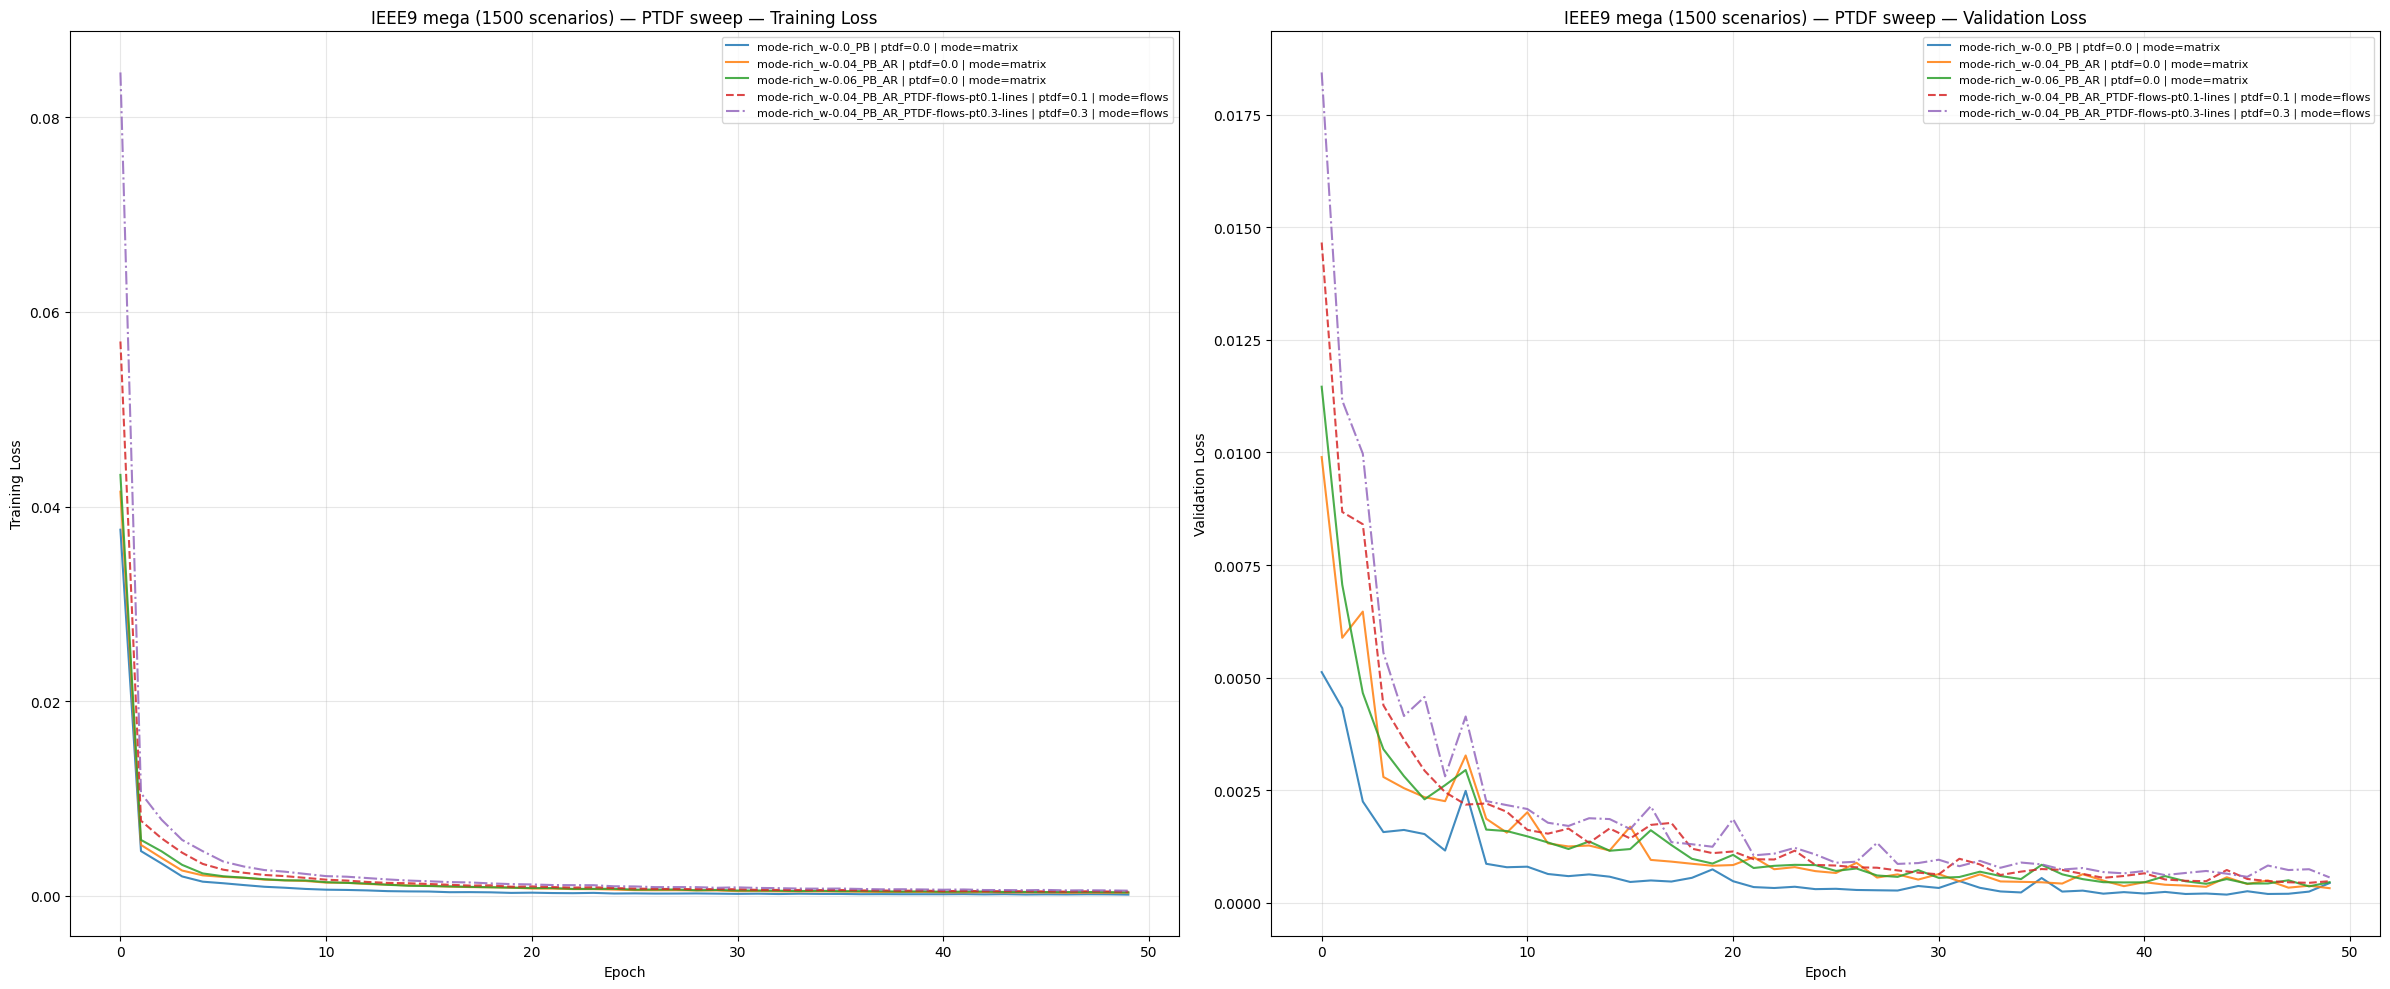

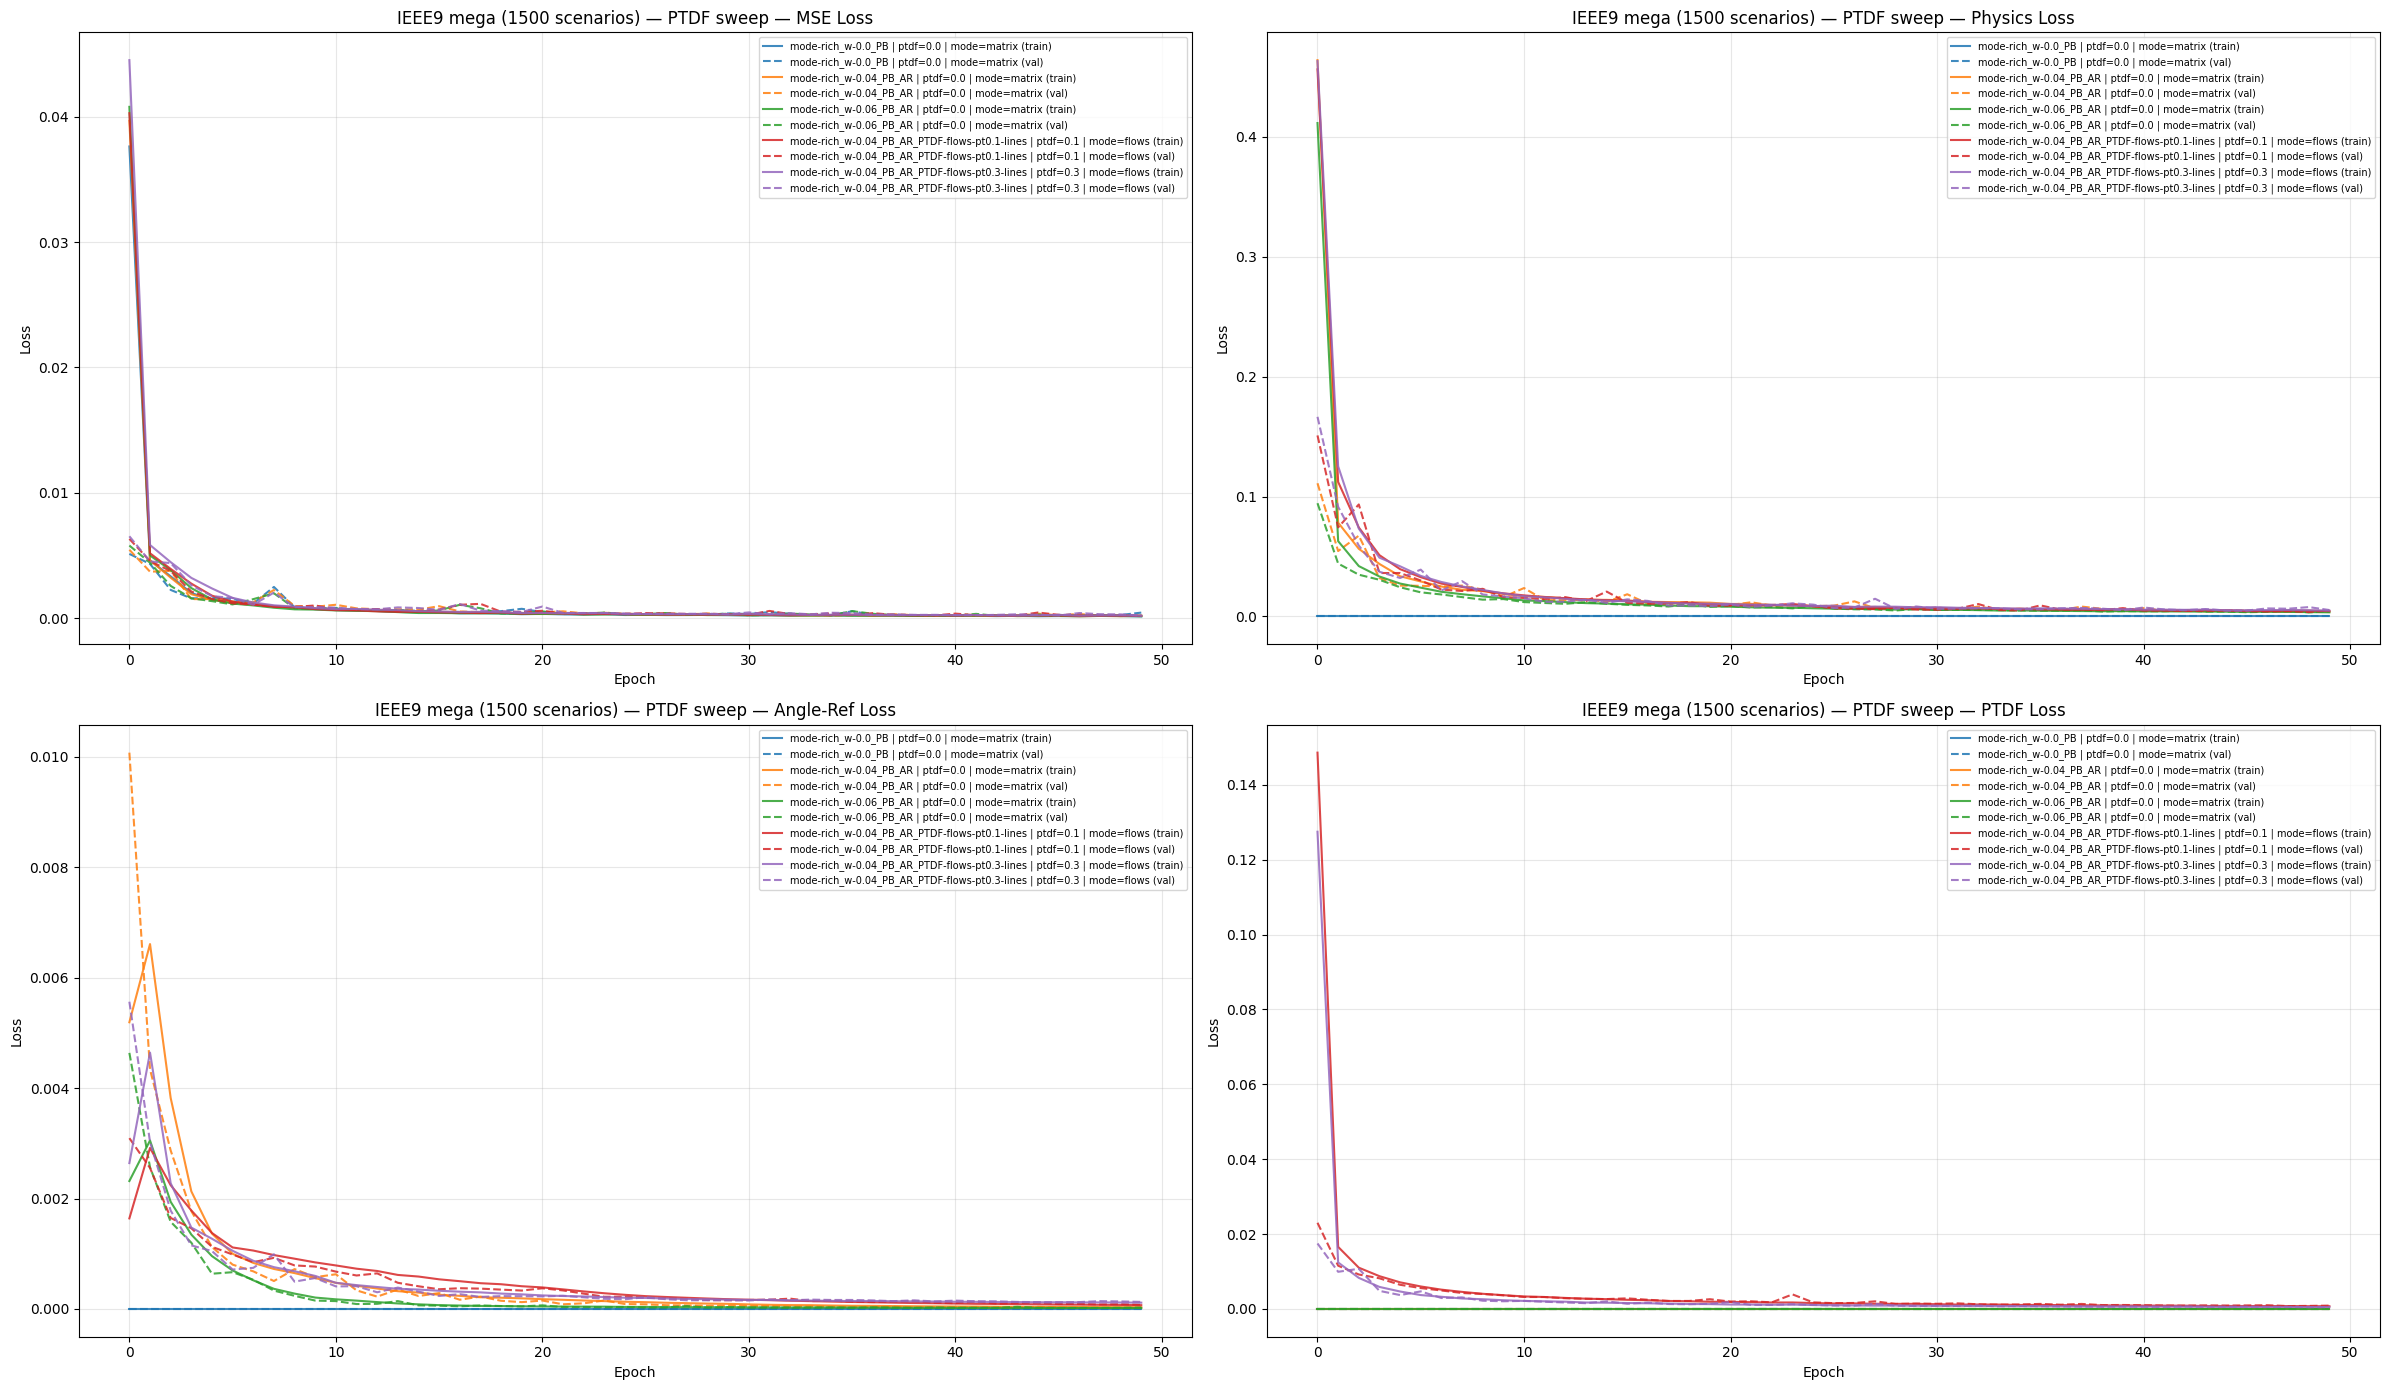

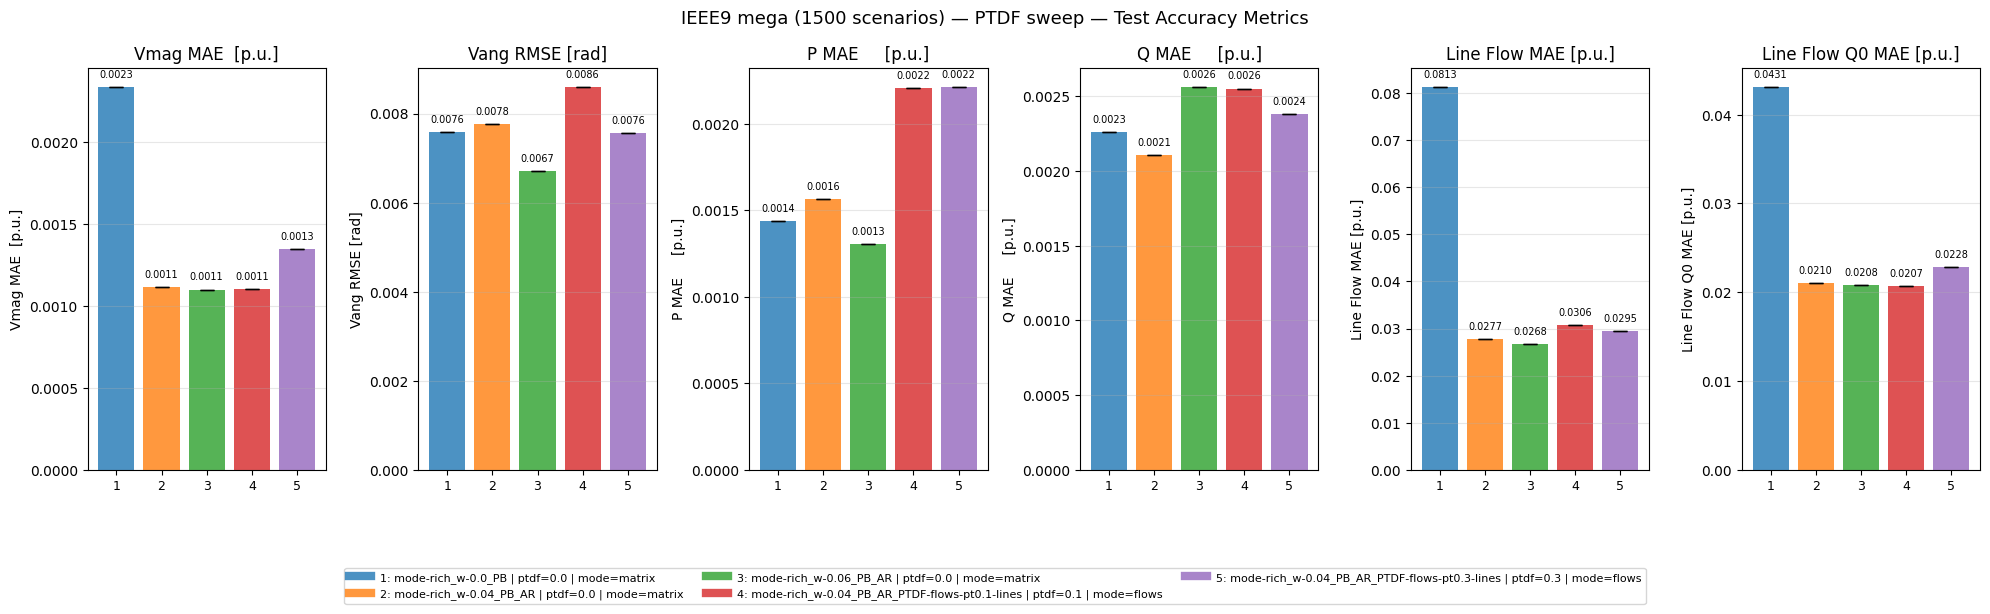

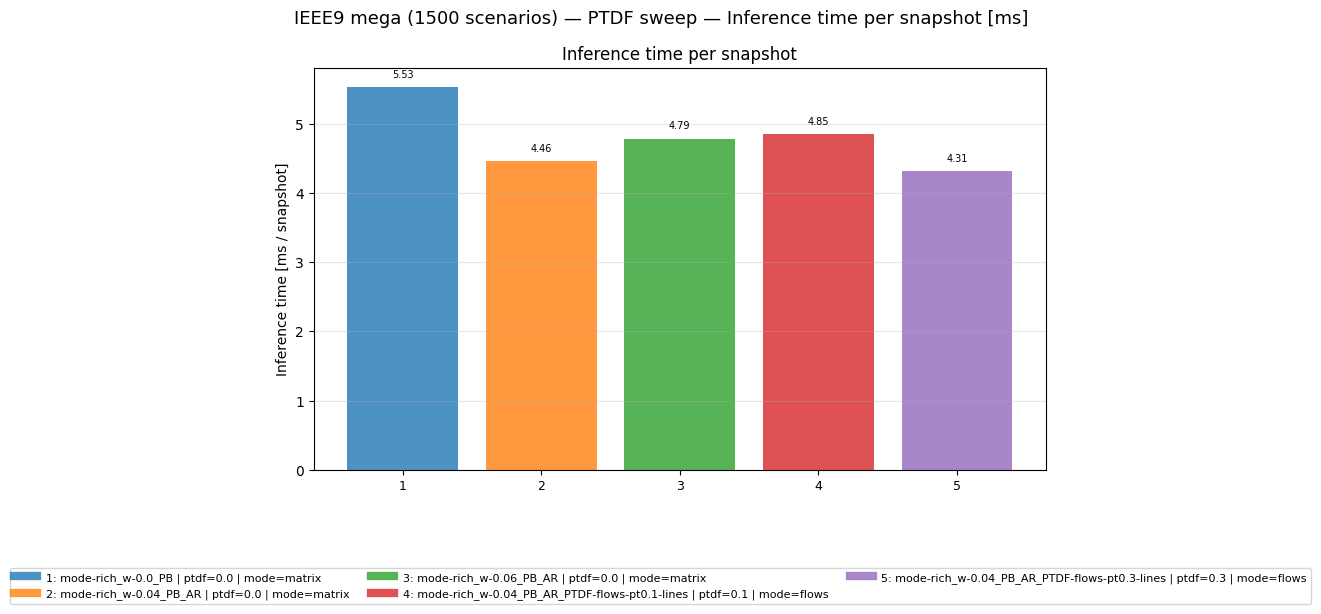

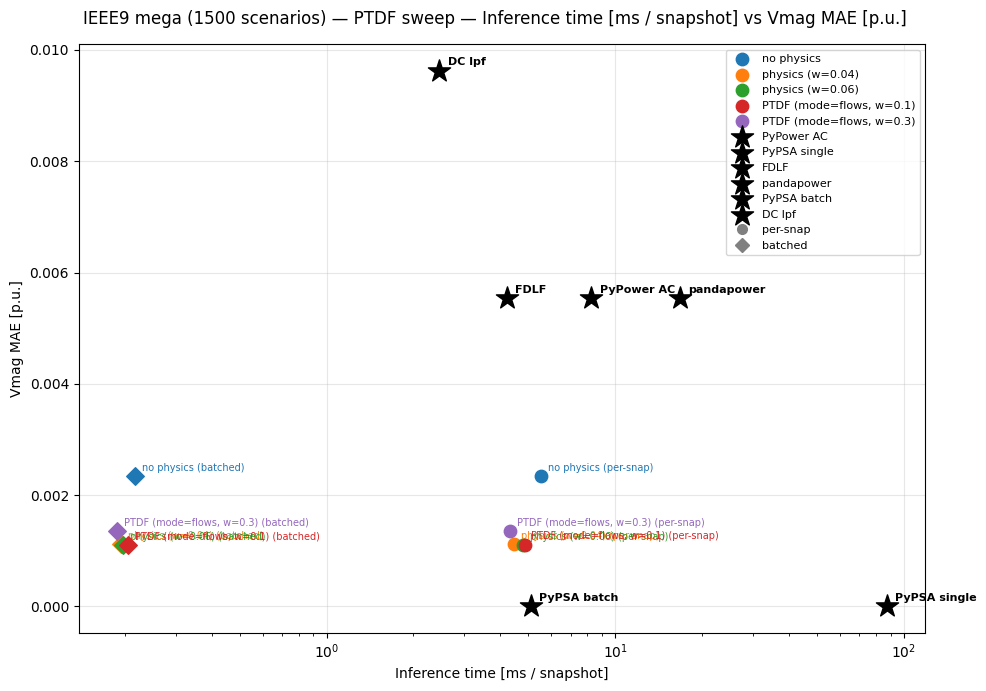

  weight_physics                 [numeric]  : [0.0, 0.04, 0.06] → as-is (linear trend)
  weight_ptdf                    [numeric]  : [0.0, 0.1, 0.3] → as-is (linear trend)

Active interactions:
  weight_physics : weight_ptdf

Runs: 5   Parameters: 4   Error df: 1
Formula RHS: F0 + F1 + F0:F1

Response: vmag_mae   R²=0.8647   Adj-R²=0.7294
                            coefficient   p-value significant
Intercept                      0.002223  0.013928           *
weight_physics                -0.022502  0.072163            
weight_ptdf                   -0.000148  0.902697            
weight_physics:weight_ptdf    -0.000006  0.902697            

Response: vang_rmse   R²=0.1384   Adj-R²=-0.7232
                            coefficient   p-value significant
Intercept                      0.007887  0.011169           *
weight_physics                -0.009607  0.682392            
weight_ptdf                    0.001274  0.744026            
weight_physics:weight_ptdf     0.000051  0.744026  

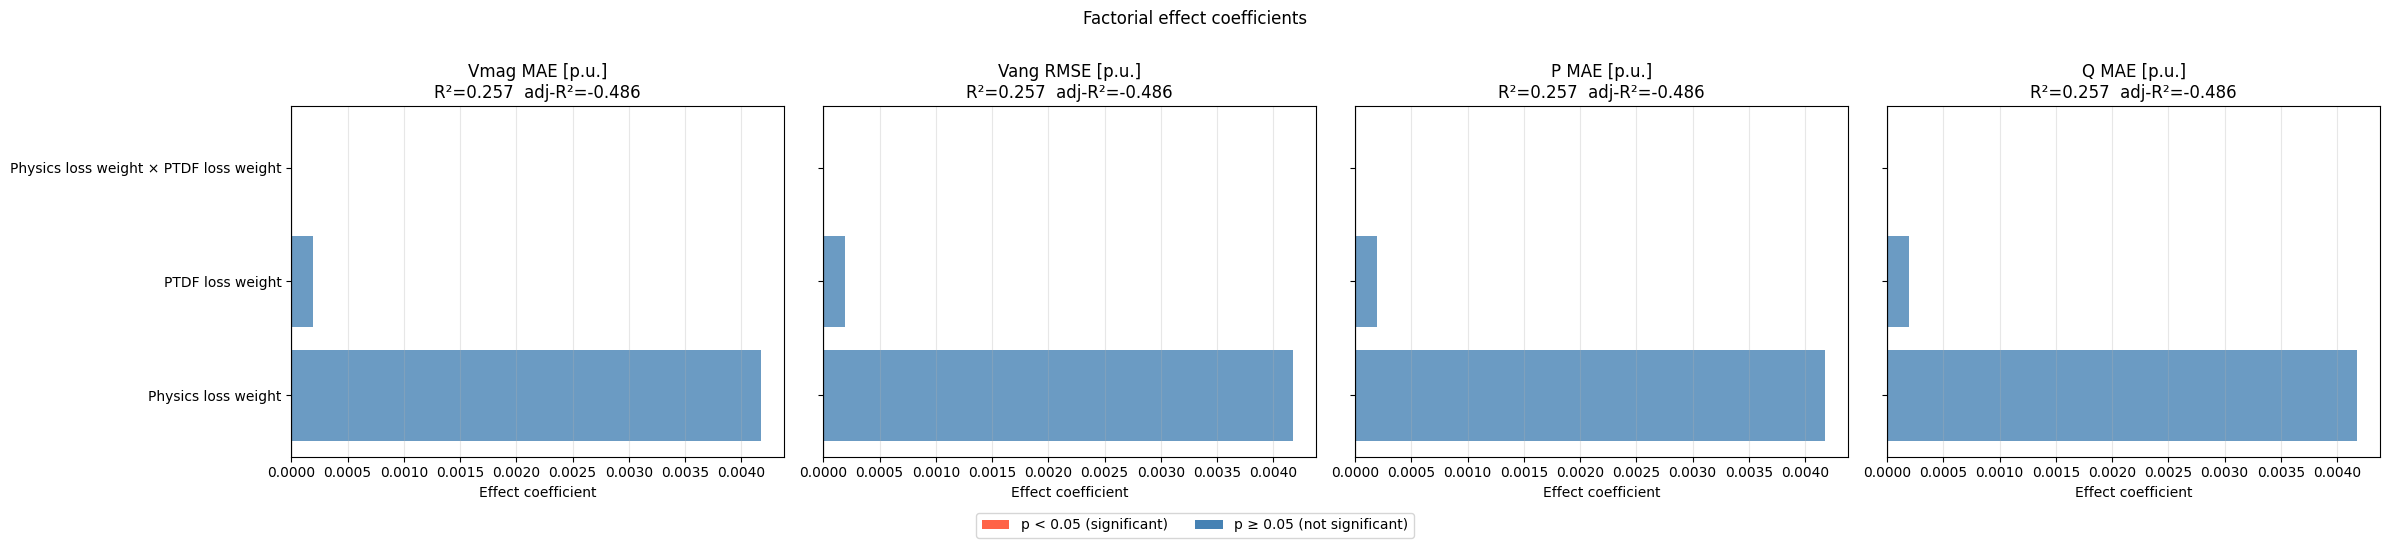

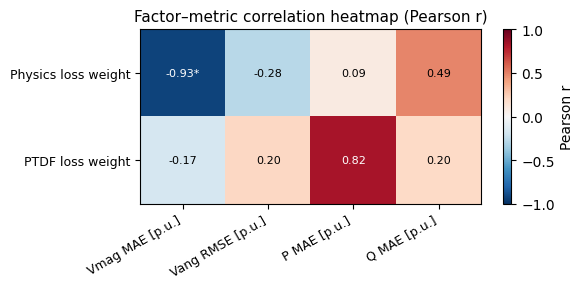

c:\git_repos\Graph-Neural-Networks\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:                  p_mae   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     2.125
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.320
Time:                        12:50:21   Log-Likelihood:                 35.023
No. Observations:                   5   AIC:                            -64.05
Df Residuals:                       2   BIC:                            -65.22
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0015      0.000      4.649      0.0

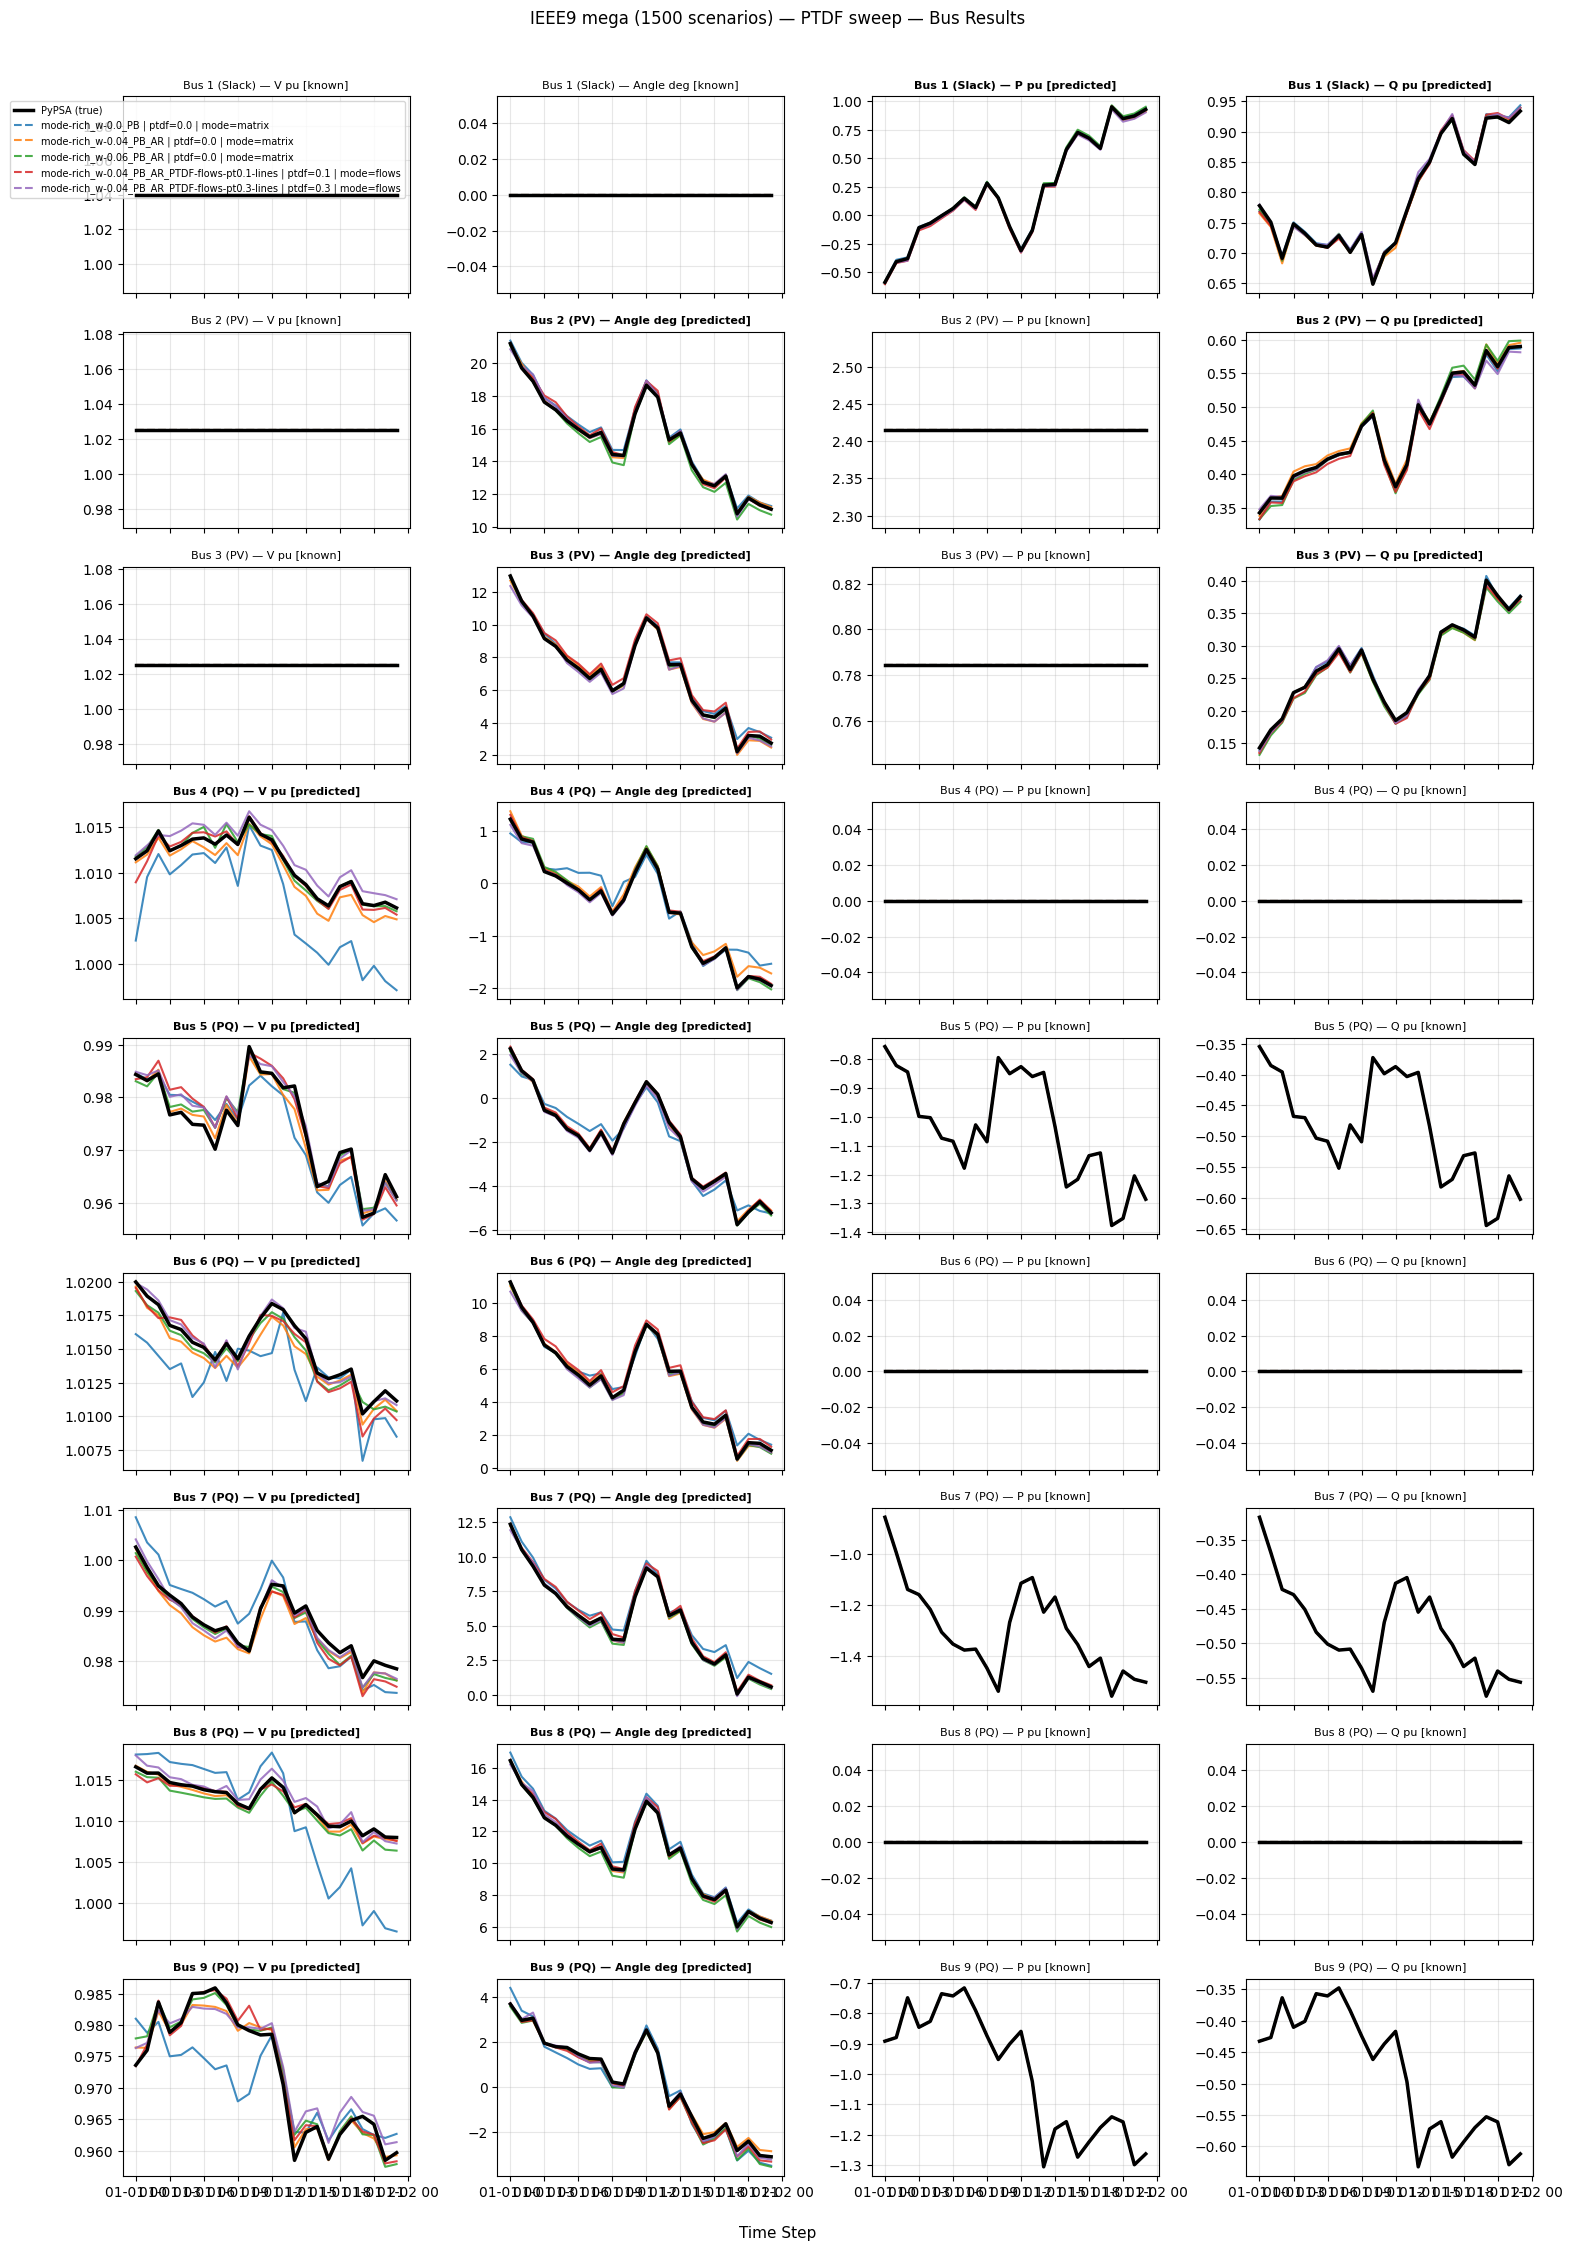

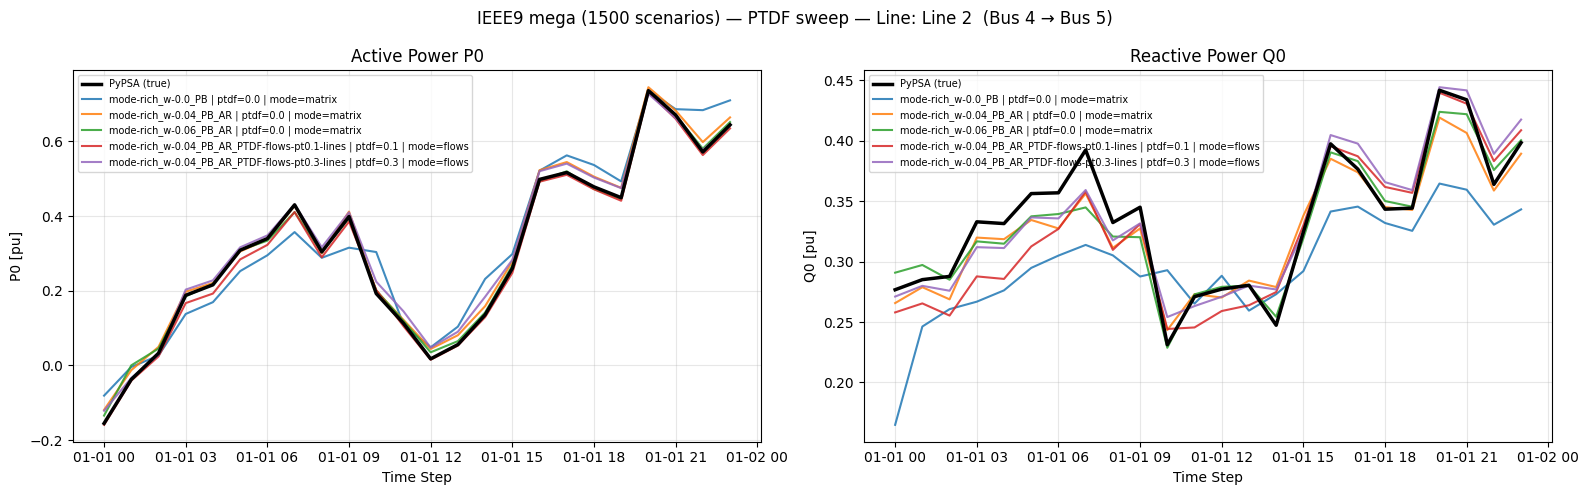

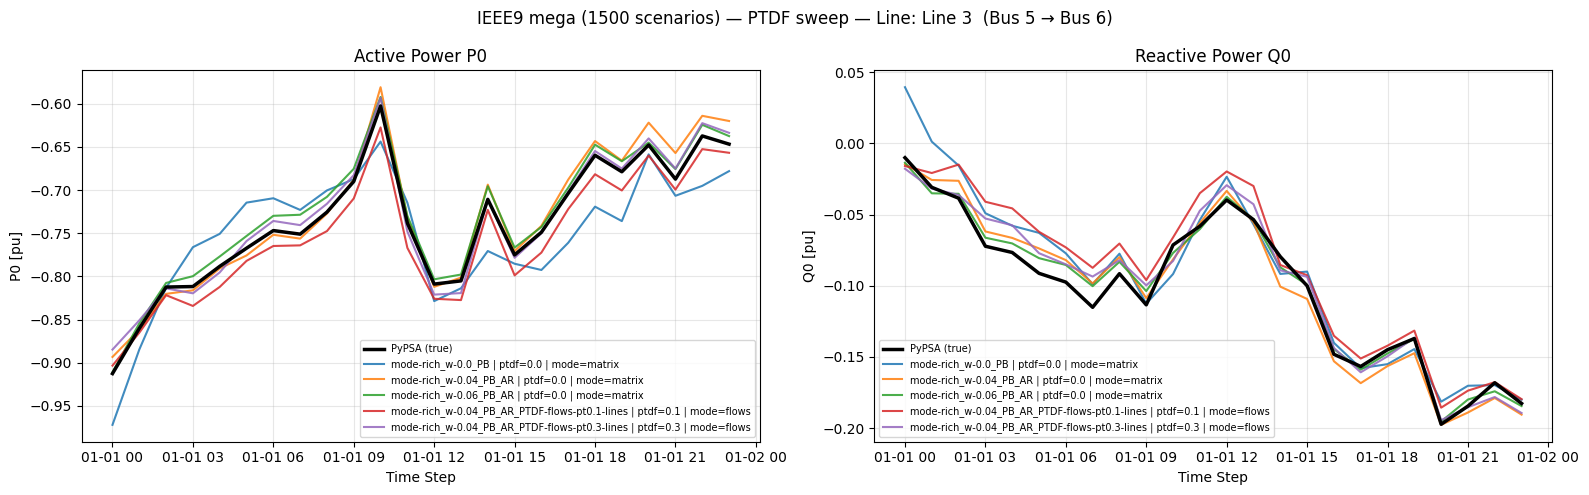

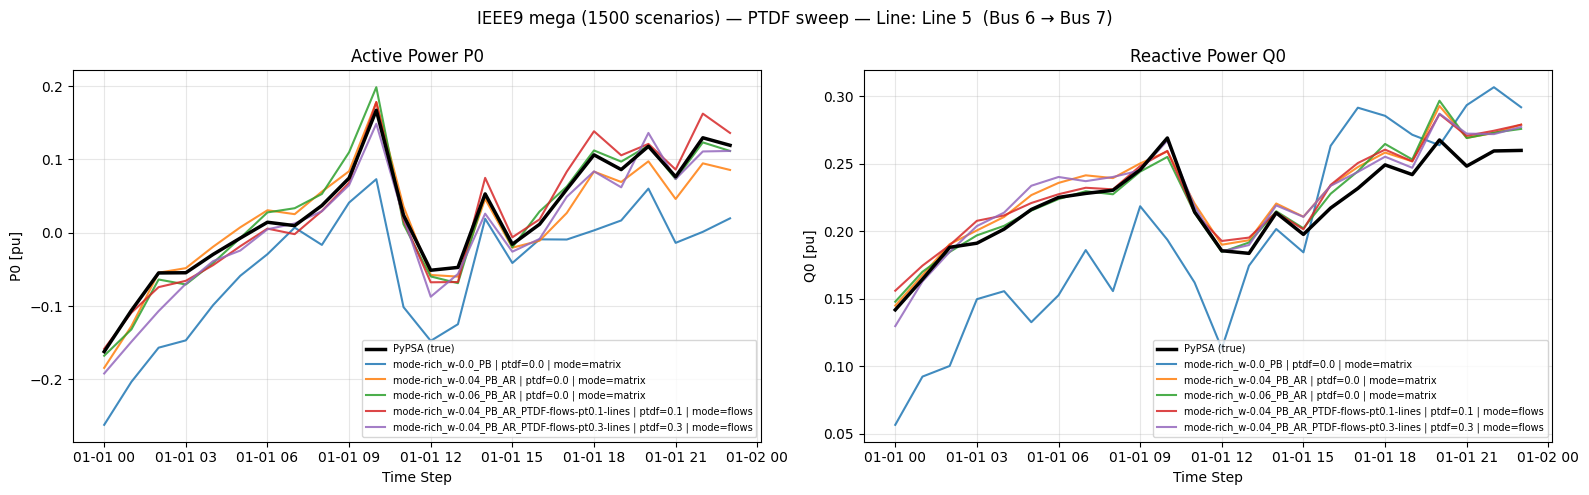

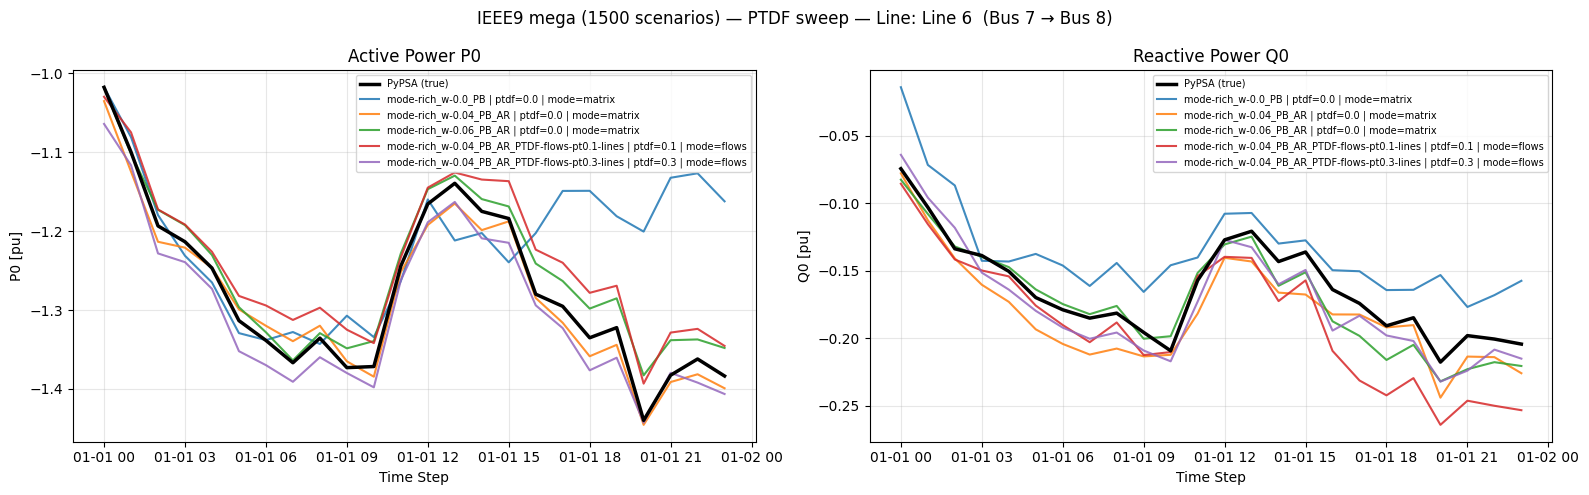

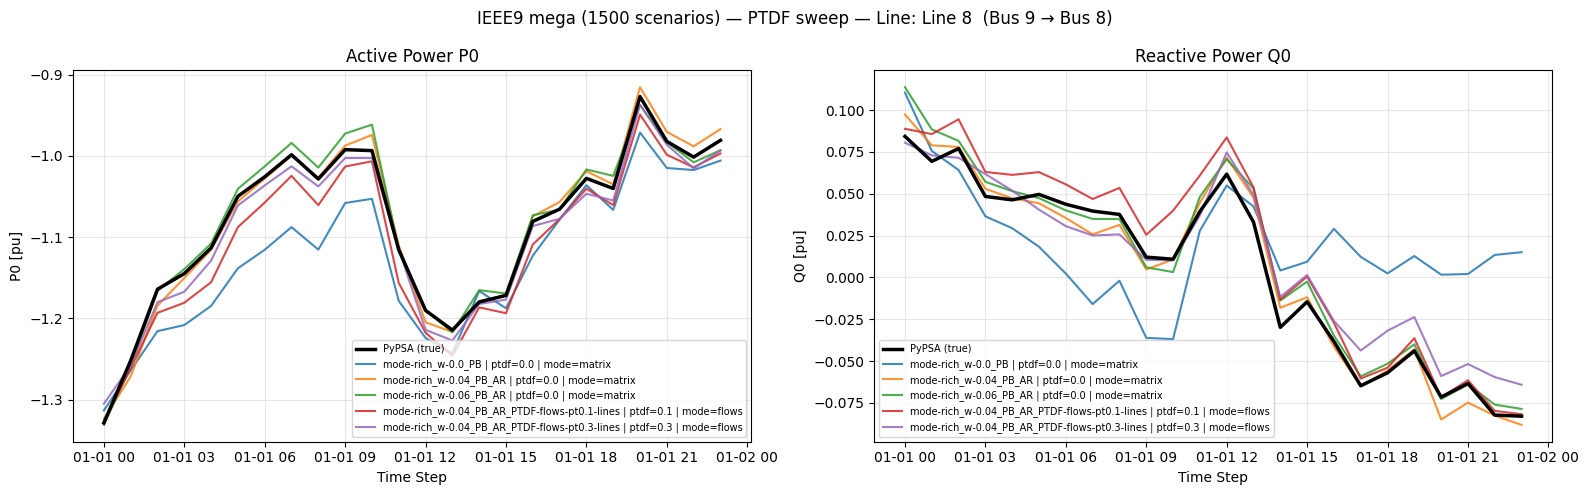

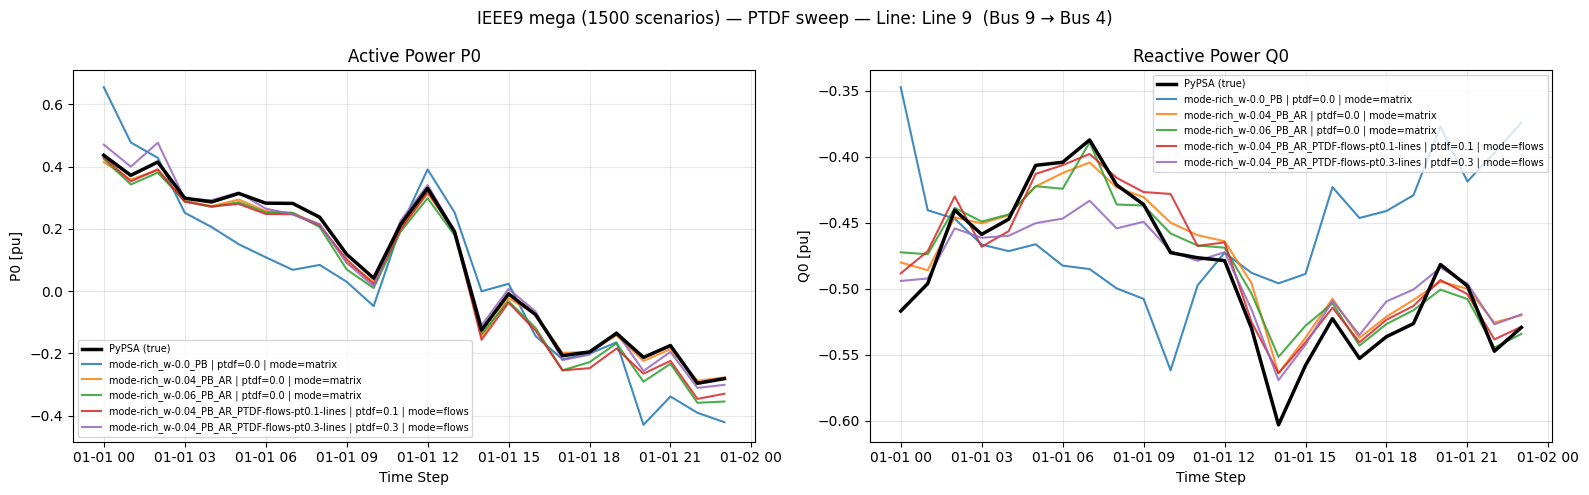

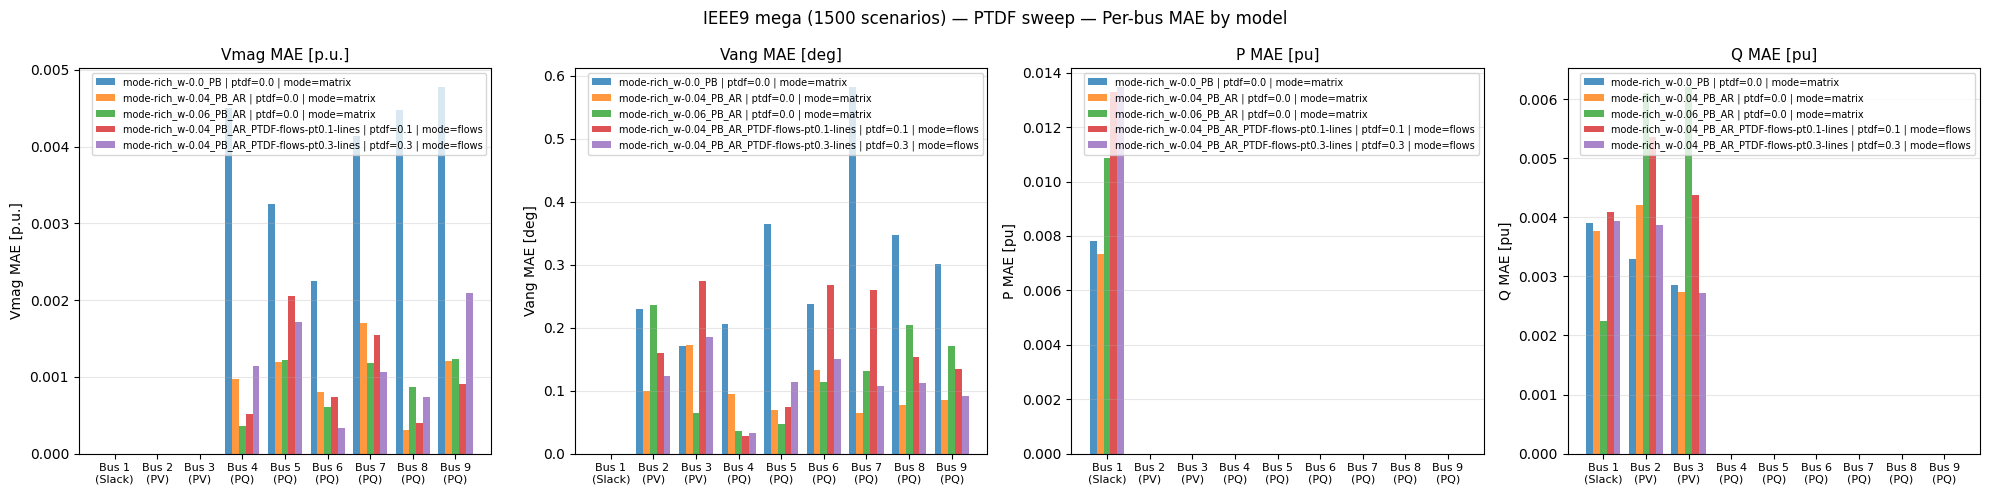

Model dict build


In [ ]:
check_hparam_results(
    runs_ieee9_1500_phys_vs_ptdf,
    training_networks=networks_ieee9_mega_singel_slack,
    title_prefix="IEEE9 mega (1500 scenarios) — PTDF sweep",
    run_factorial_analysis=True,
    test_network=networks_ieee9_mega_singel_slack[36],
    ref_baselines=ref_single,
    ref_baselines_batch=ref_batch,
)